# Proyecto de Minería de Datos

## Integrantes y contexto académico

**Universidad Nacional de Colombia**

**Asignatura:** Minería de Datos

**Docente:** Elizabeth León

**Estudiantes:**

- Angel David Piñeros Sierra
- Gabriel Santiago Delgado Lozano
- Breiner Estiven López Fuentes

## Introducción

En el presente proyecto se desarrolla un análisis estadístico a partir de un conjunto de datos obtenido de una fuente oficial de datos abiertos, el cual contiene información estructurada que permite estudiar diferentes variables de interés y su comportamiento. El propósito principal es aplicar técnicas de exploración, limpieza, análisis y visualización de datos para extraer información relevante y generar conclusiones fundamentadas.


## Fuentes de datos

1. https://www.datos.gov.co/Educaci-n/MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR-B-SICA/nudc-7mev/about_data
2. https://www.datos.gov.co/Educaci-n/MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR-B-SICA/ji8i-4anb/about_data


## Objetivo del análisis

Analizar los indicadores educativos de los municipios de Colombia para identificar factores que influyen en la calidad y permanencia escolar, así como predecir niveles de reprobación o repitencia estudiantil.

**Problemática:** Identificar los factores que inciden en los niveles de reprobación y repitencia escolar en los municipios de Colombia.

**Hallazgos esperados:** Correlaciones entre cobertura y desempeño, diferencias regionales y detección de municipios atípicos con comportamientos educativos inusuales.


## Etapa 1: Análisis descriptivo del dataset

Esta primera etapa reúne la carga, depuración y exploración descriptiva del conjunto de datos, con el fin de entender su estructura, calidad y patrones iniciales.


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats


### Carga y comprensión inicial de los datos

En esta sección se importa el conjunto de datos, se inspecciona su estructura general y se revisan las variables disponibles para el análisis.


In [47]:
url = "https://www.datos.gov.co/resource/nudc-7mev.csv?$limit=500000"
df = pd.read_csv(url)
df.head(60)


,a_o,c_digo_municipio,municipio,c_digo_departamento,departamento,c_digo_etc,etc,poblaci_n_5_16,tasa_matriculaci_n_5_16,cobertura_neta,cobertura_neta_transici_n,cobertura_neta_primaria,cobertura_neta_secundaria,cobertura_neta_media,cobertura_bruta,cobertura_bruta_transici_n,cobertura_bruta_primaria,cobertura_bruta_secundaria,cobertura_bruta_media,tama_o_promedio_de_grupo,sedes_conectadas_a_internet,deserci_n,deserci_n_transici_n,deserci_n_primaria,deserci_n_secundaria,deserci_n_media,aprobaci_n,aprobaci_n_transici_n,aprobaci_n_primaria,aprobaci_n_secundaria,aprobaci_n_media,reprobaci_n,reprobaci_n_transici_n,reprobaci_n_primaria,reprobaci_n_secundaria,reprobaci_n_media,repitencia,repitencia_transici_n,repitencia_primaria,repitencia_secundaria,repitencia_media
0,2024,5004,Abriaquí,5,Antioquia,3758.0,Antioquia (ETC),499,56.11,56.11,39.53,59.13,51.52,26.51,61.92,58.14,67.79,60.61,51.81,NaN,NaN,0.00,0.00,0.00,0.00,0.00,99.68,0.00,100.00,100.00,97.67,0.32,0.00,0.00,0.00,2.33,8.41,0.00,8.51,13.00,2.33
1,2024,15204,Cómbita,15,Boyacá,3769.0,Boyacá (ETC),1862,95.33,95.33,53.64,89.15,98.88,62.10,191.51,63.58,148.84,258.59,225.16,NaN,NaN,3.24,0.00,1.71,4.97,3.68,94.14,0.00,96.58,90.63,95.26,2.62,0.00,1.71,4.40,1.05,7.94,1.69,4.94,14.53,0.00
2,2024,99773,Cumaribo,99,Vichada,3832.0,Vichada (ETC),25239,50.70,50.70,40.14,57.71,16.95,3.85,57.74,61.32,88.33,38.03,17.94,NaN,NaN,5.50,3.79,5.08,7.30,6.15,79.28,0.00,74.54,84.61,88.16,15.22,0.00,20.39,8.09,5.70,20.14,0.63,26.99,11.05,4.34
3,2024,99624,Santa Rosalía,99,Vichada,3832.0,Vichada (ETC),1157,81.42,81.42,70.67,82.64,54.90,22.45,90.58,117.33,108.79,85.29,46.94,NaN,NaN,6.30,4.55,6.15,7.76,3.26,86.07,0.00,86.73,81.32,91.30,7.63,0.00,7.12,10.92,5.43,13.17,0.00,15.00,16.67,2.17
4,2024,99524,La Primavera,99,Vichada,3832.0,Vichada (ETC),2645,90.96,90.96,64.13,96.46,59.01,31.33,99.13,83.15,128.68,89.36,59.01,NaN,NaN,5.16,2.72,5.65,5.42,3.27,86.01,0.00,83.36,85.73,93.82,8.83,0.00,11.00,8.84,2.91,13.15,0.68,17.38,11.67,3.64
5,2024,99001,Puerto Carreño,99,Vichada,3832.0,Vichada (ETC),4600,148.35,148.17,114.02,169.11,81.25,29.10,158.74,140.43,235.60,121.40,61.04,NaN,NaN,8.45,5.06,9.10,8.87,4.13,81.47,0.00,80.04,78.20,94.04,10.08,0.00,10.86,12.92,1.83,12.72,1.90,13.86,14.92,4.36
6,2024,97889,Yavaraté,97,Vaupés,3831.0,Vaupés (ETC),562,46.26,46.26,48.48,51.56,24.29,15.96,50.89,90.91,69.78,35.71,25.53,NaN,NaN,8.39,0.00,1.91,25.33,8.33,82.87,0.00,82.80,73.33,91.67,8.74,0.00,15.29,1.33,0.00,7.69,0.00,8.92,8.00,8.33
7,2024,97777,Papunaua,97,Vaupés,3831.0,Vaupés (ETC),208,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
8,2024,97666,Taraira,97,Vaupés,3831.0,Vaupés (ETC),802,19.95,19.95,14.29,29.83,0.00,0.00,20.82,30.16,50.17,0.00,0.00,NaN,NaN,0.00,0.00,0.00,0.00,0.00,100.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,34.73,0.00,39.19,0.00,0.00
9,2024,97511,Pacoa,97,Vaupés,3831.0,Vaupés (ETC),1666,54.80,54.80,14.29,54.88,25.09,5.25,72.87,38.10,98.78,69.53,40.00,NaN,NaN,7.83,0.00,4.32,10.31,22.13,89.95,0.00,92.75,88.92,73.77,2.22,0.00,2.93,0.77,4.10,18.29,23.21,25.77,10.31,1.64


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15707 entries, 0 to 15706
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   a_o                          15707 non-null  int64  
 1   c_digo_municipio             15707 non-null  int64  
 2   municipio                    15707 non-null  object 
 3   c_digo_departamento          15707 non-null  int64  
 4   departamento                 15707 non-null  object 
 5   c_digo_etc                   15707 non-null  float64
 6   etc                          15707 non-null  object 
 7   poblaci_n_5_16               15701 non-null  object 
 8   tasa_matriculaci_n_5_16      15592 non-null  float64
 9   cobertura_neta               15596 non-null  float64
 10  cobertura_neta_transici_n    15655 non-null  float64
 11  cobertura_neta_primaria      15616 non-null  float64
 12  cobertura_neta_secundaria    15613 non-null  float64
 13  cobertura_neta_m

### Limpieza y preparación de datos

En este bloque se normalizan nombres de columnas, se revisan valores nulos y se aplican transformaciones necesarias para mejorar la calidad del dataset antes del análisis estadístico.


In [49]:
# Renombrar columnas a snake_case con anio en lugar de ano
column_map = {
    "a_o": "anio",
    "c_digo_municipio": "codigo_municipio",
    "municipio": "municipio",
    "c_digo_departamento": "codigo_departamento",
    "departamento": "departamento",
    "c_digo_etc": "codigo_etc",
    "etc": "etc",
    "poblaci_n_5_16": "poblacion_5_16",
    "tasa_matriculaci_n_5_16": "tasa_matriculacion_5_16",
    "cobertura_neta": "cobertura_neta",
    "cobertura_neta_transici_n": "cobertura_neta_transicion",
    "cobertura_neta_primaria": "cobertura_neta_primaria",
    "cobertura_neta_secundaria": "cobertura_neta_secundaria",
    "cobertura_neta_media": "cobertura_neta_media",
    "cobertura_bruta": "cobertura_bruta",
    "cobertura_bruta_transici_n": "cobertura_bruta_transicion",
    "cobertura_bruta_primaria": "cobertura_bruta_primaria",
    "cobertura_bruta_secundaria": "cobertura_bruta_secundaria",
    "cobertura_bruta_media": "cobertura_bruta_media",
    "tama_o_promedio_de_grupo": "tamano_promedio_de_grupo",
    "sedes_conectadas_a_internet": "sedes_conectadas_a_internet",
    "deserci_n": "desercion",
    "deserci_n_transici_n": "desercion_transicion",
    "deserci_n_primaria": "desercion_primaria",
    "deserci_n_secundaria": "desercion_secundaria",
    "deserci_n_media": "desercion_media",
    "aprobaci_n": "aprobacion",
    "aprobaci_n_transici_n": "aprobacion_transicion",
    "aprobaci_n_primaria": "aprobacion_primaria",
    "aprobaci_n_secundaria": "aprobacion_secundaria",
    "aprobaci_n_media": "aprobacion_media",
    "reprobaci_n": "reprobacion",
    "reprobaci_n_transici_n": "reprobacion_transicion",
    "reprobaci_n_primaria": "reprobacion_primaria",
    "reprobaci_n_secundaria": "reprobacion_secundaria",
    "reprobaci_n_media": "reprobacion_media",
    "repitencia": "repitencia",
    "repitencia_transici_n": "repitencia_transicion",
    "repitencia_primaria": "repitencia_primaria",
    "repitencia_secundaria": "repitencia_secundaria",
    "repitencia_media": "repitencia_media",
}

df = df.copy()
missing = [c for c in column_map if c not in df.columns]
if missing:
    raise ValueError(f"Columnas no encontradas: {missing}")

df = df.rename(columns=column_map)
df.columns

Index(['anio', 'codigo_municipio', 'municipio', 'codigo_departamento', 'departamento', 'codigo_etc', 'etc', 'poblacion_5_16', 'tasa_matriculacion_5_16', 'cobertura_neta', 'cobertura_neta_transicion',
       'cobertura_neta_primaria', 'cobertura_neta_secundaria', 'cobertura_neta_media', 'cobertura_bruta', 'cobertura_bruta_transicion', 'cobertura_bruta_primaria', 'cobertura_bruta_secundaria',
       'cobertura_bruta_media', 'tamano_promedio_de_grupo', 'sedes_conectadas_a_internet', 'desercion', 'desercion_transicion', 'desercion_primaria', 'desercion_secundaria', 'desercion_media',
       'aprobacion', 'aprobacion_transicion', 'aprobacion_primaria', 'aprobacion_secundaria', 'aprobacion_media', 'reprobacion', 'reprobacion_transicion', 'reprobacion_primaria',
       'reprobacion_secundaria', 'reprobacion_media', 'repitencia', 'repitencia_transicion', 'repitencia_primaria', 'repitencia_secundaria', 'repitencia_media'],
      dtype='object')

In [50]:
# Resumen de nulos por columna
null_counts = df.isna().sum().sort_values(ascending=False)
null_percent = (df.isna().mean() * 100).round(2)
null_summary = (
    null_counts.to_frame(name="null_count")
    .join(null_percent.to_frame(name="null_percent"))
)
null_summary


,null_count,null_percent
tamano_promedio_de_grupo,8135,51.79
sedes_conectadas_a_internet,7939,50.54
desercion_transicion,903,5.75
desercion_media,734,4.67
desercion_secundaria,270,1.72
desercion_primaria,242,1.54
repitencia_transicion,159,1.01
repitencia_secundaria,152,0.97
repitencia_primaria,148,0.94
reprobacion_media,145,0.92


In [51]:
# Limpieza inicial: eliminar >50% nulos, corregir miles, convertir porcentajes
cols_drop = ["tamano_promedio_de_grupo", "sedes_conectadas_a_internet"]
df = df.drop(columns=cols_drop)

# Excluir registros agregados nacionales para mantener el análisis a nivel municipal.
df = df[
    (df["municipio"].astype(str).str.upper() != "NACIONAL")
    & (df["departamento"].astype(str).str.upper() != "NACIONAL")
].copy()

df["poblacion_5_16"] = (
    df["poblacion_5_16"]
    .astype(str)
    .str.replace(".", "", regex=False)
)
df["poblacion_5_16"] = pd.to_numeric(df["poblacion_5_16"], errors="coerce").astype("Int64")

percent_columns = [
    "tasa_matriculacion_5_16",
    "cobertura_neta",
    "cobertura_neta_transicion",
    "cobertura_neta_primaria",
    "cobertura_neta_secundaria",
    "cobertura_neta_media",
    "cobertura_bruta",
    "cobertura_bruta_transicion",
    "cobertura_bruta_primaria",
    "cobertura_bruta_secundaria",
    "cobertura_bruta_media",
    "desercion",
    "desercion_transicion",
    "desercion_primaria",
    "desercion_secundaria",
    "desercion_media",
    "aprobacion",
    "aprobacion_transicion",
    "aprobacion_primaria",
    "aprobacion_secundaria",
    "aprobacion_media",
    "reprobacion",
    "reprobacion_transicion",
    "reprobacion_primaria",
    "reprobacion_secundaria",
    "reprobacion_media",
    "repitencia",
    "repitencia_transicion",
    "repitencia_primaria",
    "repitencia_secundaria",
    "repitencia_media",
]

for col in percent_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("%", "", regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce") / 100

df.dtypes


,0
anio,int64
codigo_municipio,int64
municipio,object
codigo_departamento,int64
departamento,object
codigo_etc,float64
etc,object
poblacion_5_16,Int64
tasa_matriculacion_5_16,float64
cobertura_neta,float64


In [52]:
# Mostrar todas las columnas en la salida
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
df.head(10)
# df.sample(10, random_state=42)


,anio,codigo_municipio,municipio,codigo_departamento,departamento,codigo_etc,etc,poblacion_5_16,tasa_matriculacion_5_16,cobertura_neta,cobertura_neta_transicion,cobertura_neta_primaria,cobertura_neta_secundaria,cobertura_neta_media,cobertura_bruta,cobertura_bruta_transicion,cobertura_bruta_primaria,cobertura_bruta_secundaria,cobertura_bruta_media,desercion,desercion_transicion,desercion_primaria,desercion_secundaria,desercion_media,aprobacion,aprobacion_transicion,aprobacion_primaria,aprobacion_secundaria,aprobacion_media,reprobacion,reprobacion_transicion,reprobacion_primaria,reprobacion_secundaria,reprobacion_media,repitencia,repitencia_transicion,repitencia_primaria,repitencia_secundaria,repitencia_media
0,2024,5004,Abriaquí,5,Antioquia,3758.0,Antioquia (ETC),499,0.5611,0.5611,0.3953,0.5913,0.5152,0.2651,0.6192,0.5814,0.6779,0.6061,0.5181,0.0000,0.0000,0.0000,0.0000,0.0000,0.9968,0.0,1.0000,1.0000,0.9767,0.0032,0.0,0.0000,0.0000,0.0233,0.0841,0.0000,0.0851,0.1300,0.0233
1,2024,15204,Cómbita,15,Boyacá,3769.0,Boyacá (ETC),1862,0.9533,0.9533,0.5364,0.8915,0.9888,0.6210,1.9151,0.6358,1.4884,2.5859,2.2516,0.0324,0.0000,0.0171,0.0497,0.0368,0.9414,0.0,0.9658,0.9063,0.9526,0.0262,0.0,0.0171,0.0440,0.0105,0.0794,0.0169,0.0494,0.1453,0.0000
2,2024,99773,Cumaribo,99,Vichada,3832.0,Vichada (ETC),25239,0.5070,0.5070,0.4014,0.5771,0.1695,0.0385,0.5774,0.6132,0.8833,0.3803,0.1794,0.0550,0.0379,0.0508,0.0730,0.0615,0.7928,0.0,0.7454,0.8461,0.8816,0.1522,0.0,0.2039,0.0809,0.0570,0.2014,0.0063,0.2699,0.1105,0.0434
3,2024,99624,Santa Rosalía,99,Vichada,3832.0,Vichada (ETC),1157,0.8142,0.8142,0.7067,0.8264,0.5490,0.2245,0.9058,1.1733,1.0879,0.8529,0.4694,0.0630,0.0455,0.0615,0.0776,0.0326,0.8607,0.0,0.8673,0.8132,0.9130,0.0763,0.0,0.0712,0.1092,0.0543,0.1317,0.0000,0.1500,0.1667,0.0217
4,2024,99524,La Primavera,99,Vichada,3832.0,Vichada (ETC),2645,0.9096,0.9096,0.6413,0.9646,0.5901,0.3133,0.9913,0.8315,1.2868,0.8936,0.5901,0.0516,0.0272,0.0565,0.0542,0.0327,0.8601,0.0,0.8336,0.8573,0.9382,0.0883,0.0,0.1100,0.0884,0.0291,0.1315,0.0068,0.1738,0.1167,0.0364
5,2024,99001,Puerto Carreño,99,Vichada,3832.0,Vichada (ETC),4600,1.4835,1.4817,1.1402,1.6911,0.8125,0.2910,1.5874,1.4043,2.3560,1.2140,0.6104,0.0845,0.0506,0.0910,0.0887,0.0413,0.8147,0.0,0.8004,0.7820,0.9404,0.1008,0.0,0.1086,0.1292,0.0183,0.1272,0.0190,0.1386,0.1492,0.0436
6,2024,97889,Yavaraté,97,Vaupés,3831.0,Vaupés (ETC),562,0.4626,0.4626,0.4848,0.5156,0.2429,0.1596,0.5089,0.9091,0.6978,0.3571,0.2553,0.0839,0.0000,0.0191,0.2533,0.0833,0.8287,0.0,0.8280,0.7333,0.9167,0.0874,0.0,0.1529,0.0133,0.0000,0.0769,0.0000,0.0892,0.0800,0.0833
7,2024,97777,Papunaua,97,Vaupés,3831.0,Vaupés (ETC),208,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
8,2024,97666,Taraira,97,Vaupés,3831.0,Vaupés (ETC),802,0.1995,0.1995,0.1429,0.2983,0.0000,0.0000,0.2082,0.3016,0.5017,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0,1.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.3473,0.0000,0.3919,0.0000,0.0000
9,2024,97511,Pacoa,97,Vaupés,3831.0,Vaupés (ETC),1666,0.5480,0.5480,0.1429,0.5488,0.2509,0.0525,0.7287,0.3810,0.9878,0.6953,0.4000,0.0783,0.0000,0.0432,0.1031,0.2213,0.8995,0.0,0.9275,0.8892,0.7377,0.0222,0.0,0.0293,0.0077,0.0410,0.1829,0.2321,0.2577,0.1031,0.0164


In [53]:
# Nulos despues de la limpieza
null_counts_after = df.isna().sum().sort_values(ascending=False)
null_percent_after = (df.isna().mean() * 100).round(2)
dtype_after = df.dtypes.astype(str).to_frame(name="dtype")
null_summary_after = (
    null_counts_after.to_frame(name="null_count")
    .join(null_percent_after.to_frame(name="null_percent"))
    .join(dtype_after)
)
null_summary_after


,null_count,null_percent,dtype
desercion_transicion,903,5.75,float64
desercion_media,734,4.67,float64
desercion_secundaria,270,1.72,float64
desercion_primaria,242,1.54,float64
repitencia_transicion,159,1.01,float64
repitencia_secundaria,152,0.97,float64
repitencia_primaria,148,0.94,float64
reprobacion_media,145,0.92,float64
repitencia,143,0.91,float64
desercion,142,0.90,float64


In [54]:
# Tabla de promedios (porcentajes) y mediana (poblacion) para imputar
group_cols = ["departamento", "anio"]
percent_impute = [c for c in percent_columns if df[c].isna().any()]
pop_col = "poblacion_5_16"

mean_table = df.groupby(group_cols)[percent_impute].mean()
median_table = df.groupby(group_cols)[[pop_col]].median()
impute_table = mean_table.join(median_table).reset_index()
impute_table.head(20)


,departamento,anio,tasa_matriculacion_5_16,cobertura_neta,cobertura_neta_transicion,cobertura_neta_primaria,cobertura_neta_secundaria,cobertura_neta_media,cobertura_bruta,cobertura_bruta_transicion,cobertura_bruta_primaria,cobertura_bruta_secundaria,cobertura_bruta_media,desercion,desercion_transicion,desercion_primaria,desercion_secundaria,desercion_media,aprobacion,aprobacion_transicion,aprobacion_primaria,aprobacion_secundaria,aprobacion_media,reprobacion,reprobacion_transicion,reprobacion_primaria,reprobacion_secundaria,reprobacion_media,repitencia,repitencia_transicion,repitencia_primaria,repitencia_secundaria,repitencia_media,poblacion_5_16
0,Amazonas,2011,0.565760,0.635500,0.401400,0.587900,0.371714,0.112000,0.631000,0.766500,0.849900,0.594750,0.373714,0.054133,0.058200,0.045562,0.095920,0.088567,0.938390,0.004970,0.951520,0.885363,0.828457,0.012900,0.004970,0.012060,0.012180,0.037490,0.018833,0.010300,0.023811,0.009989,0.025175,1135.0
1,Amazonas,2012,0.584222,0.584556,0.428400,0.572500,0.390857,0.115857,0.626000,0.819500,0.817000,0.619750,0.373429,0.023533,0.043300,0.018586,0.059557,0.059450,0.975890,0.000000,0.982940,0.945437,0.944443,0.002920,0.000000,0.004070,0.001960,0.003210,0.019910,0.003930,0.015267,0.019330,0.007930,1146.0
2,Amazonas,2013,0.628888,0.628750,0.357700,0.574600,0.381625,0.109375,0.633800,0.780400,0.808300,0.582889,0.367375,0.022329,0.056500,0.009643,0.051750,0.038200,0.982980,0.000000,0.991510,0.976111,0.959125,0.001390,0.000000,0.001740,0.000790,0.002900,0.030089,0.008738,0.035733,0.023390,0.014670,1157.0
3,Amazonas,2014,0.588433,0.873140,0.404770,0.694130,0.619756,0.264887,0.681044,0.635489,0.838010,0.558933,0.389562,0.014100,0.035167,0.008329,0.027243,0.046567,0.990080,0.000000,0.994120,0.978733,0.982537,0.000050,0.000000,0.000040,0.000070,0.000000,0.035925,0.005967,0.034883,0.030150,0.004720,1165.0
4,Amazonas,2015,0.617112,0.617025,0.255080,0.661425,0.385325,0.129287,0.669989,0.582850,0.820020,0.583889,0.406500,0.032400,0.056200,0.019875,0.073043,0.074140,0.944970,0.000420,0.960370,0.895378,0.939150,0.025850,0.000420,0.023730,0.020611,0.011610,0.021756,0.009544,0.020267,0.019322,0.008878,1176.0
5,Amazonas,2016,0.523500,0.523500,0.285140,0.544270,0.341100,0.131625,0.607880,0.582260,0.774020,0.592833,0.402000,0.022940,0.018950,0.015220,0.031690,0.027060,0.951020,0.005800,0.962390,0.917400,0.929400,0.026030,0.005800,0.022400,0.047389,0.036788,0.073170,0.030620,0.086220,0.062880,0.037910,1187.0
6,Amazonas,2017,0.530600,0.530690,0.306770,0.551980,0.324660,0.156325,0.624080,0.675260,0.767250,0.546880,0.450650,0.032030,0.032980,0.020020,0.048000,0.038500,0.946840,0.006000,0.955390,0.929460,0.938538,0.021130,0.006000,0.024580,0.022530,0.013325,0.069980,0.034360,0.090470,0.038460,0.011770,1199.0
7,Amazonas,2018,0.468091,0.571100,0.291718,0.597809,0.345255,0.119073,0.661491,0.618509,0.827645,0.575536,0.345400,0.021640,0.015120,0.012280,0.037830,0.049462,0.961880,0.002220,0.973890,0.935190,0.892413,0.016490,0.002220,0.013830,0.026990,0.058125,0.068200,0.042110,0.072630,0.072300,0.022070,687.0
8,Amazonas,2019,0.640580,0.582336,0.361618,0.596727,0.356964,0.110482,0.679100,0.787491,0.811582,0.622864,0.318945,0.016720,0.017350,0.007300,0.026940,0.044900,0.958460,0.001020,0.972600,0.932260,0.913525,0.024820,0.001020,0.020110,0.040800,0.041575,0.083390,0.053630,0.088120,0.077310,0.069720,678.0
9,Amazonas,2020,0.607027,0.607000,0.372218,0.637527,0.369482,0.105927,0.708273,0.797755,0.847891,0.651518,0.344473,0.016582,0.017455,0.007045,0.031990,0.034138,0.957236,0.000082,0.977573,0.918290,0.891775,0.026182,0.000082,0.015391,0.049720,0.074075,0.076855,0.032718,0.097818,0.066291,0.024573,674.0


In [55]:
# Imputacion con promedio por departamento+anio, y fallback por anio
mean_depto_anio = df.groupby(group_cols)[percent_impute].transform("mean")
mean_anio = df.groupby("anio")[percent_impute].transform("mean")

df[percent_impute] = (
    df[percent_impute]
    .fillna(mean_depto_anio)
    .fillna(mean_anio)
)

median_pop_depto_anio = df.groupby(group_cols)[pop_col].transform("median")
median_pop_anio = df.groupby("anio")[pop_col].transform("median")
df[pop_col] = (
    df[pop_col]
    .fillna(median_pop_depto_anio)
    .fillna(median_pop_anio)
    .astype("Int64")
)

df[percent_impute + [pop_col]].isna().sum().sort_values(ascending=False)


,0
tasa_matriculacion_5_16,0
cobertura_neta,0
cobertura_neta_transicion,0
cobertura_neta_primaria,0
cobertura_neta_secundaria,0
cobertura_neta_media,0
cobertura_bruta,0
cobertura_bruta_transicion,0
cobertura_bruta_primaria,0
cobertura_bruta_secundaria,0


### Estadística descriptiva básica

La estadística descriptiva se realiza inicialmente sobre las variables cuantitativas para resumir su comportamiento general y detectar patrones relevantes.


In [56]:
columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
columnas_excluidas = ["anio", "codigo_municipio", "codigo_departamento", "codigo_etc"]
columnas_analisis = [
    col for col in columnas_numericas if col not in columnas_excluidas
]

columnas_excluidas_duplicadas = []
if {"aprobacion_transicion", "reprobacion_transicion"}.issubset(df.columns):
    mismas_transicion = (
        df["aprobacion_transicion"].fillna(-999)
        == df["reprobacion_transicion"].fillna(-999)
    ).all()
    if mismas_transicion:
        columnas_excluidas_duplicadas = [
            "aprobacion_transicion",
            "reprobacion_transicion",
        ]
        columnas_analisis = [
            col for col in columnas_analisis if col not in columnas_excluidas_duplicadas
        ]
        print(
            "Se excluyen 'aprobacion_transicion' y 'reprobacion_transicion' del análisis descriptivo porque contienen los mismos valores en todos los registros."
        )

resumen_estadistico = df[columnas_analisis].describe().T
resumen_estadistico


def analisis_estadistico_variable(df, variable, log_scale=False):
    if variable not in df.columns:
        raise ValueError(f"La columna '{variable}' no existe.")

    data = df[variable].dropna()

    if not pd.api.types.is_numeric_dtype(data):
        raise TypeError(f"La columna '{variable}' no es numérica.")

    if log_scale:
        if (data <= 0).any():
            data = data[data > 0]
        if data.empty:
            raise ValueError(
                f"La columna '{variable}' no tiene valores positivos para usar escala logarítmica."
            )

    zero_count = int((data == 0).sum())
    zero_ratio = zero_count / len(data) * 100

    mean = data.mean()
    median = data.median()
    mode = data.mode().iloc[0]
    std = data.std()
    min_val = data.min()
    max_val = data.max()
    kurtosis = data.kurtosis()
    skewness = data.skew()

    q1 = data.quantile(0.25)
    q2 = median
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers_lower = data[data < lower_bound]
    porcentaje_lower = len(outliers_lower) / len(data) * 100
    outliers_upper = data[data > upper_bound]
    porcentaje_upper = len(outliers_upper) / len(data) * 100

    print("---------------------------------------------------------")
    print(f"\nVariable: {variable}")
    print(f"Escala: {'Logarítmica' if log_scale else 'Normal'}")
    print(f"Media: {mean:.4f}")
    print(f"Mediana (Q2): {q2:.4f}")
    print(f"Moda: {mode:.4f}")
    print(f"Desviación estándar: {std:.4f}")
    print(f"Curtosis: {kurtosis:.4f}")
    print(f"Asimetría: {skewness:.4f}")
    print("---------------------------------------------------------")
    print(f"Q1 (25%): {q1:.4f}")
    print(f"Q3 (75%): {q3:.4f}")
    print(f"IQR: {iqr:.4f}")
    print(f"Valor mínimo: {min_val:.4f}")
    print(f"Valor máximo: {max_val:.4f}")
    print(f"Rango: {max_val - min_val:.4f}")
    print(f"Valores en cero: {zero_count} ({zero_ratio:.4f}%)")
    print(
        f"Valores atípicos inferiores: {len(outliers_lower)} ({porcentaje_lower:.4f}%)"
    )
    print(
        f"Valores atípicos superiores: {len(outliers_upper)} ({porcentaje_upper:.4f}%)"
    )
    print("---------------------------------------------------------")

    visualizar_sin_ceros = not log_scale and zero_ratio >= 30 and (data > 0).any()
    plot_data = data[data > 0] if visualizar_sin_ceros else data
    plot_mean = plot_data.mean()
    plot_median = plot_data.median()
    plot_mode = plot_data.mode().iloc[0]
    plot_std = plot_data.std()
    plot_q1 = plot_data.quantile(0.25)
    plot_q3 = plot_data.quantile(0.75)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if log_scale:
        log_data = np.log10(data)
        sns.histplot(
            log_data,
            bins=50,
            kde=True,
            ax=axes[0],
            color="#4C72B0",
            alpha=0.6,
        )
        axes[0].axvline(np.log10(mean), color="red", linewidth=2, label="Media")
        axes[0].axvline(np.log10(q2), color="black", linewidth=2, label="Mediana")
        axes[0].axvline(np.log10(mode), color="purple", linestyle=":", linewidth=2, label="Moda")
        tick_min = int(np.floor(log_data.min()))
        tick_max = int(np.ceil(log_data.max()))
        tick_positions = np.arange(tick_min, tick_max + 1)
        axes[0].set_xticks(tick_positions)
        axes[0].set_xticklabels([f"$10^{{{i}}}$" for i in tick_positions])
        axes[0].set_xlabel(variable)
    else:
        sns.histplot(plot_data, kde=True, ax=axes[0], color="#4C72B0", alpha=0.6)
        axes[0].axvspan(
            plot_mean - plot_std,
            plot_mean + plot_std,
            alpha=0.15,
            color="orange",
            label="±1σ",
        )
        axes[0].axvline(plot_mean, color="red", linewidth=2, label="Media")
        axes[0].axvline(plot_median, color="black", linewidth=2, label="Mediana")
        axes[0].axvline(plot_mode, color="purple", linestyle=":", linewidth=2, label="Moda")
        axes[0].set_xlabel(variable)
        if visualizar_sin_ceros:
            axes[0].text(
                0.98,
                0.95,
                f"Visualización sin ceros\nCeros: {zero_count} ({zero_ratio:.1f}%)",
                transform=axes[0].transAxes,
                ha="right",
                va="top",
                fontsize=9,
                bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8},
            )

    titulo_hist = f"Distribución de {variable}"
    if visualizar_sin_ceros:
        titulo_hist += " (valores positivos)"
    axes[0].set_title(titulo_hist)
    axes[0].set_ylabel("Frecuencia")
    axes[0].legend()

    sns.boxplot(x=plot_data, ax=axes[1], color="#55A868")
    axes[1].axvline(plot_mean, color="red", linewidth=2, label="Media")
    axes[1].axvspan(plot_q1, plot_q3, alpha=0.2, color="green", label="IQR")

    if log_scale:
        axes[1].set_xscale("log")

    titulo_box = f"Boxplot de {variable}"
    if visualizar_sin_ceros:
        titulo_box += " (valores positivos)"
    axes[1].set_title(titulo_box)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def analisis_estadistico_dataset(df, variables=None, log_scale_vars=None):
    if variables is None:
        variables = df.select_dtypes(include=[np.number]).columns.tolist()

    if log_scale_vars is None:
        log_scale_vars = set()
    else:
        log_scale_vars = set(log_scale_vars)

    for variable in variables:
        analisis_estadistico_variable(
            df,
            variable,
            log_scale=variable in log_scale_vars,
        )


Se excluyen 'aprobacion_transicion' y 'reprobacion_transicion' del análisis descriptivo porque contienen los mismos valores en todos los registros.


---------------------------------------------------------

Variable: poblacion_5_16
Escala: Logarítmica
Media: 8730.1025
Mediana (Q2): 2940.0000
Moda: 1039.0000
Desviación estándar: 44600.4300
Curtosis: 683.3249
Asimetría: 23.5936
---------------------------------------------------------
Q1 (25%): 1407.0000
Q3 (75%): 6235.2500
IQR: 4828.2500
Valor mínimo: 1.0000
Valor máximo: 1479334.0000
Rango: 1479333.0000
Valores en cero: 0 (0.0000%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 1495 (9.5199%)
---------------------------------------------------------


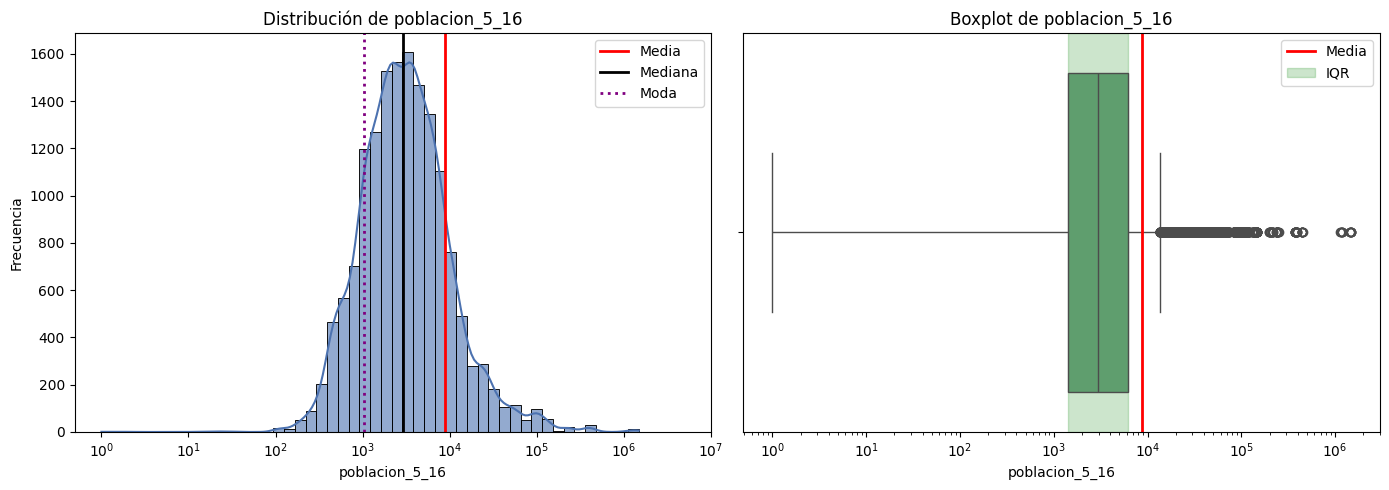

---------------------------------------------------------

Variable: tasa_matriculacion_5_16
Escala: Normal
Media: 0.8466
Mediana (Q2): 0.8498
Moda: 0.8270
Desviación estándar: 0.1835
Curtosis: 5.1941
Asimetría: 0.4334
---------------------------------------------------------
Q1 (25%): 0.7459
Q3 (75%): 0.9494
IQR: 0.2035
Valor mínimo: 0.0000
Valor máximo: 2.7903
Rango: 2.7903
Valores en cero: 6 (0.0382%)
Valores atípicos inferiores: 302 (1.9231%)
Valores atípicos superiores: 284 (1.8085%)
---------------------------------------------------------


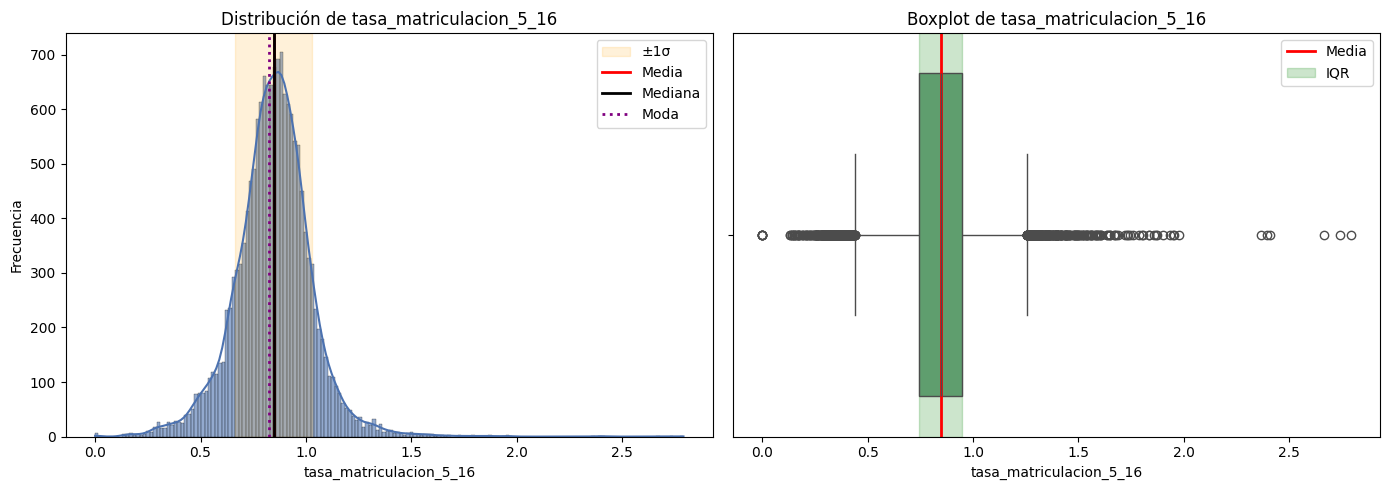

---------------------------------------------------------

Variable: cobertura_neta
Escala: Normal
Media: 0.8520
Mediana (Q2): 0.8600
Moda: 0.8740
Desviación estándar: 0.1681
Curtosis: 5.1861
Asimetría: 0.2770
---------------------------------------------------------
Q1 (25%): 0.7640
Q3 (75%): 0.9420
IQR: 0.1780
Valor mínimo: 0.0000
Valor máximo: 2.6454
Rango: 2.6454
Valores en cero: 9 (0.0573%)
Valores atípicos inferiores: 392 (2.4962%)
Valores atípicos superiores: 297 (1.8912%)
---------------------------------------------------------


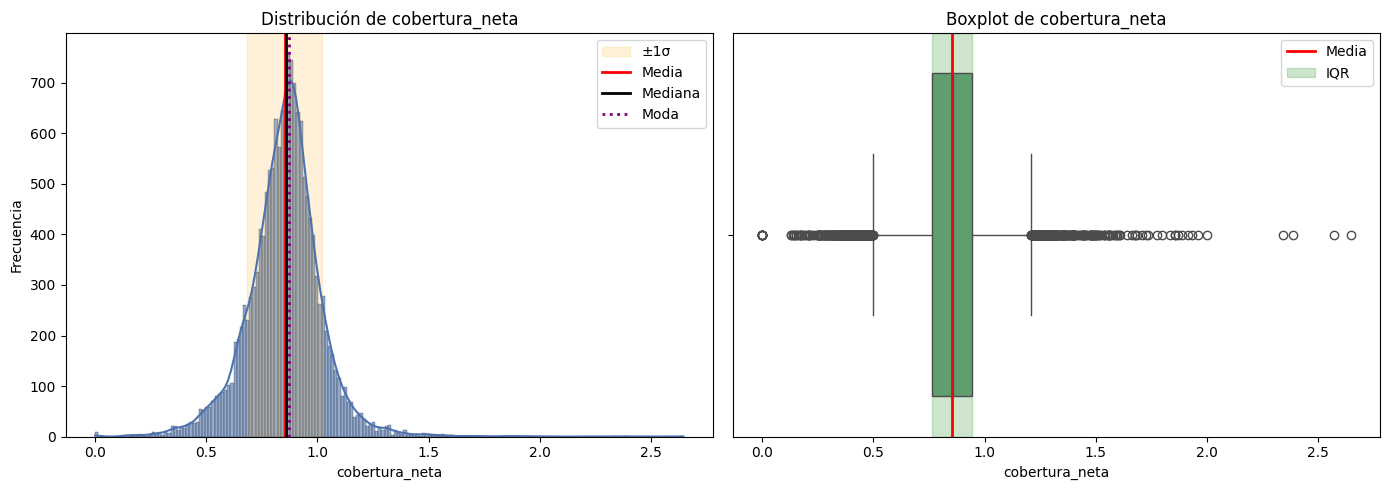

---------------------------------------------------------

Variable: cobertura_neta_transicion
Escala: Normal
Media: 0.5755
Mediana (Q2): 0.5769
Moda: 0.5000
Desviación estándar: 0.1608
Curtosis: 0.6315
Asimetría: 0.0191
---------------------------------------------------------
Q1 (25%): 0.4740
Q3 (75%): 0.6774
IQR: 0.2034
Valor mínimo: 0.0000
Valor máximo: 1.5047
Rango: 1.5047
Valores en cero: 10 (0.0637%)
Valores atípicos inferiores: 136 (0.8660%)
Valores atípicos superiores: 130 (0.8278%)
---------------------------------------------------------


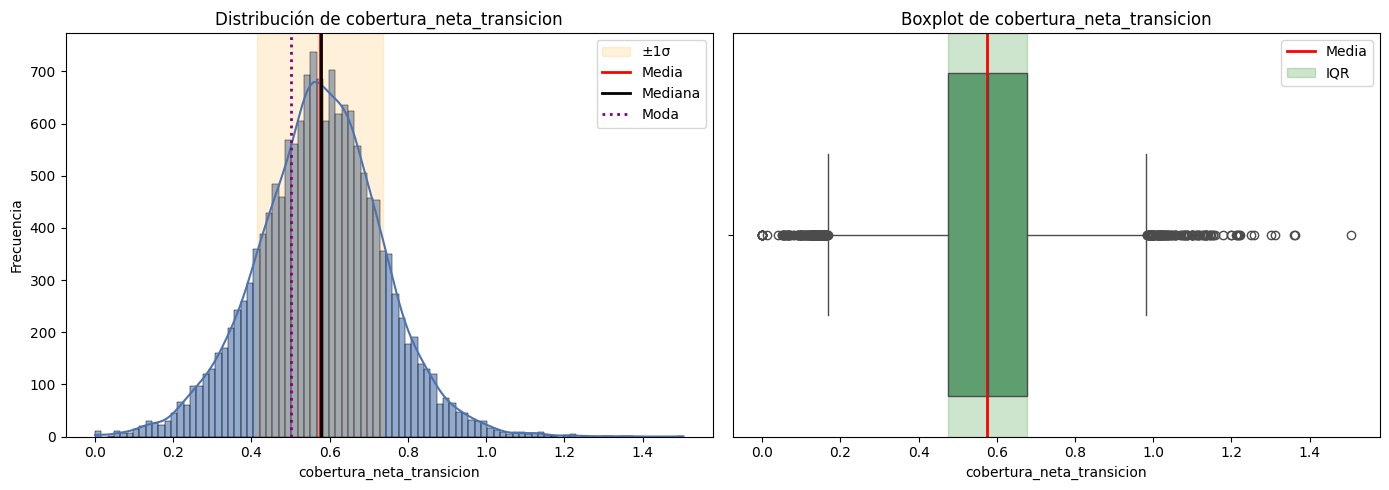

---------------------------------------------------------

Variable: cobertura_neta_primaria
Escala: Normal
Media: 0.8226
Mediana (Q2): 0.8249
Moda: 1.0000
Desviación estándar: 0.1704
Curtosis: 5.3242
Asimetría: 0.4776
---------------------------------------------------------
Q1 (25%): 0.7290
Q3 (75%): 0.9158
IQR: 0.1868
Valor mínimo: 0.0000
Valor máximo: 2.5496
Rango: 2.5496
Valores en cero: 9 (0.0573%)
Valores atípicos inferiores: 297 (1.8912%)
Valores atípicos superiores: 324 (2.0632%)
---------------------------------------------------------


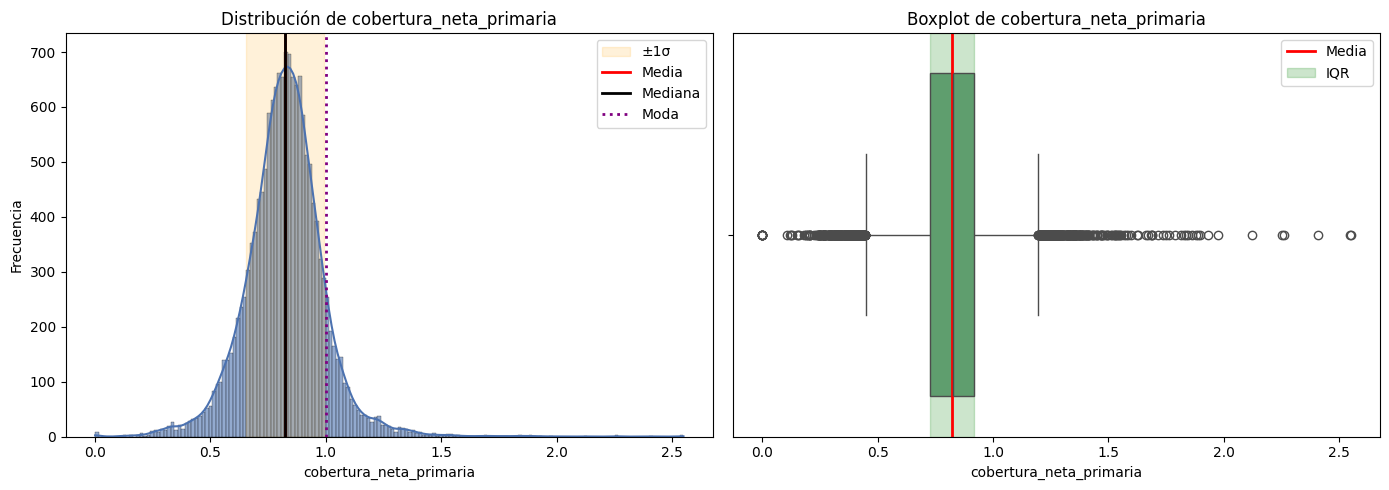

---------------------------------------------------------

Variable: cobertura_neta_secundaria
Escala: Normal
Media: 0.6973
Mediana (Q2): 0.7074
Moda: 0.0000
Desviación estándar: 0.1875
Curtosis: 3.3087
Asimetría: 0.0368
---------------------------------------------------------
Q1 (25%): 0.6027
Q3 (75%): 0.8031
IQR: 0.2004
Valor mínimo: 0.0000
Valor máximo: 2.2944
Rango: 2.2944
Valores en cero: 30 (0.1910%)
Valores atípicos inferiores: 517 (3.2922%)
Valores atípicos superiores: 248 (1.5792%)
---------------------------------------------------------


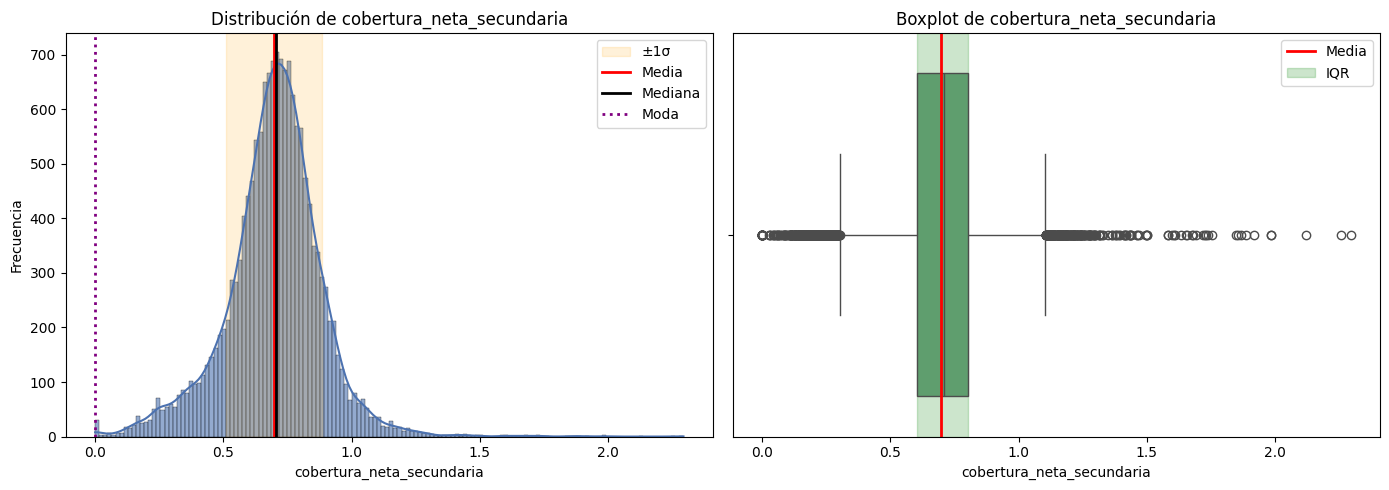

---------------------------------------------------------

Variable: cobertura_neta_media
Escala: Normal
Media: 0.4087
Mediana (Q2): 0.4132
Moda: 0.0000
Desviación estándar: 0.1569
Curtosis: 1.6576
Asimetría: 0.2416
---------------------------------------------------------
Q1 (25%): 0.3130
Q3 (75%): 0.5066
IQR: 0.1936
Valor mínimo: 0.0000
Valor máximo: 1.7026
Rango: 1.7026
Valores en cero: 57 (0.3630%)
Valores atípicos inferiores: 95 (0.6049%)
Valores atípicos superiores: 179 (1.1398%)
---------------------------------------------------------


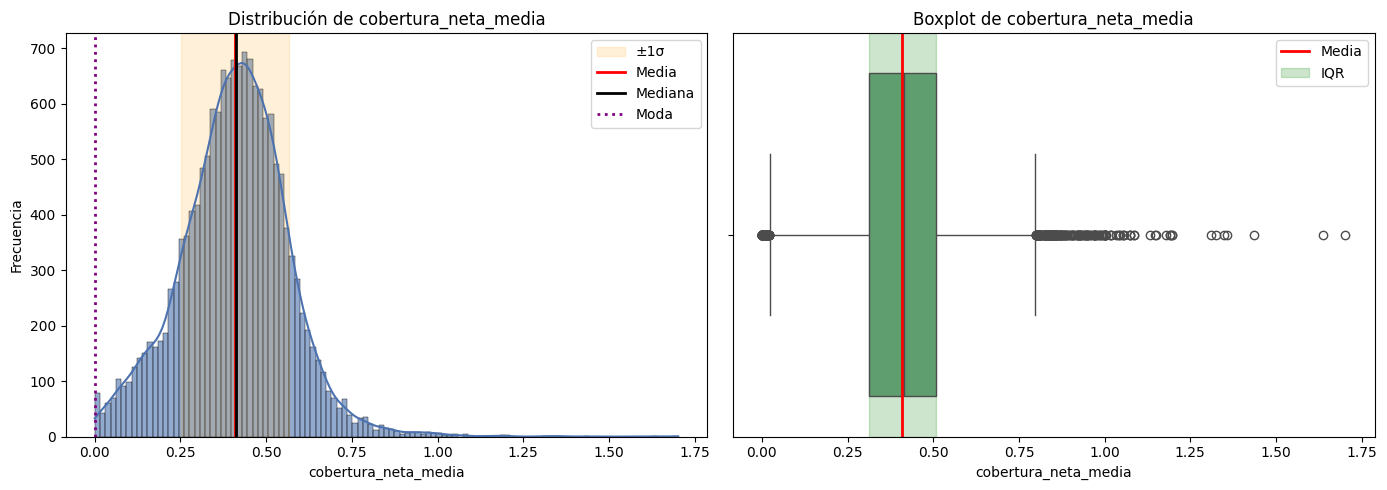

---------------------------------------------------------

Variable: cobertura_bruta
Escala: Normal
Media: 0.9702
Mediana (Q2): 0.9697
Moda: 1.0000
Desviación estándar: 0.2112
Curtosis: 3.1251
Asimetría: 0.3035
---------------------------------------------------------
Q1 (25%): 0.8508
Q3 (75%): 1.0856
IQR: 0.2348
Valor mínimo: 0.0000
Valor máximo: 2.8692
Rango: 2.8692
Valores en cero: 9 (0.0573%)
Valores atípicos inferiores: 269 (1.7129%)
Valores atípicos superiores: 312 (1.9868%)
---------------------------------------------------------


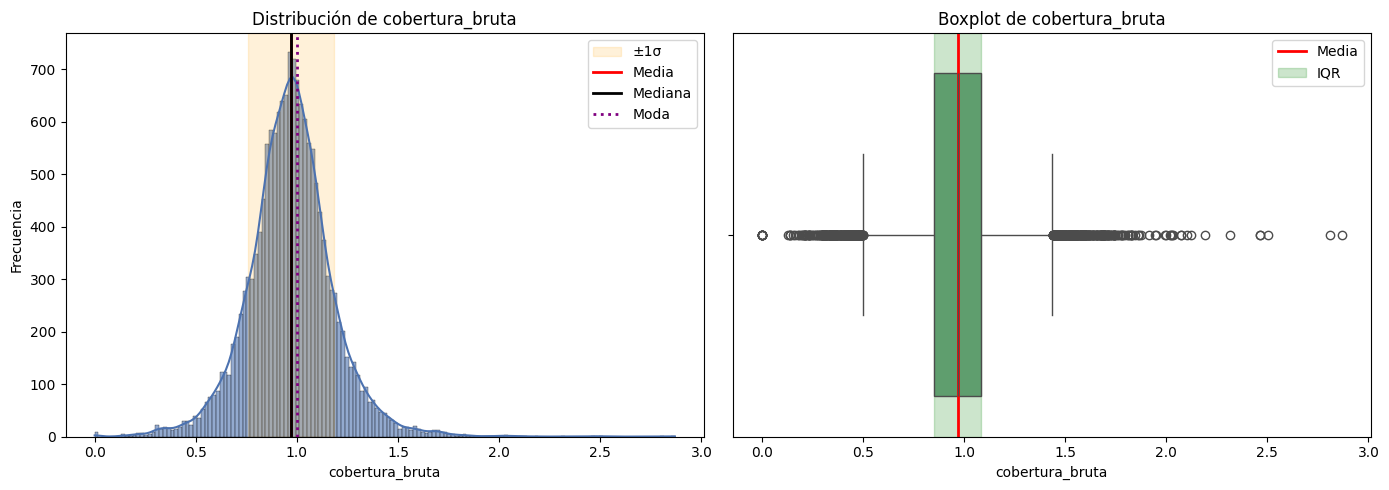

---------------------------------------------------------

Variable: cobertura_bruta_transicion
Escala: Normal
Media: 0.8681
Mediana (Q2): 0.8485
Moda: 1.0000
Desviación estándar: 0.2531
Curtosis: 2.2524
Asimetría: 0.7763
---------------------------------------------------------
Q1 (25%): 0.7122
Q3 (75%): 0.9949
IQR: 0.2827
Valor mínimo: 0.0000
Valor máximo: 2.5929
Rango: 2.5929
Valores en cero: 9 (0.0573%)
Valores atípicos inferiores: 103 (0.6559%)
Valores atípicos superiores: 505 (3.2157%)
---------------------------------------------------------


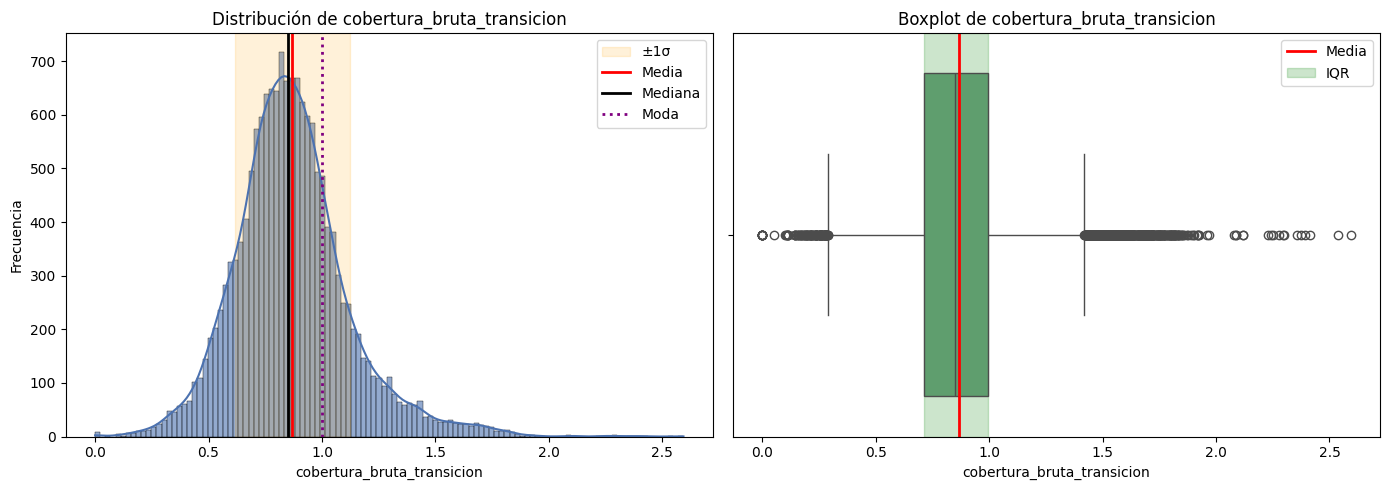

---------------------------------------------------------

Variable: cobertura_bruta_primaria
Escala: Normal
Media: 1.0434
Mediana (Q2): 1.0254
Moda: 1.0000
Desviación estándar: 0.2503
Curtosis: 3.5468
Asimetría: 0.8251
---------------------------------------------------------
Q1 (25%): 0.8907
Q3 (75%): 1.1690
IQR: 0.2783
Valor mínimo: 0.0000
Valor máximo: 3.2640
Rango: 3.2640
Valores en cero: 9 (0.0573%)
Valores atípicos inferiores: 147 (0.9361%)
Valores atípicos superiores: 450 (2.8655%)
---------------------------------------------------------


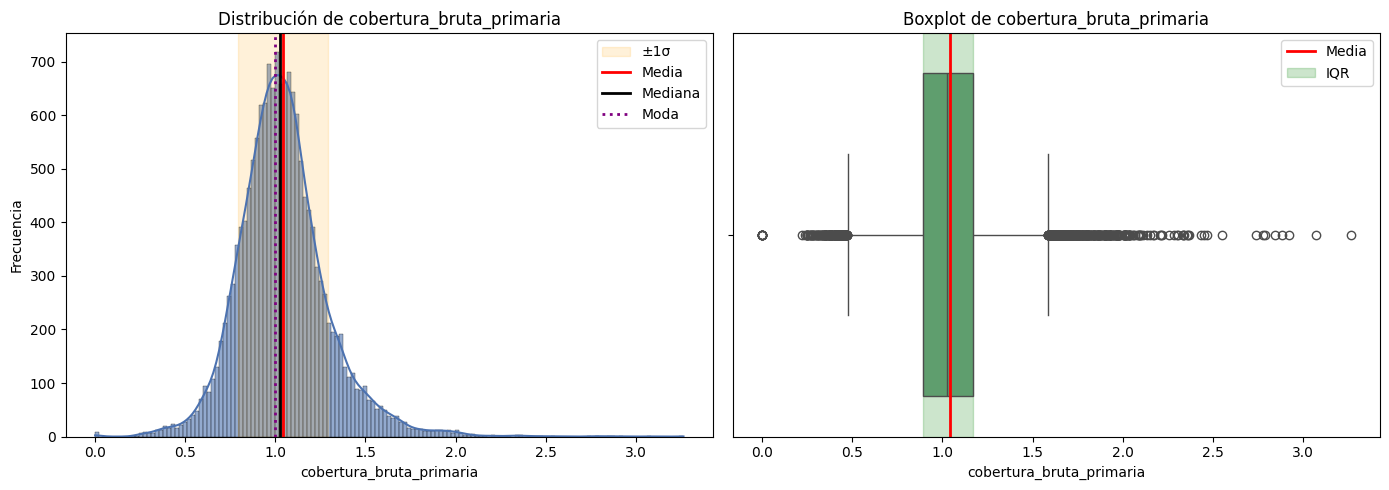

---------------------------------------------------------

Variable: cobertura_bruta_secundaria
Escala: Normal
Media: 1.0053
Mediana (Q2): 1.0090
Moda: 1.0000
Desviación estándar: 0.2561
Curtosis: 2.8499
Asimetría: 0.2195
---------------------------------------------------------
Q1 (25%): 0.8590
Q3 (75%): 1.1499
IQR: 0.2909
Valor mínimo: 0.0000
Valor máximo: 3.0171
Rango: 3.0171
Valores en cero: 30 (0.1910%)
Valores atípicos inferiores: 285 (1.8148%)
Valores atípicos superiores: 269 (1.7129%)
---------------------------------------------------------


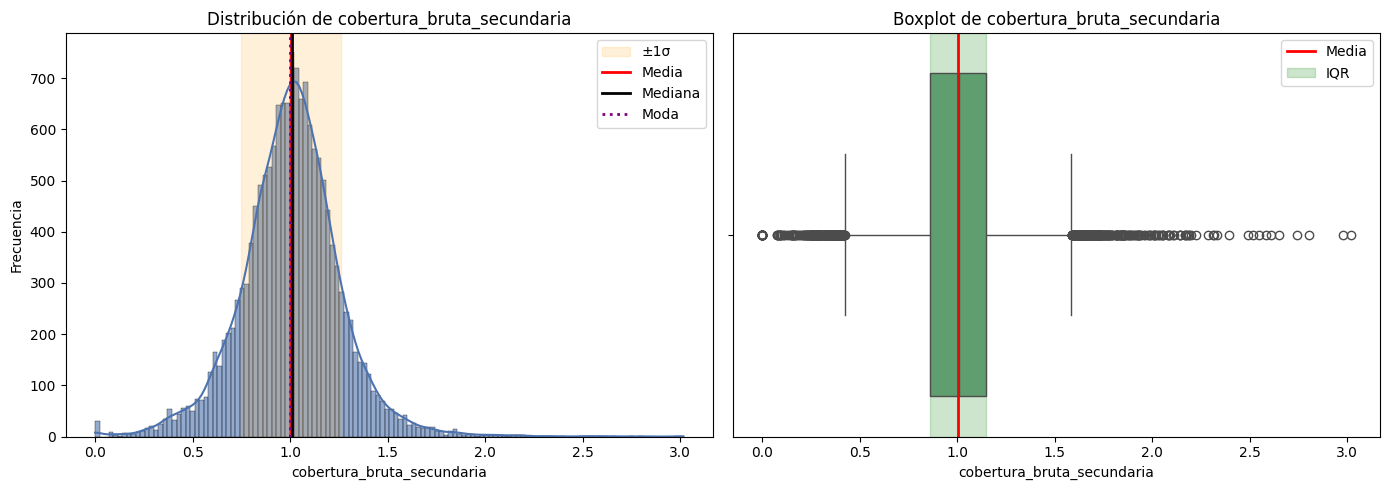

---------------------------------------------------------

Variable: cobertura_bruta_media
Escala: Normal
Media: 0.7586
Mediana (Q2): 0.7513
Moda: 0.0000
Desviación estándar: 0.2702
Curtosis: 12.9899
Asimetría: 1.4587
---------------------------------------------------------
Q1 (25%): 0.5972
Q3 (75%): 0.9019
IQR: 0.3047
Valor mínimo: 0.0000
Valor máximo: 4.8962
Rango: 4.8962
Valores en cero: 49 (0.3120%)
Valores atípicos inferiores: 116 (0.7387%)
Valores atípicos superiores: 301 (1.9167%)
---------------------------------------------------------


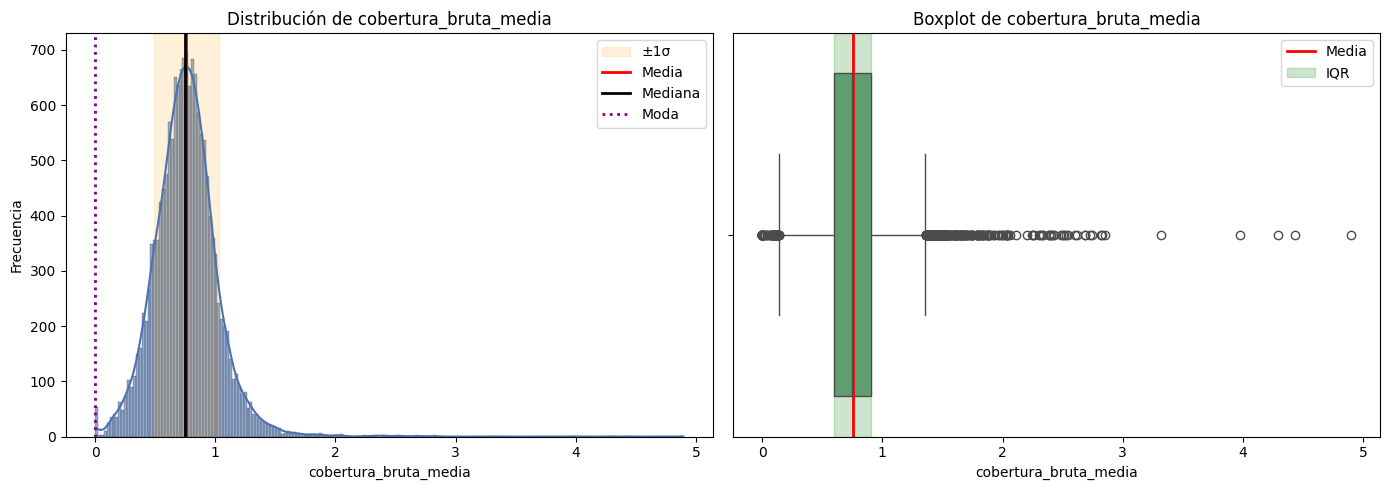

---------------------------------------------------------

Variable: desercion
Escala: Normal
Media: 0.0350
Mediana (Q2): 0.0316
Moda: 0.0000
Desviación estándar: 0.0215
Curtosis: 3.0022
Asimetría: 1.1955
---------------------------------------------------------
Q1 (25%): 0.0196
Q3 (75%): 0.0467
IQR: 0.0271
Valor mínimo: 0.0000
Valor máximo: 0.2790
Rango: 0.2790
Valores en cero: 61 (0.3884%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 364 (2.3179%)
---------------------------------------------------------


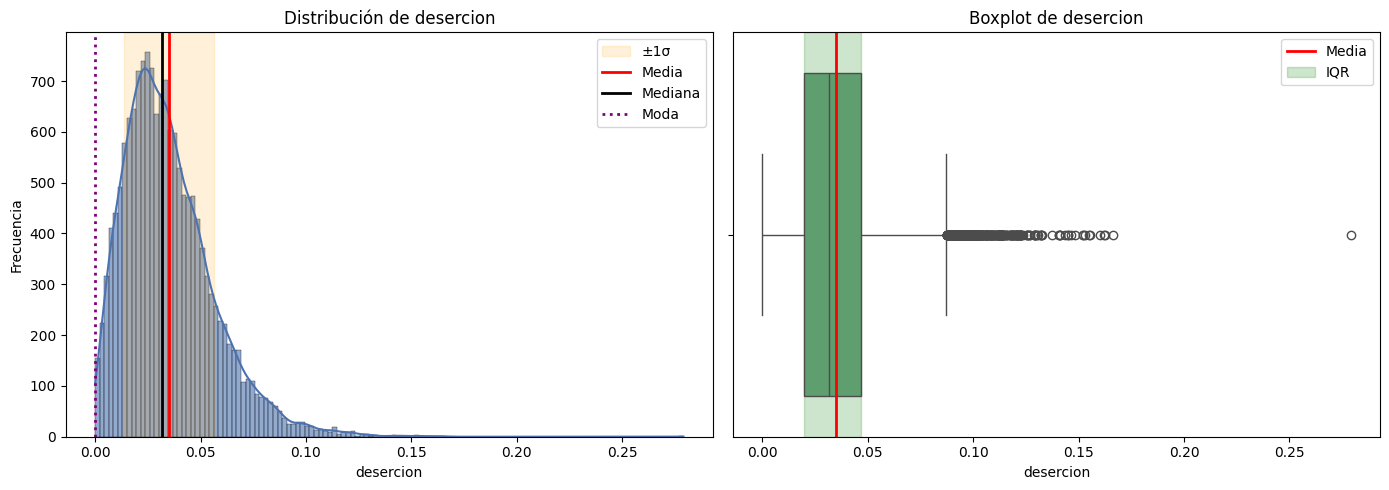

---------------------------------------------------------

Variable: desercion_transicion
Escala: Normal
Media: 0.0350
Mediana (Q2): 0.0303
Moda: 0.0000
Desviación estándar: 0.0276
Curtosis: 8.9151
Asimetría: 1.8161
---------------------------------------------------------
Q1 (25%): 0.0158
Q3 (75%): 0.0481
IQR: 0.0323
Valor mínimo: 0.0000
Valor máximo: 0.4286
Rango: 0.4286
Valores en cero: 1357 (8.6411%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 471 (2.9992%)
---------------------------------------------------------


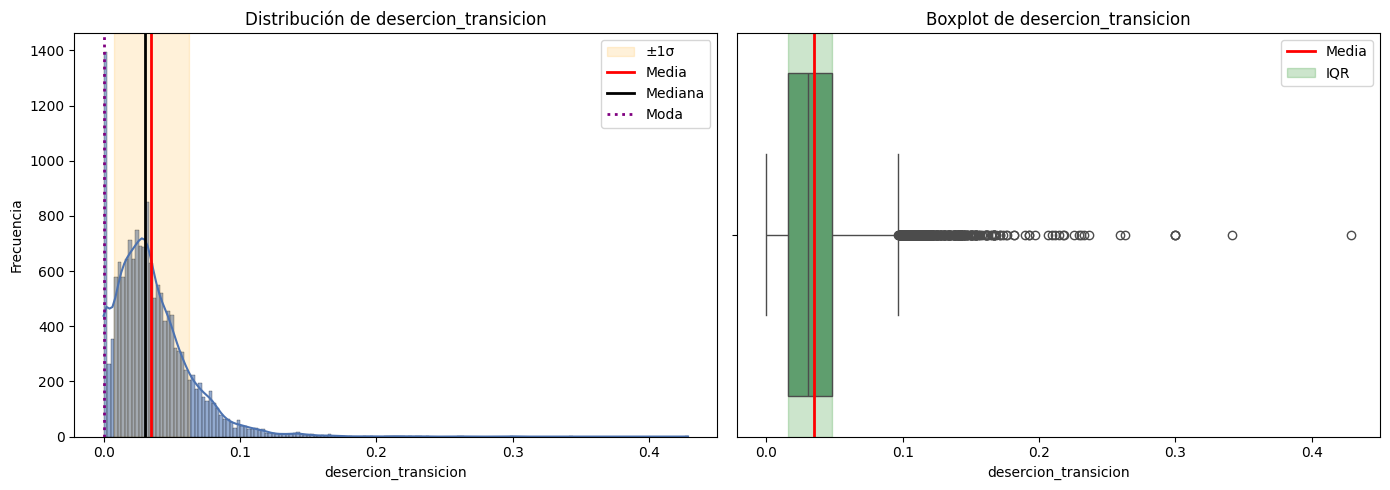

---------------------------------------------------------

Variable: desercion_primaria
Escala: Normal
Media: 0.0275
Mediana (Q2): 0.0232
Moda: 0.0000
Desviación estándar: 0.0202
Curtosis: 2.8281
Asimetría: 1.3535
---------------------------------------------------------
Q1 (25%): 0.0128
Q3 (75%): 0.0377
IQR: 0.0249
Valor mínimo: 0.0000
Valor máximo: 0.1831
Rango: 0.1831
Valores en cero: 407 (2.5917%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 468 (2.9801%)
---------------------------------------------------------


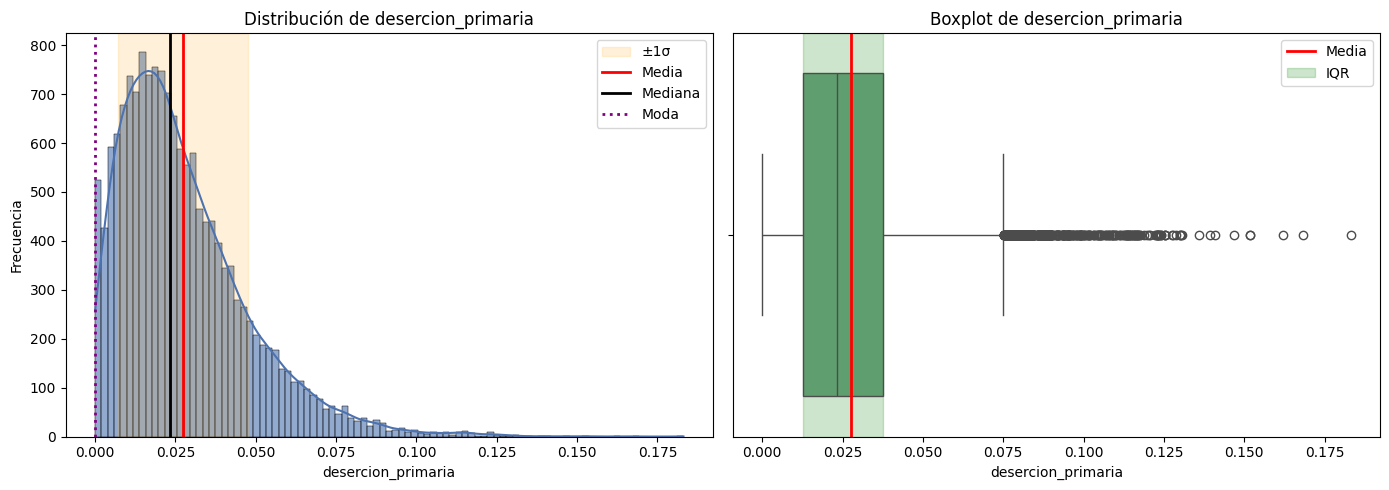

---------------------------------------------------------

Variable: desercion_secundaria
Escala: Normal
Media: 0.0460
Mediana (Q2): 0.0408
Moda: 0.0000
Desviación estándar: 0.0307
Curtosis: 6.1796
Asimetría: 1.4701
---------------------------------------------------------
Q1 (25%): 0.0240
Q3 (75%): 0.0625
IQR: 0.0385
Valor mínimo: 0.0000
Valor máximo: 0.4714
Rango: 0.4714
Valores en cero: 211 (1.3436%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 372 (2.3688%)
---------------------------------------------------------


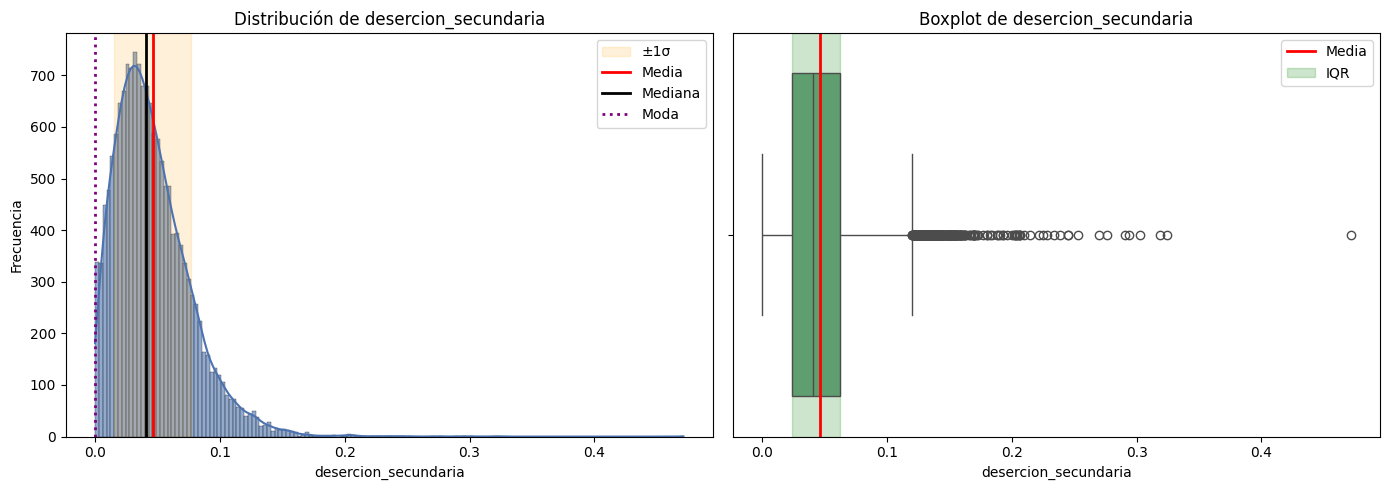

---------------------------------------------------------

Variable: desercion_media
Escala: Normal
Media: 0.0347
Mediana (Q2): 0.0289
Moda: 0.0000
Desviación estándar: 0.0317
Curtosis: 71.0803
Asimetría: 5.8444
---------------------------------------------------------
Q1 (25%): 0.0168
Q3 (75%): 0.0449
IQR: 0.0281
Valor mínimo: 0.0000
Valor máximo: 0.6250
Rango: 0.6250
Valores en cero: 787 (5.0115%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 608 (3.8716%)
---------------------------------------------------------


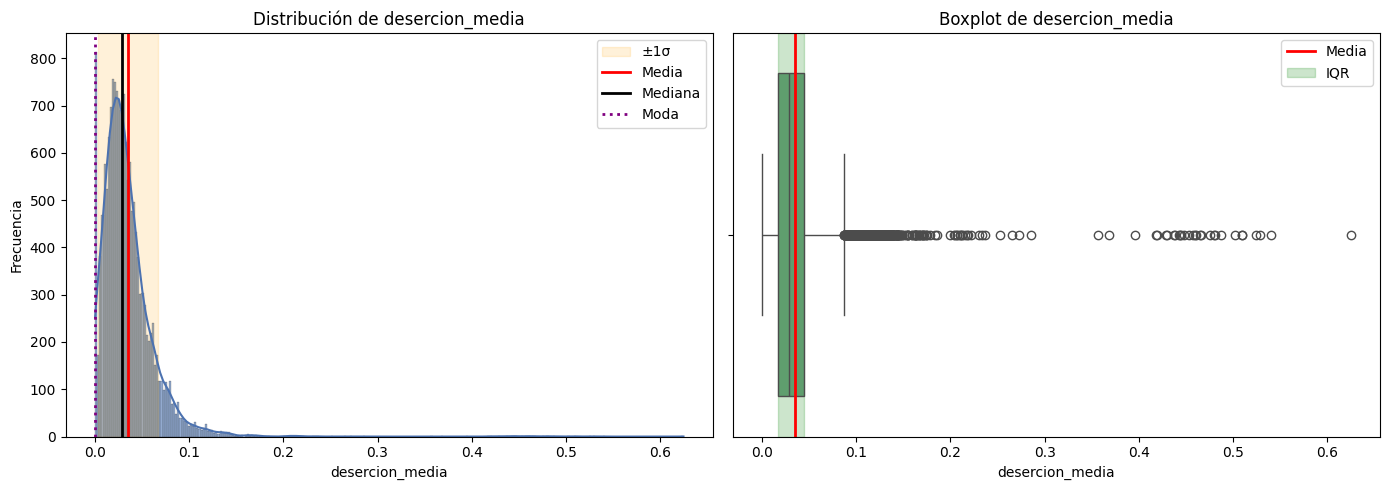

---------------------------------------------------------

Variable: aprobacion
Escala: Normal
Media: 0.9156
Mediana (Q2): 0.9192
Moda: 1.0000
Desviación estándar: 0.0514
Curtosis: 27.1365
Asimetría: -2.1718
---------------------------------------------------------
Q1 (25%): 0.8844
Q3 (75%): 0.9543
IQR: 0.0699
Valor mínimo: 0.0000
Valor máximo: 1.0000
Rango: 1.0000
Valores en cero: 4 (0.0255%)
Valores atípicos inferiores: 153 (0.9743%)
Valores atípicos superiores: 0 (0.0000%)
---------------------------------------------------------


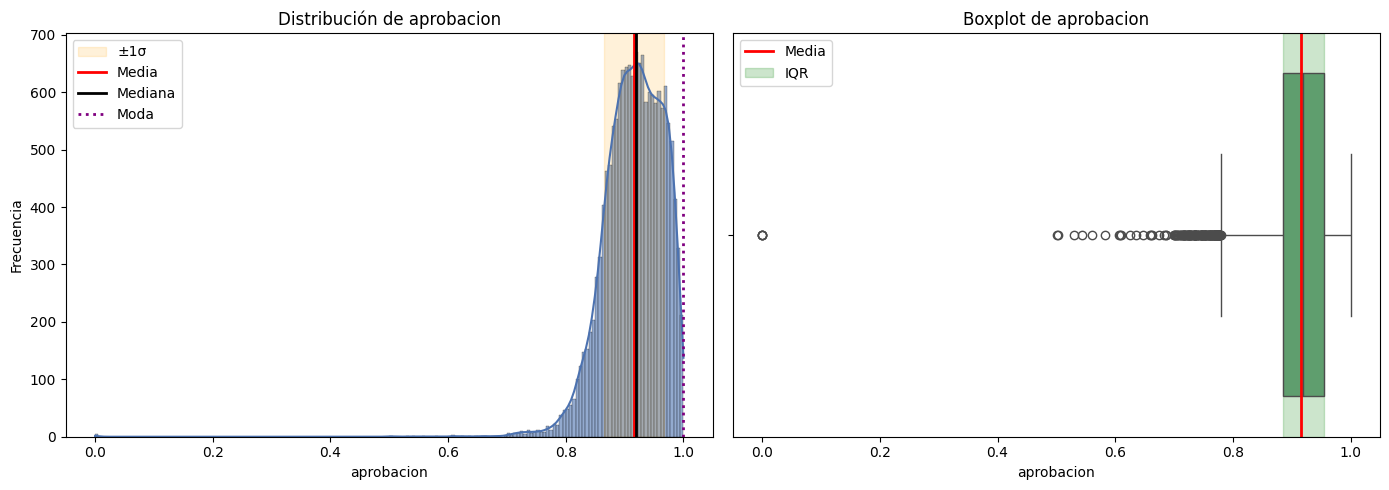

---------------------------------------------------------

Variable: aprobacion_primaria
Escala: Normal
Media: 0.9320
Mediana (Q2): 0.9381
Moda: 1.0000
Desviación estándar: 0.0503
Curtosis: 35.2864
Asimetría: -2.9903
---------------------------------------------------------
Q1 (25%): 0.9060
Q3 (75%): 0.9686
IQR: 0.0626
Valor mínimo: 0.0000
Valor máximo: 1.0000
Rango: 1.0000
Valores en cero: 4 (0.0255%)
Valores atípicos inferiores: 278 (1.7702%)
Valores atípicos superiores: 0 (0.0000%)
---------------------------------------------------------


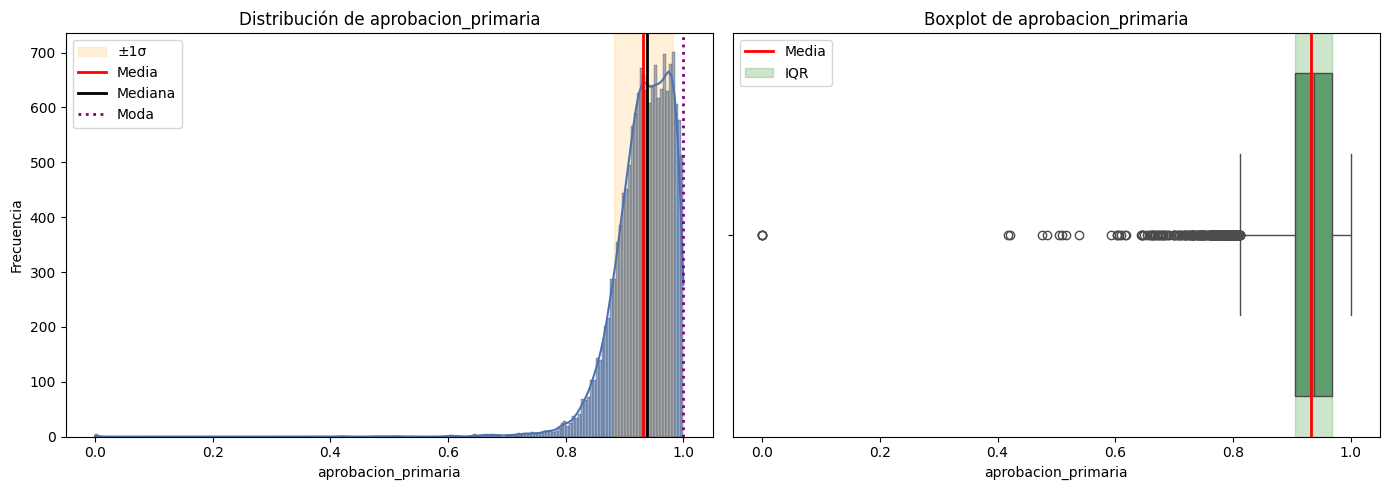

---------------------------------------------------------

Variable: aprobacion_secundaria
Escala: Normal
Media: 0.8822
Mediana (Q2): 0.8886
Moda: 1.0000
Desviación estándar: 0.0789
Curtosis: 17.7513
Asimetría: -2.1194
---------------------------------------------------------
Q1 (25%): 0.8354
Q3 (75%): 0.9424
IQR: 0.1070
Valor mínimo: 0.0000
Valor máximo: 1.0000
Rango: 1.0000
Valores en cero: 18 (0.1146%)
Valores atípicos inferiores: 133 (0.8469%)
Valores atípicos superiores: 0 (0.0000%)
---------------------------------------------------------


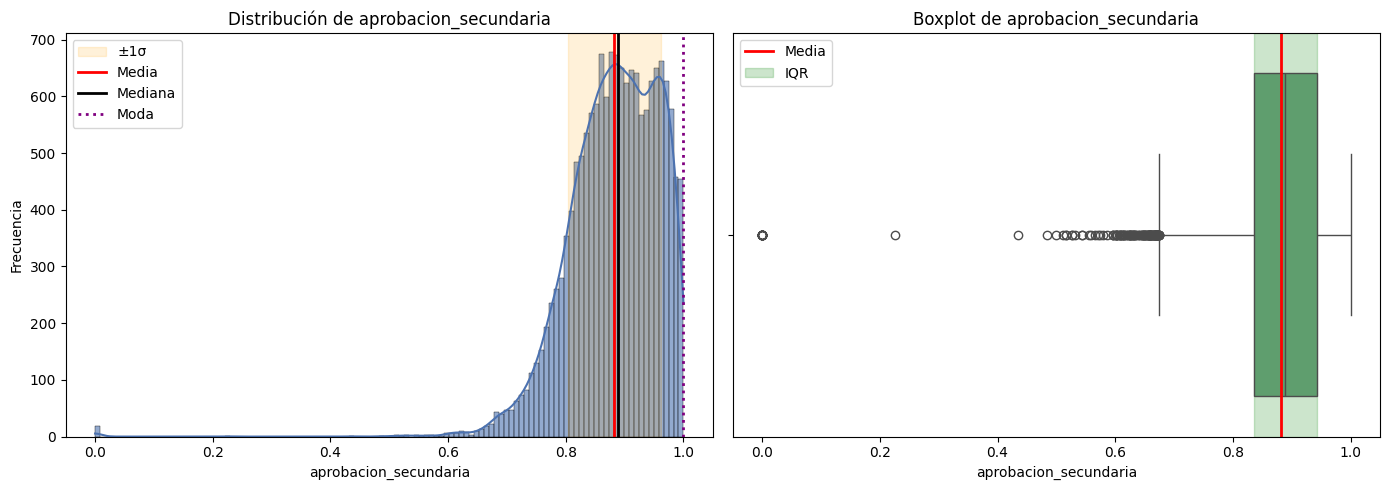

---------------------------------------------------------

Variable: aprobacion_media
Escala: Normal
Media: 0.9213
Mediana (Q2): 0.9323
Moda: 1.0000
Desviación estándar: 0.0698
Curtosis: 57.7491
Asimetría: -5.2672
---------------------------------------------------------
Q1 (25%): 0.8947
Q3 (75%): 0.9634
IQR: 0.0687
Valor mínimo: 0.0000
Valor máximo: 1.0000
Rango: 1.0000
Valores en cero: 28 (0.1783%)
Valores atípicos inferiores: 425 (2.7063%)
Valores atípicos superiores: 0 (0.0000%)
---------------------------------------------------------


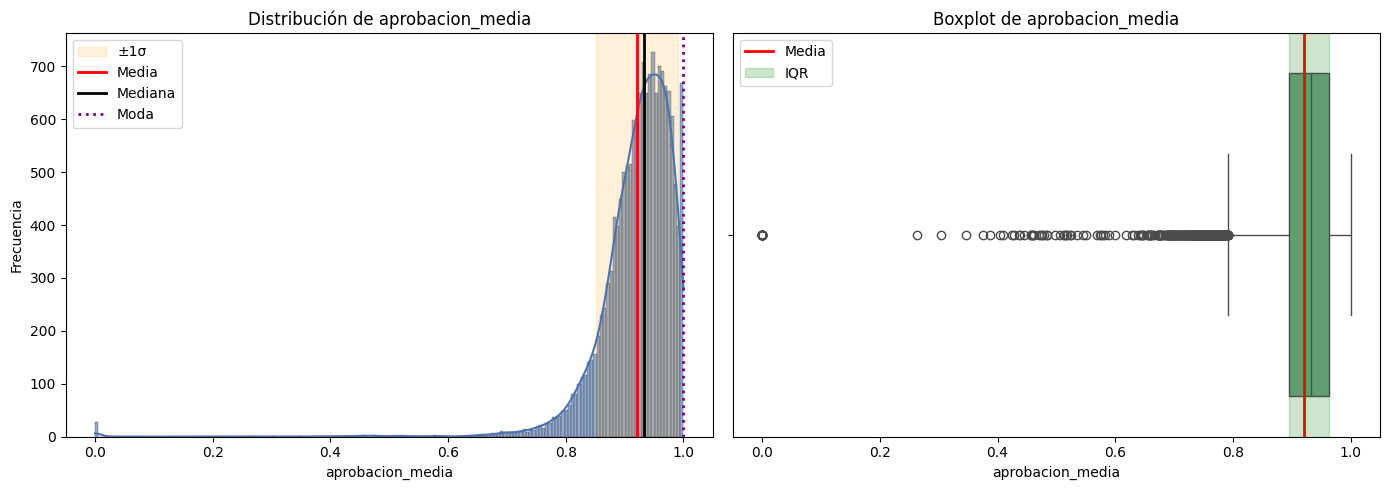

---------------------------------------------------------

Variable: reprobacion
Escala: Normal
Media: 0.0484
Mediana (Q2): 0.0468
Moda: 0.0000
Desviación estándar: 0.0394
Curtosis: 3.0524
Asimetría: 0.9209
---------------------------------------------------------
Q1 (25%): 0.0120
Q3 (75%): 0.0745
IQR: 0.0625
Valor mínimo: 0.0000
Valor máximo: 0.4939
Rango: 0.4939
Valores en cero: 1654 (10.5323%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 98 (0.6240%)
---------------------------------------------------------


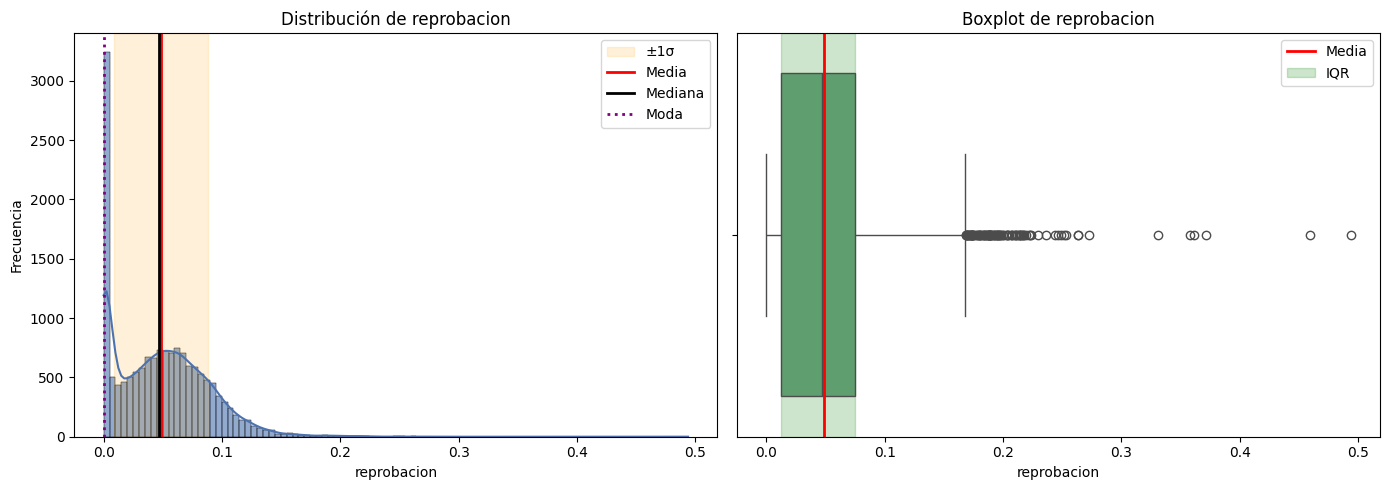

---------------------------------------------------------

Variable: reprobacion_primaria
Escala: Normal
Media: 0.0394
Mediana (Q2): 0.0346
Moda: 0.0000
Desviación estándar: 0.0376
Curtosis: 10.3492
Asimetría: 1.8382
---------------------------------------------------------
Q1 (25%): 0.0061
Q3 (75%): 0.0601
IQR: 0.0540
Valor mínimo: 0.0000
Valor máximo: 0.5197
Rango: 0.5197
Valores en cero: 3070 (19.5492%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 203 (1.2927%)
---------------------------------------------------------


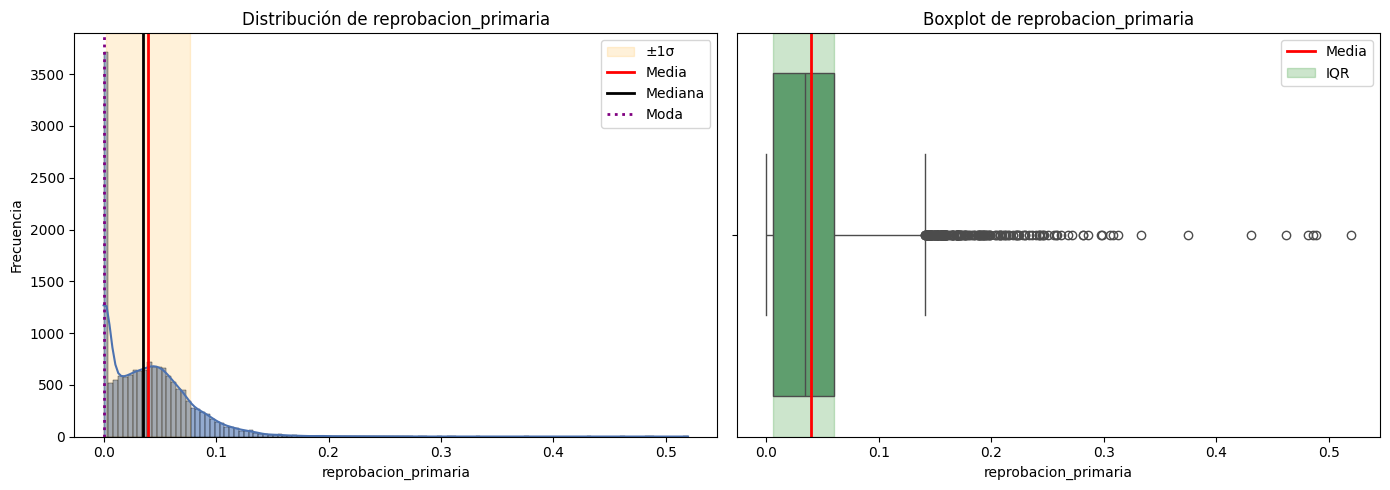

---------------------------------------------------------

Variable: reprobacion_secundaria
Escala: Normal
Media: 0.0696
Mediana (Q2): 0.0641
Moda: 0.0000
Desviación estándar: 0.0609
Curtosis: 1.9826
Asimetría: 0.9156
---------------------------------------------------------
Q1 (25%): 0.0106
Q3 (75%): 0.1095
IQR: 0.0989
Valor mínimo: 0.0000
Valor máximo: 0.7697
Rango: 0.7697
Valores en cero: 3040 (19.3581%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 100 (0.6368%)
---------------------------------------------------------


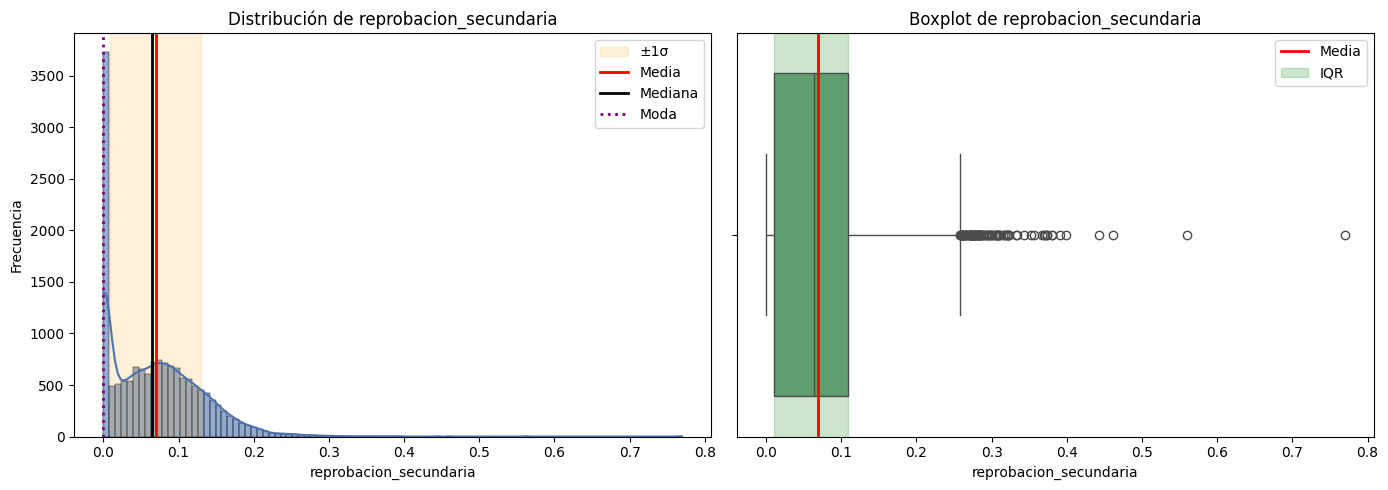

---------------------------------------------------------

Variable: reprobacion_media
Escala: Normal
Media: 0.0415
Mediana (Q2): 0.0321
Moda: 0.0000
Desviación estándar: 0.0416
Curtosis: 10.2243
Asimetría: 1.8965
---------------------------------------------------------
Q1 (25%): 0.0076
Q3 (75%): 0.0640
IQR: 0.0564
Valor mínimo: 0.0000
Valor máximo: 0.6786
Rango: 0.6786
Valores en cero: 2884 (18.3647%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 308 (1.9613%)
---------------------------------------------------------


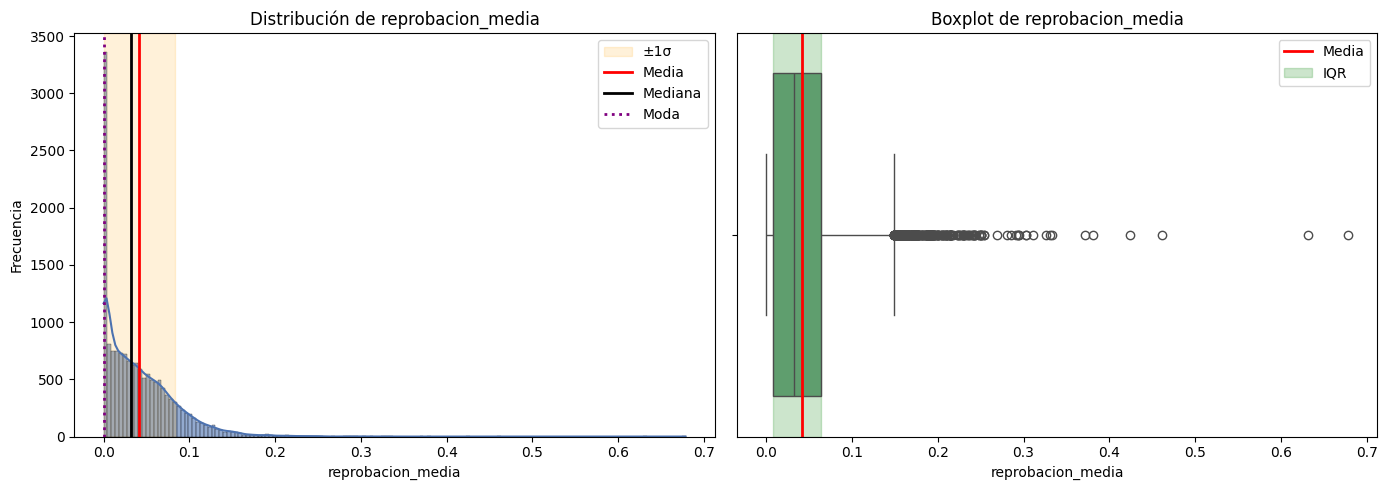

---------------------------------------------------------

Variable: repitencia
Escala: Normal
Media: 0.0367
Mediana (Q2): 0.0247
Moda: 0.0000
Desviación estándar: 0.0360
Curtosis: 3.3653
Asimetría: 1.4275
---------------------------------------------------------
Q1 (25%): 0.0081
Q3 (75%): 0.0577
IQR: 0.0496
Valor mínimo: 0.0000
Valor máximo: 0.3747
Rango: 0.3747
Valores en cero: 891 (5.6737%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 259 (1.6493%)
---------------------------------------------------------


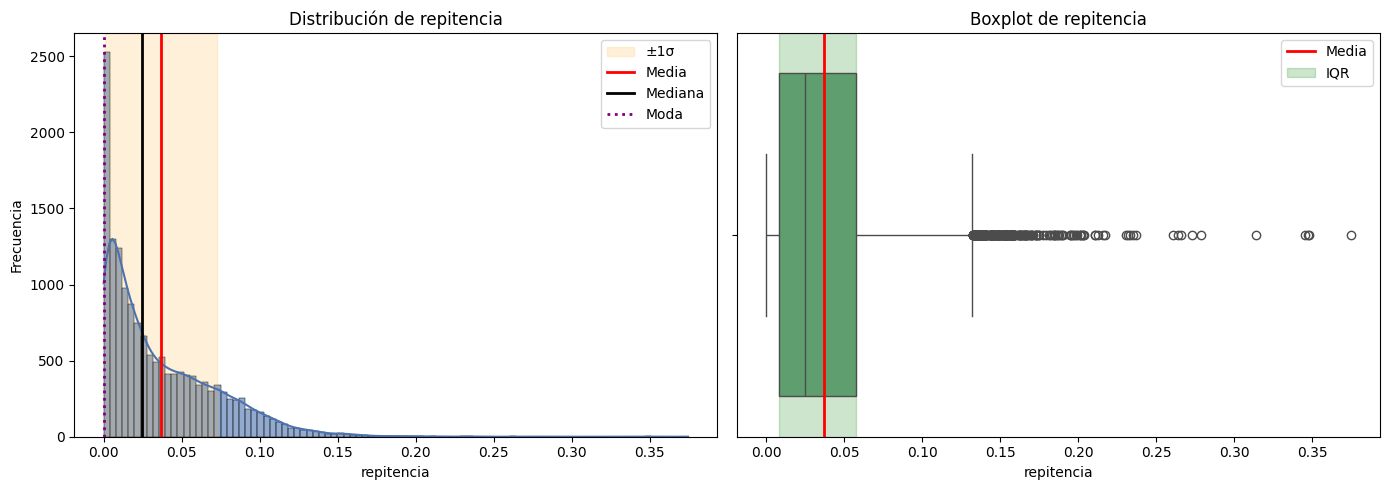

---------------------------------------------------------

Variable: repitencia_transicion
Escala: Normal
Media: 0.0116
Mediana (Q2): 0.0000
Moda: 0.0000
Desviación estándar: 0.0281
Curtosis: 62.9467
Asimetría: 6.2183
---------------------------------------------------------
Q1 (25%): 0.0000
Q3 (75%): 0.0118
IQR: 0.0118
Valor mínimo: 0.0000
Valor máximo: 0.6667
Rango: 0.6667
Valores en cero: 8119 (51.7002%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 1760 (11.2073%)
---------------------------------------------------------


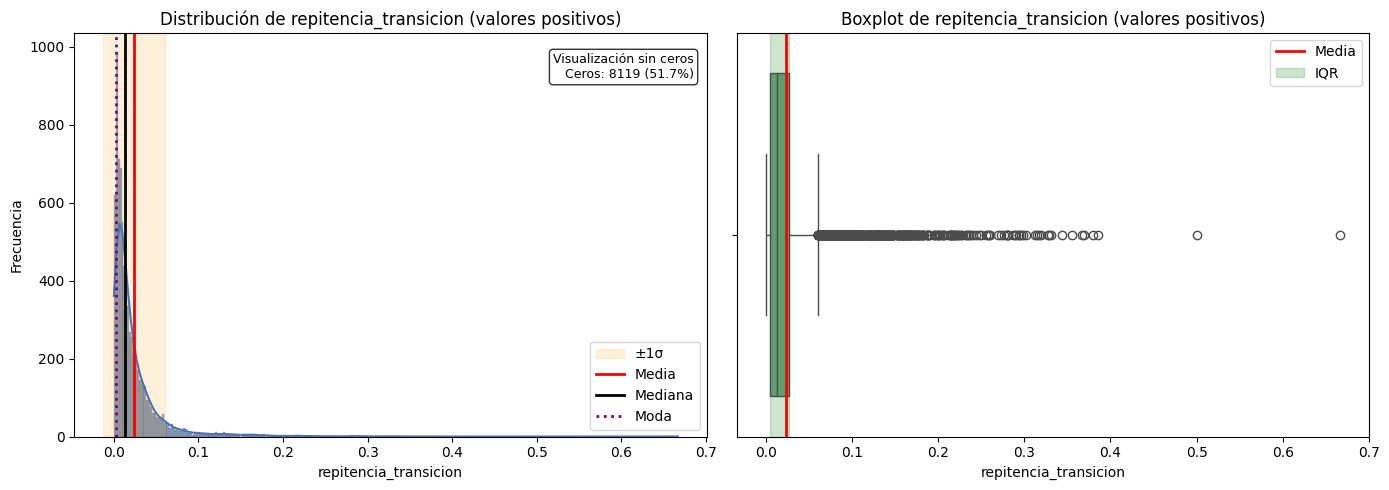

---------------------------------------------------------

Variable: repitencia_primaria
Escala: Normal
Media: 0.0352
Mediana (Q2): 0.0217
Moda: 0.0000
Desviación estándar: 0.0388
Curtosis: 7.1781
Asimetría: 2.0196
---------------------------------------------------------
Q1 (25%): 0.0069
Q3 (75%): 0.0528
IQR: 0.0459
Valor mínimo: 0.0000
Valor máximo: 0.5076
Rango: 0.5076
Valores en cero: 1422 (9.0550%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 567 (3.6105%)
---------------------------------------------------------


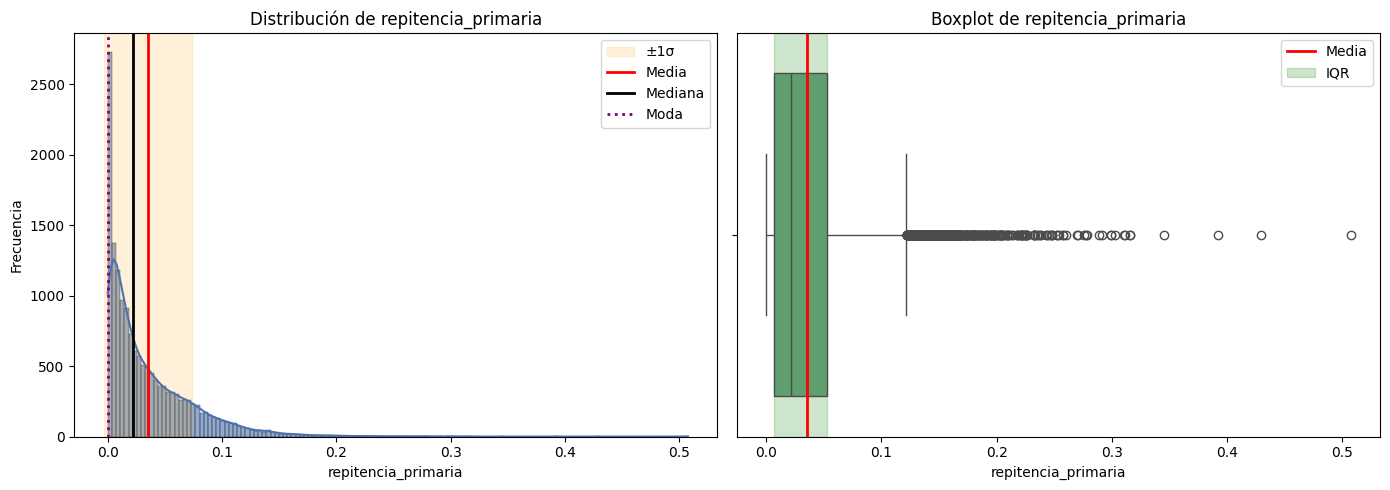

---------------------------------------------------------

Variable: repitencia_secundaria
Escala: Normal
Media: 0.0481
Mediana (Q2): 0.0316
Moda: 0.0000
Desviación estándar: 0.0484
Curtosis: 2.0082
Asimetría: 1.2594
---------------------------------------------------------
Q1 (25%): 0.0086
Q3 (75%): 0.0779
IQR: 0.0693
Valor mínimo: 0.0000
Valor máximo: 0.5507
Rango: 0.5507
Valores en cero: 1612 (10.2649%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 201 (1.2799%)
---------------------------------------------------------


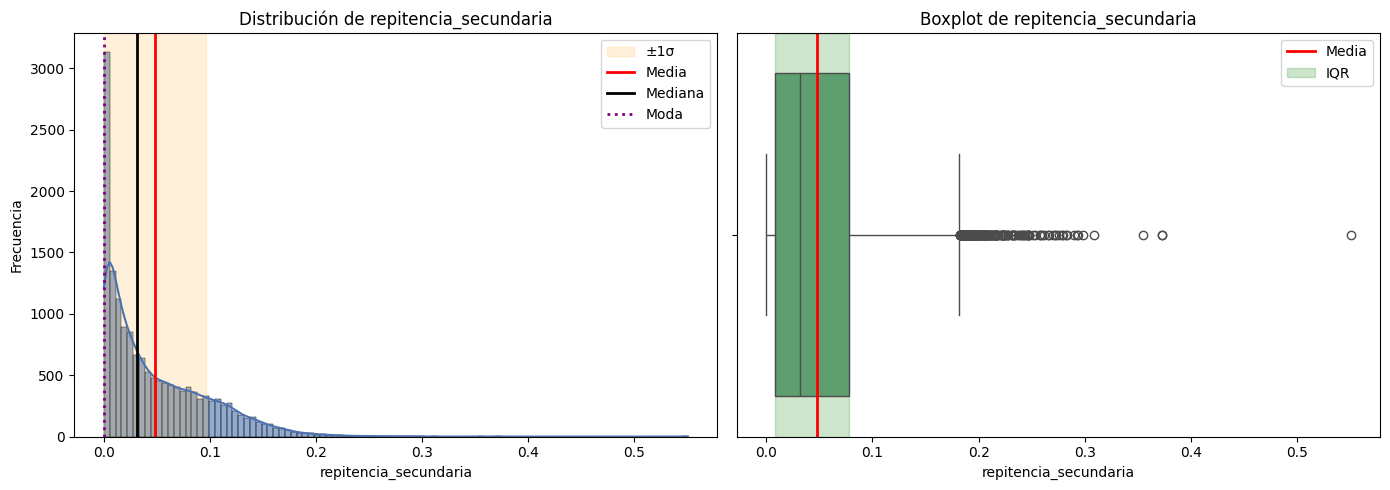

---------------------------------------------------------

Variable: repitencia_media
Escala: Normal
Media: 0.0184
Mediana (Q2): 0.0101
Moda: 0.0000
Desviación estándar: 0.0236
Curtosis: 16.7620
Asimetría: 2.7651
---------------------------------------------------------
Q1 (25%): 0.0000
Q3 (75%): 0.0282
IQR: 0.0282
Valor mínimo: 0.0000
Valor máximo: 0.3684
Rango: 0.3684
Valores en cero: 4429 (28.2030%)
Valores atípicos inferiores: 0 (0.0000%)
Valores atípicos superiores: 511 (3.2539%)
---------------------------------------------------------


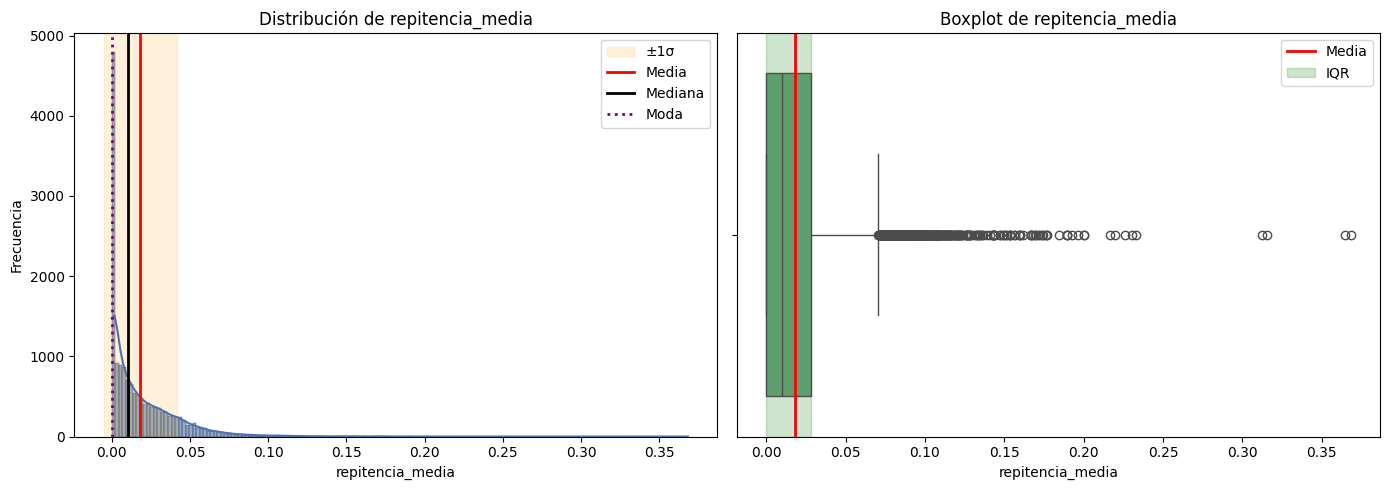

In [57]:
log_scale_vars = {"poblacion_5_16"}
analisis_estadistico_dataset(df, variables=columnas_analisis, log_scale_vars=log_scale_vars)


### Análisis de correlación

La matriz de correlación permite identificar relaciones lineales entre las variables numéricas seleccionadas.


In [58]:
columnas_validas = columnas_analisis.copy()
df[columnas_validas].corr()

,poblacion_5_16,tasa_matriculacion_5_16,cobertura_neta,cobertura_neta_transicion,cobertura_neta_primaria,cobertura_neta_secundaria,cobertura_neta_media,cobertura_bruta,cobertura_bruta_transicion,cobertura_bruta_primaria,cobertura_bruta_secundaria,cobertura_bruta_media,desercion,desercion_transicion,desercion_primaria,desercion_secundaria,desercion_media,aprobacion,aprobacion_primaria,aprobacion_secundaria,aprobacion_media,reprobacion,reprobacion_primaria,reprobacion_secundaria,reprobacion_media,repitencia,repitencia_transicion,repitencia_primaria,repitencia_secundaria,repitencia_media
poblacion_5_16,1.000000,0.043441,0.044578,0.048145,0.046256,0.048208,0.053657,0.032564,0.024098,0.018925,0.027721,0.048182,0.001154,0.009128,0.021037,-0.016366,-0.019076,-0.003007,-0.003648,0.001466,0.003714,0.006966,-0.002495,0.011797,0.017688,0.008735,0.009571,0.005207,0.016499,0.015040
tasa_matriculacion_5_16,0.043441,1.000000,0.891472,0.598402,0.830388,0.722671,0.517212,0.880395,0.655440,0.736407,0.783354,0.572041,0.017365,0.023190,0.036474,-0.025989,-0.030376,-0.016388,0.016378,-0.004623,0.018756,0.046920,-0.000961,0.079061,0.083718,-0.056528,-0.017116,-0.081374,-0.004626,-0.005364
cobertura_neta,0.044578,0.891472,1.000000,0.667097,0.916347,0.804485,0.578061,0.889010,0.654686,0.741121,0.799461,0.586372,0.003991,0.017272,0.024240,-0.037127,-0.036855,0.001440,0.038320,0.011540,0.032830,0.032699,-0.021379,0.069363,0.075404,-0.077872,-0.028591,-0.103925,-0.019533,-0.022201
cobertura_neta_transicion,0.048145,0.598402,0.667097,1.000000,0.664401,0.540019,0.431078,0.576086,0.646933,0.462114,0.494830,0.377220,0.002007,-0.017033,0.013520,-0.019662,-0.041004,-0.035328,0.010405,-0.054462,-0.006411,0.076086,0.013031,0.124604,0.103498,-0.004275,-0.050317,-0.034007,0.054474,0.037797
cobertura_neta_primaria,0.046256,0.830388,0.916347,0.664401,1.000000,0.652319,0.395241,0.829548,0.653361,0.798170,0.666380,0.435442,0.043222,0.041758,0.060457,0.010743,-0.006690,-0.038258,-0.016836,-0.029747,-0.007696,0.060048,0.026690,0.084120,0.091044,-0.076992,-0.048138,-0.091756,-0.031041,-0.022752
cobertura_neta_secundaria,0.048208,0.722671,0.804485,0.540019,0.652319,1.000000,0.827096,0.693048,0.381662,0.334350,0.838160,0.721204,-0.121600,-0.054362,-0.138847,-0.136098,-0.109560,0.055760,0.177071,0.007978,0.071399,0.038310,-0.105901,0.137820,0.118328,-0.039442,-0.054666,-0.114323,0.078288,0.047306
cobertura_neta_media,0.053657,0.517212,0.578061,0.431078,0.395241,0.827096,1.000000,0.474487,0.203098,0.079495,0.627677,0.770507,-0.213760,-0.116075,-0.224398,-0.215410,-0.165983,0.128675,0.246663,0.059711,0.112935,-0.011432,-0.158386,0.093706,0.072093,-0.015493,-0.033153,-0.090403,0.098275,0.055945
cobertura_bruta,0.032564,0.880395,0.889010,0.576086,0.829548,0.693048,0.474487,1.000000,0.705032,0.832958,0.871109,0.659363,0.017987,0.023589,0.041216,-0.031859,-0.029976,0.015079,0.031315,0.035797,0.041701,0.005035,-0.025380,0.030965,0.049612,-0.109444,-0.012804,-0.120290,-0.066212,-0.053941
cobertura_bruta_transicion,0.024098,0.655440,0.654686,0.646933,0.653361,0.381662,0.203098,0.705032,1.000000,0.688949,0.481011,0.303697,0.057527,0.059383,0.093246,0.001709,0.000098,-0.021273,-0.034578,-0.001415,-0.015270,0.019221,0.021840,0.032672,0.048929,-0.034568,0.099494,-0.035980,-0.026604,-0.015524
cobertura_bruta_primaria,0.018925,0.736407,0.741121,0.462114,0.798170,0.334350,0.079495,0.832958,0.688949,1.000000,0.528921,0.234586,0.133901,0.071401,0.179586,0.082258,0.049545,-0.029196,-0.088084,0.024807,0.001295,-0.016130,0.039479,-0.044989,-0.010139,-0.132581,-0.018926,-0.100458,-0.146371,-0.106158


### Reducción de dimensionalidad con PCA

En esta subsección se aplica Análisis de Componentes Principales (PCA) sobre las variables numéricas estandarizadas para identificar cuántas dimensiones resumen mejor la variabilidad del dataset y qué variables aportan más a cada componente.


In [59]:
# Preparación de datos para PCA
umbral_varianza = 0.95

pca_input = df[columnas_analisis].copy()
pca_input = pca_input.apply(pd.to_numeric, errors="raise").astype("float64")

if pca_input.isna().any().any():
    raise ValueError("La matriz de entrada para PCA contiene valores nulos.")

columnas_constantes_pca = [
    col for col in pca_input.columns if pca_input[col].nunique(dropna=False) <= 1
]
if columnas_constantes_pca:
    print(
        "Se excluyen columnas constantes de la PCA:",
        ", ".join(columnas_constantes_pca),
    )
    pca_input = pca_input.drop(columns=columnas_constantes_pca)

medias_pca = pca_input.mean()
desv_pca = pca_input.std(ddof=0).replace(0, 1)
X_pca = ((pca_input - medias_pca) / desv_pca).to_numpy(dtype="float64")

n_muestras = X_pca.shape[0]
U, S, Vt = np.linalg.svd(X_pca, full_matrices=False)

explained_variance = (S ** 2) / (n_muestras - 1)
explained_variance_ratio = explained_variance / explained_variance.sum()
explained_variance_ratio_acum = np.cumsum(explained_variance_ratio)

component_names = [f"PC{i}" for i in range(1, len(explained_variance_ratio) + 1)]
component_numbers = np.arange(1, len(explained_variance_ratio) + 1)

varianza_pca = pd.DataFrame(
    {
        "componente": component_names,
        "varianza_explicada": explained_variance_ratio,
        "varianza_explicada_pct": explained_variance_ratio * 100,
        "varianza_acumulada_pct": explained_variance_ratio_acum * 100,
    }
)

n_componentes_umbral = int(np.argmax(explained_variance_ratio_acum >= umbral_varianza) + 1)
componentes_pca = pd.DataFrame(Vt, index=component_names, columns=pca_input.columns)
cargas_pca = componentes_pca.T.mul(np.sqrt(explained_variance), axis=1)

print(
    f"Componentes necesarios para alcanzar el {umbral_varianza:.0%} de varianza explicada: {n_componentes_umbral}"
)
varianza_pca.head(10)


Componentes necesarios para alcanzar el 95% de varianza explicada: 16


,componente,varianza_explicada,varianza_explicada_pct,varianza_acumulada_pct
0,PC1,0.250041,25.004109,25.004109
1,PC2,0.230288,23.028811,48.032920
2,PC3,0.117834,11.783450,59.816370
3,PC4,0.084140,8.414014,68.230384
4,PC5,0.051972,5.197221,73.427606
5,PC6,0.035996,3.599563,77.027169
6,PC7,0.033188,3.318838,80.346007
7,PC8,0.028733,2.873346,83.219353
8,PC9,0.024286,2.428644,85.647997
9,PC10,0.020687,2.068701,87.716698


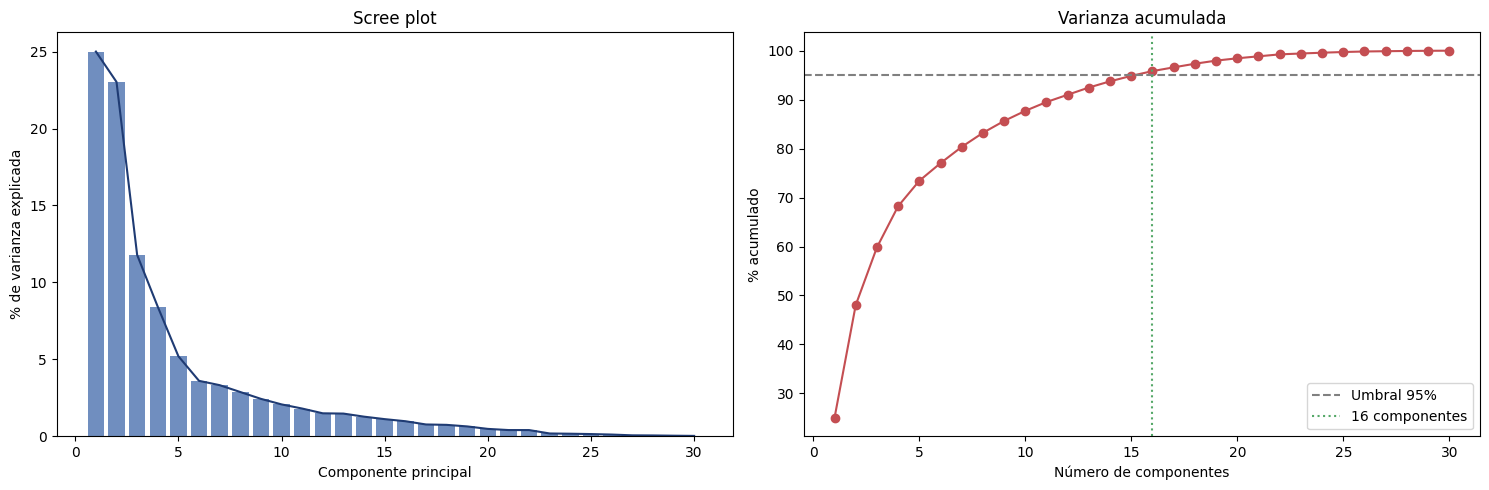

In [60]:
# Scree plot y varianza acumulada
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(component_numbers, explained_variance_ratio * 100, color="#4C72B0", alpha=0.8)
axes[0].plot(component_numbers, explained_variance_ratio * 100, color="#1F3B73", linewidth=1.5)
axes[0].set_title("Scree plot")
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("% de varianza explicada")

axes[1].plot(component_numbers, explained_variance_ratio_acum * 100, marker="o", color="#C44E52")
axes[1].axhline(umbral_varianza * 100, color="gray", linestyle="--", label=f"Umbral {umbral_varianza:.0%}")
axes[1].axvline(n_componentes_umbral, color="#55A868", linestyle=":", label=f"{n_componentes_umbral} componentes")
axes[1].set_title("Varianza acumulada")
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("% acumulado")
axes[1].legend()

plt.tight_layout()
plt.show()


#### Interpretación de la PCA

En esta parte se aplicó PCA sobre las variables numéricas del dataset previamente limpiado, imputado y estandarizado. El objetivo fue reducir la dimensionalidad del problema sin trabajar directamente con todas las variables originales, aprovechando combinaciones lineales que concentran la mayor parte de la variabilidad del conjunto de datos.

La selección del número de componentes se hizo con un umbral de **95% de varianza acumulada**. En consecuencia, se conservan las primeras componentes necesarias para superar ese porcentaje, lo que permite reducir varias dimensiones sin perder la mayor parte de la información estadística del dataset.

Elegimos PCA sabiendo que esta técnica reduce la explicabilidad directa, porque cada componente combina varias variables originales y deja de ser tan fácil interpretar el efecto individual de cada una. Sin embargo, si en una fase posterior se utiliza un modelo que tampoco sea intrínsecamente explicable, esta pérdida de interpretabilidad no representa un problema tan fuerte y la reducción de dimensionalidad puede ayudar a simplificar el análisis y el modelado.

Los resultados relevantes de esta sección son: la tabla `varianza_pca`, que muestra cuánta variabilidad explica cada componente; el scree plot y la curva de varianza acumulada, que permiten decidir cuántas componentes conservar; y el valor impreso en la celda de preparación, que indica el número mínimo de componentes necesarias para alcanzar el umbral seleccionado.


### Hallazgos preliminares

Esta subsección queda reservada para sintetizar los principales patrones observados durante la exploración descriptiva, incluyendo comportamientos atípicos, relaciones entre variables y diferencias relevantes entre municipios o regiones.


## Etapa 2: Reglas de asociación por nivel educativo

En esta etapa se transforma el conjunto de datos educativo en una base transaccional para aplicar reglas de asociación **por bloque temático**. La unidad de análisis sigue siendo cada registro `municipio-año`, pero las reglas ahora se construyen por separado para el nivel general, transición, primaria, secundaria y media.

El cambio busca evitar reglas poco útiles producidas por mezclar variables de distintos niveles o por comparar indicadores casi equivalentes. De esta manera, cada conjunto de reglas se interpreta dentro de su propio contexto educativo.


### Enfoque metodológico

Cada bloque incluye las variables de cobertura, permanencia y desempeño correspondientes a su nivel, además de `tasa_matriculacion_5_16` como variable transversal para todos los contextos. En transición se excluyen `aprobacion_transicion` y `reprobacion_transicion` porque ambas variables resultaron redundantes y, tras la discretización, no aportaron separación analítica útil. Las variables continuas se discretizan por **terciles** (`bajo`, `medio`, `alto`) para construir las transacciones.

Se ejecutan **Apriori** y **FP-Growth** con los mismos umbrales de soporte y confianza en todos los bloques para facilitar la comparación. La selección final prioriza reglas con consecuente único, antecedentes cortos y relaciones entre dimensiones distintas del problema educativo.


In [61]:
%pip install -q efficient-apriori pyfpgrowth


In [62]:
from collections import Counter
from itertools import combinations
from math import ceil
import time

from efficient_apriori import apriori
import pyfpgrowth


### Definición de bloques y validación inicial

El análisis se separa en cinco bloques para evitar que las reglas mezclen niveles educativos distintos. Antes de generar transacciones, se valida qué columnas están disponibles, cuáles conservan variación y si existen variables exactamente duplicadas que convenga excluir para reducir redundancia. En el bloque de transición, además, se retiran `aprobacion_transicion` y `reprobacion_transicion` para evitar reglas triviales producidas por una señal redundante y poco discriminante.


In [63]:
assert "df" in globals(), "Ejecuta primero la limpieza del dataset."

association_blocks = {
    "general": [
        "tasa_matriculacion_5_16",
        "cobertura_neta",
        "cobertura_bruta",
        "desercion",
        "aprobacion",
        "reprobacion",
        "repitencia",
    ],
    "transicion": [
        # Se excluyen aprobacion y reprobacion en transición por redundancia y baja discriminación.
        "tasa_matriculacion_5_16",
        "cobertura_neta_transicion",
        "cobertura_bruta_transicion",
        "desercion_transicion",
        "repitencia_transicion",
    ],
    "primaria": [
        "tasa_matriculacion_5_16",
        "cobertura_neta_primaria",
        "cobertura_bruta_primaria",
        "desercion_primaria",
        "aprobacion_primaria",
        "reprobacion_primaria",
        "repitencia_primaria",
    ],
    "secundaria": [
        "tasa_matriculacion_5_16",
        "cobertura_neta_secundaria",
        "cobertura_bruta_secundaria",
        "desercion_secundaria",
        "aprobacion_secundaria",
        "reprobacion_secundaria",
        "repitencia_secundaria",
    ],
    "media": [
        "tasa_matriculacion_5_16",
        "cobertura_neta_media",
        "cobertura_bruta_media",
        "desercion_media",
        "aprobacion_media",
        "reprobacion_media",
        "repitencia_media",
    ],
}

association_block_labels = {
    "general": "Indicadores agregados del municipio",
    "transicion": "Indicadores del nivel transición",
    "primaria": "Indicadores del nivel primaria",
    "secundaria": "Indicadores del nivel secundaria",
    "media": "Indicadores del nivel media",
}

block_summary_rows = []

for block_name, block_columns in association_blocks.items():
    available_columns = [col for col in block_columns if col in df.columns]
    numeric_block = df[available_columns].apply(pd.to_numeric, errors="coerce")

    varying_columns = [
        col for col in available_columns if numeric_block[col].nunique(dropna=True) > 1
    ]
    constant_columns = [col for col in available_columns if col not in varying_columns]

    deduplicated_columns = []
    duplicate_pairs = []

    for col in varying_columns:
        duplicate_of = next(
            (
                kept
                for kept in deduplicated_columns
                if numeric_block[col].equals(numeric_block[kept])
            ),
            None,
        )
        if duplicate_of is None:
            deduplicated_columns.append(col)
        else:
            duplicate_pairs.append(f"{col} -> {duplicate_of}")

    null_columns = [
        col for col in deduplicated_columns if numeric_block[col].isna().any()
    ]

    block_summary_rows.append(
        {
            "bloque": block_name,
            "descripcion": association_block_labels[block_name],
            "columnas_esperadas": len(block_columns),
            "columnas_usadas": len(deduplicated_columns),
            "columnas_constantes": ", ".join(constant_columns) if constant_columns else "-",
            "columnas_duplicadas": ", ".join(duplicate_pairs) if duplicate_pairs else "-",
            "columnas_con_nulos": ", ".join(null_columns) if null_columns else "-",
        }
    )

association_block_summary_df = pd.DataFrame(block_summary_rows)
association_block_summary_df


,bloque,descripcion,columnas_esperadas,columnas_usadas,columnas_constantes,columnas_duplicadas,columnas_con_nulos
0,general,Indicadores agregados del municipio,7,7,-,-,-
1,transicion,Indicadores del nivel transición,5,5,-,-,-
2,primaria,Indicadores del nivel primaria,7,7,-,-,-
3,secundaria,Indicadores del nivel secundaria,7,7,-,-,-
4,media,Indicadores del nivel media,7,7,-,-,-


In [64]:
level_suffixes = ("_transicion", "_primaria", "_secundaria", "_media")


def base_variable_name(variable):
    for suffix in level_suffixes:
        if variable.endswith(suffix):
            return variable[: -len(suffix)]
    return variable


def prepare_block_input(df, block_name, block_columns):
    available_columns = [col for col in block_columns if col in df.columns]
    if not available_columns:
        raise ValueError(f"El bloque '{block_name}' no tiene columnas disponibles.")

    block_df = df[available_columns].copy()
    block_df = block_df.apply(pd.to_numeric, errors="raise")

    varying_columns = [
        col for col in block_df.columns if block_df[col].nunique(dropna=True) > 1
    ]
    block_df = block_df[varying_columns].copy()

    deduplicated_columns = []
    duplicate_map = {}

    for col in block_df.columns:
        duplicate_of = next(
            (
                kept
                for kept in deduplicated_columns
                if block_df[col].equals(block_df[kept])
            ),
            None,
        )
        if duplicate_of is None:
            deduplicated_columns.append(col)
        else:
            duplicate_map[col] = duplicate_of

    block_df = block_df[deduplicated_columns].copy()

    null_columns = block_df.columns[block_df.isna().any()].tolist()
    if null_columns:
        raise ValueError(
            f"El bloque '{block_name}' tiene nulos después de la limpieza: {null_columns}"
        )

    if block_df.shape[1] < 2:
        raise ValueError(
            f"El bloque '{block_name}' necesita al menos dos variables con variación."
        )

    return block_df, duplicate_map


def discretize_by_terciles(series):
    numeric_series = pd.to_numeric(series, errors="raise")

    if numeric_series.nunique(dropna=True) <= 1:
        return None

    discretized = pd.qcut(numeric_series, q=3, duplicates="drop")
    n_bins = len(discretized.cat.categories)

    if n_bins == 1:
        labels = ["medio"]
    elif n_bins == 2:
        labels = ["bajo", "alto"]
    else:
        labels = ["bajo", "medio", "alto"]

    return discretized.cat.rename_categories(labels).astype("string")


def build_discretized_block(block_df):
    discretized_block = pd.DataFrame(index=block_df.index)
    discretization_rows = []

    for column in block_df.columns:
        binned_column = discretize_by_terciles(block_df[column])
        if binned_column is None:
            continue

        discretized_block[column] = binned_column
        counts = binned_column.value_counts(dropna=False).sort_index()

        for category, count in counts.items():
            discretization_rows.append(
                {
                    "variable": column,
                    "categoria": str(category),
                    "frecuencia": int(count),
                    "proporcion": round(count / len(binned_column), 4),
                }
            )

    if discretized_block.empty:
        raise ValueError("La discretización no produjo variables categóricas válidas.")

    if discretized_block.isna().any().any():
        raise ValueError("La discretización produjo nulos; revisa los cortes por cuantiles.")

    discretization_summary_df = pd.DataFrame(discretization_rows)
    return discretized_block, discretization_summary_df


def row_to_transaction(row):
    return tuple(sorted(f"{column}={value}" for column, value in row.items()))


def build_transactions(discretized_block):
    transactions = discretized_block.apply(row_to_transaction, axis=1).tolist()
    n_transactions = len(transactions)
    transaction_lengths = pd.Series([len(transaction) for transaction in transactions])

    item_frequency = Counter(item for transaction in transactions for item in transaction)
    item_support_df = (
        pd.DataFrame(
            [
                {
                    "item": item,
                    "support_count": count,
                    "support": round(count / n_transactions, 4),
                }
                for item, count in item_frequency.items()
            ]
        )
        .sort_values(["support_count", "item"], ascending=[False, True])
        .reset_index(drop=True)
    )

    transaction_summary = {
        "transacciones": n_transactions,
        "min_items_por_transaccion": int(transaction_lengths.min()),
        "max_items_por_transaccion": int(transaction_lengths.max()),
        "items_unicos": len(item_frequency),
    }

    return transactions, item_support_df, transaction_summary


In [65]:
ITEMSET_RESULT_COLUMNS = [
    "algoritmo",
    "itemset",
    "size",
    "support_count",
    "support",
]

RULE_RESULT_COLUMNS = [
    "algoritmo",
    "antecedente",
    "consecuente",
    "antecedente_items",
    "consecuente_items",
    "antecedent_size",
    "consequent_size",
    "rule_size",
    "support_count",
    "support",
    "antecedent_support",
    "consequent_support",
    "confidence",
    "lift",
    "leverage",
    "conviction",
]


def normalize_itemset(itemset):
    return tuple(sorted(itemset))


def itemset_label(itemset):
    return "{" + ", ".join(itemset) + "}"


def support_count(itemset, transactions):
    itemset = set(itemset)
    return sum(itemset.issubset(transaction) for transaction in transactions)


def flatten_apriori_itemsets(itemsets_by_size):
    support_lookup = {}
    for itemsets in itemsets_by_size.values():
        for itemset, count in itemsets.items():
            support_lookup[normalize_itemset(itemset)] = int(count)
    return support_lookup


def flatten_fpgrowth_patterns(patterns, min_support_count):
    return {
        normalize_itemset(itemset): int(count)
        for itemset, count in patterns.items()
        if count >= min_support_count
    }


def build_itemsets_df(support_lookup, algorithm, n_transactions):
    rows = []
    for itemset, count in sorted(
        support_lookup.items(),
        key=lambda pair: (len(pair[0]), pair[0]),
    ):
        rows.append(
            {
                "algoritmo": algorithm,
                "itemset": itemset_label(itemset),
                "size": len(itemset),
                "support_count": count,
                "support": round(count / n_transactions, 4),
            }
        )

    if not rows:
        return pd.DataFrame(columns=ITEMSET_RESULT_COLUMNS)

    return pd.DataFrame(rows, columns=ITEMSET_RESULT_COLUMNS)


def generate_rules_from_itemsets(
    support_lookup,
    algorithm,
    transactions,
    n_transactions,
    min_confidence,
):
    rows = []

    for itemset, union_count in sorted(
        support_lookup.items(),
        key=lambda pair: (len(pair[0]), pair[0]),
    ):
        if len(itemset) < 2:
            continue

        itemset_set = set(itemset)
        rule_support = union_count / n_transactions

        for antecedent_size in range(1, len(itemset)):
            for antecedent in combinations(itemset, antecedent_size):
                antecedent = normalize_itemset(antecedent)
                consequent = normalize_itemset(itemset_set - set(antecedent))

                antecedent_count = support_lookup.get(
                    antecedent,
                    support_count(antecedent, transactions),
                )
                consequent_count = support_lookup.get(
                    consequent,
                    support_count(consequent, transactions),
                )

                if antecedent_count == 0 or consequent_count == 0:
                    continue

                antecedent_support = antecedent_count / n_transactions
                consequent_support = consequent_count / n_transactions
                confidence = union_count / antecedent_count
                lift = confidence / consequent_support
                leverage = rule_support - (antecedent_support * consequent_support)
                conviction = (
                    np.inf
                    if confidence == 1
                    else (1 - consequent_support) / (1 - confidence)
                )

                if confidence >= min_confidence:
                    rows.append(
                        {
                            "algoritmo": algorithm,
                            "antecedente": itemset_label(antecedent),
                            "consecuente": itemset_label(consequent),
                            "antecedente_items": antecedent,
                            "consecuente_items": consequent,
                            "antecedent_size": len(antecedent),
                            "consequent_size": len(consequent),
                            "rule_size": len(antecedent) + len(consequent),
                            "support_count": union_count,
                            "support": round(rule_support, 4),
                            "antecedent_support": round(antecedent_support, 4),
                            "consequent_support": round(consequent_support, 4),
                            "confidence": round(confidence, 4),
                            "lift": round(lift, 4),
                            "leverage": round(leverage, 4),
                            "conviction": round(conviction, 4)
                            if np.isfinite(conviction)
                            else np.inf,
                        }
                    )

    if not rows:
        return pd.DataFrame(columns=RULE_RESULT_COLUMNS)

    return pd.DataFrame(rows, columns=RULE_RESULT_COLUMNS)


### Apriori y FP-Growth por bloque

Sobre cada bloque se aplican los dos algoritmos vistos en clase usando la misma base transaccional discretizada. Esto permite comparar el rendimiento computacional de ambos métodos y revisar si recuperan patrones consistentes en cada contexto educativo.


In [66]:
min_support = 0.10
min_confidence = 0.60
top_rules_per_block = 1000

print(f"Soporte mínimo relativo: {min_support:.2f}")
print(f"Confianza mínima: {min_confidence:.2f}")
print(f"Top de reglas mostrado por bloque: {top_rules_per_block}")
print("Los mismos umbrales se usarán en todos los bloques para facilitar la comparación.")


Soporte mínimo relativo: 0.10
Confianza mínima: 0.60
Top de reglas mostrado por bloque: 1000
Los mismos umbrales se usarán en todos los bloques para facilitar la comparación.


In [67]:
def item_variable(item):
    return item.split("=", 1)[0]


def variable_group(variable):
    base_variable = base_variable_name(variable)

    if base_variable.startswith("cobertura") or base_variable == "tasa_matriculacion_5_16":
        return "cobertura_matricula"
    if base_variable == "desercion":
        return "desercion"
    if base_variable == "aprobacion":
        return "aprobacion"
    if base_variable == "reprobacion":
        return "reprobacion"
    if base_variable == "repitencia":
        return "repitencia"
    return "otro"


def enrich_rules_for_selection(rules_df, block_name):
    rules_df = rules_df.copy()

    if rules_df.empty:
        rules_df["bloque"] = pd.Series(dtype="object")
        rules_df["antecedent_variables"] = pd.Series(dtype="object")
        rules_df["consequent_variables"] = pd.Series(dtype="object")
        rules_df["rule_groups"] = pd.Series(dtype="object")
        rules_df["n_rule_groups"] = pd.Series(dtype="int64")
        rules_df["cross_dimension"] = pd.Series(dtype="bool")
        return rules_df

    rules_df["bloque"] = block_name
    rules_df["antecedent_variables"] = rules_df["antecedente_items"].apply(
        lambda items: tuple(sorted({item_variable(item) for item in items}))
    )
    rules_df["consequent_variables"] = rules_df["consecuente_items"].apply(
        lambda items: tuple(sorted({item_variable(item) for item in items}))
    )
    rules_df["rule_groups"] = rules_df.apply(
        lambda row: tuple(
            sorted(
                {
                    variable_group(variable)
                    for variable in row["antecedent_variables"] + row["consequent_variables"]
                }
            )
        ),
        axis=1,
    )
    rules_df["n_rule_groups"] = rules_df["rule_groups"].apply(len)
    rules_df["cross_dimension"] = rules_df["n_rule_groups"] >= 2

    return rules_df


def select_interpretable_rules(rules_df, max_per_consequent=2, max_rules=10):
    if rules_df.empty:
        return rules_df.copy()

    base_filter = (
        (rules_df["support"] >= 0.15)
        & (rules_df["confidence"] >= 0.70)
        & (rules_df["lift"] >= 1.15)
        & (rules_df["consequent_size"] == 1)
        & (rules_df["antecedent_size"] <= 3)
    )

    candidates = rules_df[base_filter].copy()
    cross_dimension_candidates = candidates[candidates["cross_dimension"]].copy()

    if not cross_dimension_candidates.empty:
        candidates = cross_dimension_candidates

    if candidates.empty:
        return candidates

    candidates = candidates.sort_values(
        ["lift", "confidence", "support", "antecedent_size"],
        ascending=[False, False, False, True],
    )
    candidates["pair_key"] = candidates.apply(
        lambda row: frozenset([row["antecedente"], row["consecuente"]]),
        axis=1,
    )
    candidates = candidates.drop_duplicates("pair_key", keep="first")

    candidates = (
        candidates
        .groupby("consecuente", group_keys=False)
        .head(max_per_consequent)
        .sort_values(
            ["lift", "confidence", "support", "antecedent_size"],
            ascending=[False, False, False, True],
        )
        .head(max_rules)
        .drop(columns="pair_key")
        .reset_index(drop=True)
    )

    return candidates


def run_association_block(df, block_name, block_columns, min_support, min_confidence):
    block_input, duplicate_map = prepare_block_input(df, block_name, block_columns)
    discretized_block, discretization_summary_df = build_discretized_block(block_input)
    transactions, item_support_df, transaction_summary = build_transactions(discretized_block)

    n_transactions = len(transactions)
    min_support_count = ceil(min_support * n_transactions)

    apriori_start = time.perf_counter()
    apriori_itemsets_raw, _ = apriori(
        transactions,
        min_support=min_support,
        min_confidence=min_confidence,
    )
    apriori_elapsed = time.perf_counter() - apriori_start

    apriori_support_lookup = flatten_apriori_itemsets(apriori_itemsets_raw)
    apriori_itemsets_df = build_itemsets_df(
        apriori_support_lookup,
        "Apriori",
        n_transactions,
    )
    apriori_rules_df = generate_rules_from_itemsets(
        apriori_support_lookup,
        "Apriori",
        transactions,
        n_transactions,
        min_confidence,
    )

    fpgrowth_start = time.perf_counter()
    fpgrowth_patterns_raw = pyfpgrowth.find_frequent_patterns(
        transactions,
        min_support_count,
    )
    _ = pyfpgrowth.generate_association_rules(
        fpgrowth_patterns_raw,
        min_confidence,
    )
    fpgrowth_elapsed = time.perf_counter() - fpgrowth_start

    fpgrowth_support_lookup = flatten_fpgrowth_patterns(
        fpgrowth_patterns_raw,
        min_support_count,
    )
    fpgrowth_itemsets_df = build_itemsets_df(
        fpgrowth_support_lookup,
        "FP-Growth",
        n_transactions,
    )
    fpgrowth_rules_df = generate_rules_from_itemsets(
        fpgrowth_support_lookup,
        "FP-Growth",
        transactions,
        n_transactions,
        min_confidence,
    )

    performance_df = pd.DataFrame(
        [
            {
                "bloque": block_name,
                "algoritmo": "Apriori",
                "soporte_minimo_abs": min_support_count,
                "itemsets_frecuentes": len(apriori_itemsets_df),
                "reglas_fuertes": len(apriori_rules_df),
                "tiempo_segundos": round(apriori_elapsed, 4),
            },
            {
                "bloque": block_name,
                "algoritmo": "FP-Growth",
                "soporte_minimo_abs": min_support_count,
                "itemsets_frecuentes": len(fpgrowth_itemsets_df),
                "reglas_fuertes": len(fpgrowth_rules_df),
                "tiempo_segundos": round(fpgrowth_elapsed, 4),
            },
        ]
    )

    combined_itemsets_df = pd.concat(
        [apriori_itemsets_df, fpgrowth_itemsets_df],
        ignore_index=True,
    )
    combined_rules_df = pd.concat(
        [apriori_rules_df, fpgrowth_rules_df],
        ignore_index=True,
    )

    significant_rules_df = (
        enrich_rules_for_selection(combined_rules_df, block_name)
        .sort_values(
            ["lift", "confidence", "support", "antecedent_size"],
            ascending=[False, False, False, True],
        )
        .drop_duplicates(["antecedente", "consecuente"], keep="first")
        .reset_index(drop=True)
    )

    top_rules_by_lift_df = significant_rules_df.head(top_rules_per_block).copy()
    selected_interpretable_rules_df = select_interpretable_rules(significant_rules_df)

    return {
        "bloque": block_name,
        "association_columns": block_input.columns.tolist(),
        "duplicate_map": duplicate_map,
        "discretized_block": discretized_block,
        "discretization_summary_df": discretization_summary_df,
        "transactions": transactions,
        "item_support_df": item_support_df,
        "transaction_summary": transaction_summary,
        "min_support_count": min_support_count,
        "apriori_itemsets_df": apriori_itemsets_df,
        "apriori_rules_df": apriori_rules_df,
        "fpgrowth_itemsets_df": fpgrowth_itemsets_df,
        "fpgrowth_rules_df": fpgrowth_rules_df,
        "performance_df": performance_df,
        "combined_itemsets_df": combined_itemsets_df,
        "combined_rules_df": combined_rules_df,
        "significant_rules_df": significant_rules_df,
        "top_rules_by_lift_df": top_rules_by_lift_df,
        "selected_interpretable_rules_df": selected_interpretable_rules_df,
    }


In [68]:
association_results = {}
association_errors = {}
association_performance_frames = []
discretization_frames = []
top_rules_frames = []
selected_rules_frames = []
association_block_overview_rows = []

for block_name, block_columns in association_blocks.items():
    try:
        result = run_association_block(
            df=df,
            block_name=block_name,
            block_columns=block_columns,
            min_support=min_support,
            min_confidence=min_confidence,
        )
        association_results[block_name] = result

        association_performance_frames.append(result["performance_df"])
        discretization_frames.append(
            result["discretization_summary_df"].assign(bloque=block_name)
        )
        top_rules_frames.append(result["top_rules_by_lift_df"])

        if not result["selected_interpretable_rules_df"].empty:
            selected_rules_frames.append(result["selected_interpretable_rules_df"])

        association_block_overview_rows.append(
            {
                "bloque": block_name,
                "descripcion": association_block_labels[block_name],
                "columnas_usadas": len(result["association_columns"]),
                "transacciones": result["transaction_summary"]["transacciones"],
                "items_unicos": result["transaction_summary"]["items_unicos"],
                "reglas_top_lift": len(result["top_rules_by_lift_df"]),
                "reglas_interpretables": len(result["selected_interpretable_rules_df"]),
                "estado": "ok",
            }
        )
    except ValueError as exc:
        association_errors[block_name] = str(exc)
        association_block_overview_rows.append(
            {
                "bloque": block_name,
                "descripcion": association_block_labels[block_name],
                "columnas_usadas": 0,
                "transacciones": 0,
                "items_unicos": 0,
                "reglas_top_lift": 0,
                "reglas_interpretables": 0,
                "estado": str(exc),
            }
        )

association_block_overview_df = pd.DataFrame(association_block_overview_rows)
association_performance_all_blocks_df = (
    pd.concat(association_performance_frames, ignore_index=True)
    if association_performance_frames
    else pd.DataFrame()
)
discretization_summary_all_blocks_df = (
    pd.concat(discretization_frames, ignore_index=True)
    if discretization_frames
    else pd.DataFrame()
)
top_rules_by_lift_all_blocks_df = (
    pd.concat(top_rules_frames, ignore_index=True)
    if top_rules_frames
    else pd.DataFrame()
)
selected_interpretable_rules_all_blocks_df = (
    pd.concat(selected_rules_frames, ignore_index=True)
    if selected_rules_frames
    else pd.DataFrame()
)

association_block_overview_df


,bloque,descripcion,columnas_usadas,transacciones,items_unicos,reglas_top_lift,reglas_interpretables,estado
0,general,Indicadores agregados del municipio,7,15704,21,96,2,ok
1,transicion,Indicadores del nivel transición,5,15704,14,49,2,ok
2,primaria,Indicadores del nivel primaria,7,15704,21,68,2,ok
3,secundaria,Indicadores del nivel secundaria,7,15704,21,63,2,ok
4,media,Indicadores del nivel media,7,15704,21,32,2,ok


In [69]:
display(association_block_summary_df)
print()
display(association_block_overview_df)
print()
display(
    association_performance_all_blocks_df
    .sort_values(["bloque", "algoritmo"])
    .reset_index(drop=True)
)


,bloque,descripcion,columnas_esperadas,columnas_usadas,columnas_constantes,columnas_duplicadas,columnas_con_nulos
0,general,Indicadores agregados del municipio,7,7,-,-,-
1,transicion,Indicadores del nivel transición,5,5,-,-,-
2,primaria,Indicadores del nivel primaria,7,7,-,-,-
3,secundaria,Indicadores del nivel secundaria,7,7,-,-,-
4,media,Indicadores del nivel media,7,7,-,-,-


,bloque,descripcion,columnas_usadas,transacciones,items_unicos,reglas_top_lift,reglas_interpretables,estado
0,general,Indicadores agregados del municipio,7,15704,21,96,2,ok
1,transicion,Indicadores del nivel transición,5,15704,14,49,2,ok
2,primaria,Indicadores del nivel primaria,7,15704,21,68,2,ok
3,secundaria,Indicadores del nivel secundaria,7,15704,21,63,2,ok
4,media,Indicadores del nivel media,7,15704,21,32,2,ok


,bloque,algoritmo,soporte_minimo_abs,itemsets_frecuentes,reglas_fuertes,tiempo_segundos
0,general,Apriori,1571,195,96,0.3284
1,general,FP-Growth,1571,174,96,0.6787
2,media,Apriori,1571,163,32,0.3324
3,media,FP-Growth,1571,146,32,0.5453
4,primaria,Apriori,1571,175,68,0.2708
5,primaria,FP-Growth,1571,156,68,0.5326
6,secundaria,Apriori,1571,180,63,0.3058
7,secundaria,FP-Growth,1571,163,63,0.5464
8,transicion,Apriori,1571,83,49,0.1085
9,transicion,FP-Growth,1571,69,47,0.3556


### Proceso realizado para organizar las reglas

Después de construir los bloques y ejecutar los algoritmos, los resultados se organizaron por nivel educativo para facilitar su lectura. En cada caso se trabajó con la misma lógica: validación de variables, discretización por terciles, generación de transacciones y obtención de reglas con **Apriori** y **FP-Growth**.

Las tablas siguientes muestran, para cada nivel, el **top** de reglas ordenadas por `lift`, con desempate por `confidence` y `support`. Además, debajo de cada tabla se propone un pequeño grupo de reglas para resaltar en el informe, priorizando soporte suficiente, confianza alta, antecedente corto y, cuando sea posible, relaciones entre dimensiones distintas del problema educativo.


In [70]:
level_top_rule_columns = [
    "algoritmo",
    "regla",
    "support_count",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction",
    "cross_dimension",
]


def rule_text_from_items(items):
    return " y ".join(item.replace("=", " = ") for item in items)


def rule_text(row):
    antecedente = rule_text_from_items(row["antecedente_items"])
    consecuente = rule_text_from_items(row["consecuente_items"])
    return f"Si {antecedente}, entonces {consecuente}."


def build_readable_rule_table(rules_df):
    readable_rules = rules_df.copy()
    readable_rules["regla"] = readable_rules.apply(rule_text, axis=1)
    return readable_rules[
        [
            "algoritmo",
            "regla",
            "support_count",
            "support",
            "confidence",
            "lift",
            "leverage",
            "conviction",
            "cross_dimension",
            "antecedent_size",
            "consequent_size",
        ]
    ]


def select_rules_to_highlight(rules_df, max_rules=4):
    candidates = rules_df[
        (rules_df["consequent_size"] == 1)
        & (rules_df["antecedent_size"] <= 2)
        & (rules_df["support"] >= 0.15)
        & (rules_df["confidence"] >= 0.70)
    ].copy()

    cross_dimension_candidates = candidates[candidates["cross_dimension"]].copy()
    if not cross_dimension_candidates.empty:
        candidates = cross_dimension_candidates

    if candidates.empty:
        candidates = rules_df.copy()

    candidates["score_resaltado"] = (
        candidates["lift"] * candidates["confidence"] * candidates["support"]
    )

    return (
        candidates
        .sort_values(
            ["score_resaltado", "lift", "confidence", "support"],
            ascending=[False, False, False, False],
        )
        .drop_duplicates(["antecedente", "consecuente"])
        .head(max_rules)
        .reset_index(drop=True)
    )


def explain_highlight_rule(row):
    reasons = []
    if row["cross_dimension"]:
        reasons.append("conecta dimensiones distintas")
    if row["support"] >= 0.20:
        reasons.append("aparece en una proporción relevante de registros")
    if row["confidence"] >= 0.80:
        reasons.append("tiene confianza alta")
    if row["lift"] >= 1.50:
        reasons.append("su lift muestra una asociación claramente superior a la esperada")

    if not reasons:
        reasons.append("combina métricas sólidas y buena interpretabilidad")

    metrics = (
        f"support={row['support']:.4f}, confidence={row['confidence']:.4f}, "
        f"lift={row['lift']:.4f}"
    )
    return f"{metrics}. {'; '.join(reasons)}."


def display_top_rules_for_block(block_name):
    if block_name in association_errors:
        print(
            f"No se pudieron generar reglas para el bloque '{block_name}': "
            f"{association_errors[block_name]}"
        )
        return

    result = association_results[block_name]
    ranked_rules = (
        result["top_rules_by_lift_df"]
        .sort_values(["lift", "confidence", "support"], ascending=[False, False, False])
        .reset_index(drop=True)
    )

    if ranked_rules.empty:
        print(f"No se encontraron reglas fuertes para el bloque '{block_name}'.")
        return

    readable_rules = build_readable_rule_table(ranked_rules)

    print("Variables analizadas:")
    print(", ".join(result["association_columns"]))
    print()
    print(f"Top {len(readable_rules)} de reglas por lift:")

    with pd.option_context("display.max_colwidth", None, "display.width", 200):
        display(
            readable_rules[level_top_rule_columns]
            .style.format(
                {
                    "support": "{:.4f}",
                    "confidence": "{:.4f}",
                    "lift": "{:.4f}",
                    "leverage": "{:.4f}",
                    "conviction": "{:.4f}",
                }
            )
            .set_properties(
                subset=["regla"],
                **{"white-space": "normal", "text-align": "left"},
            )
        )

    return




### Reglas de asociación: nivel general

En este bloque se analizaron los indicadores agregados del municipio: `tasa_matriculacion_5_16`, `cobertura_neta`, `cobertura_bruta`, `desercion`, `aprobacion`, `reprobacion` y `repitencia`. La tabla siguiente presenta el top 15 de reglas encontradas para el nivel general, ordenadas por `lift`.


In [71]:
display_top_rules_for_block("general")


Variables analizadas:
tasa_matriculacion_5_16, cobertura_neta, cobertura_bruta, desercion, aprobacion, reprobacion, repitencia

Top 96 de reglas por lift:


,algoritmo,regla,support_count,support,confidence,lift,leverage,conviction,cross_dimension
0,Apriori,"Si desercion = bajo y reprobacion = bajo, entonces aprobacion = alto.",2254,0.1435,0.9982,3.0002,0.0957,376.6808,True
1,Apriori,"Si desercion = alto y reprobacion = alto, entonces aprobacion = bajo.",2136,0.1360,0.9991,2.9941,0.0906,712.3036,True
2,Apriori,"Si repitencia = alto y tasa_matriculacion_5_16 = bajo, entonces cobertura_neta = bajo.",1654,0.1053,0.9627,2.8853,0.0688,17.8867,True
3,Apriori,"Si cobertura_neta = medio y repitencia = alto, entonces tasa_matriculacion_5_16 = medio.",1640,0.1044,0.9585,2.8759,0.0681,16.0668,True
4,Apriori,"Si reprobacion = alto y tasa_matriculacion_5_16 = alto, entonces cobertura_neta = alto.",1759,0.1120,0.9462,2.8384,0.0725,12.3929,True
5,Apriori,"Si aprobacion = bajo y tasa_matriculacion_5_16 = alto, entonces cobertura_neta = alto.",1775,0.1130,0.9457,2.8368,0.0732,12.2676,True
6,Apriori,"Si cobertura_bruta = alto y cobertura_neta = alto, entonces tasa_matriculacion_5_16 = alto.",4083,0.2600,0.9430,2.8287,0.1681,11.6865,False
7,Apriori,"Si tasa_matriculacion_5_16 = alto, entonces cobertura_bruta = alto y cobertura_neta = alto.",4083,0.2600,0.7799,2.8287,0.1681,3.2913,False
8,Apriori,"Si desercion = medio y reprobacion = medio, entonces aprobacion = medio.",1725,0.1098,0.9411,2.8209,0.0709,11.3101,True
9,Apriori,"Si aprobacion = bajo y cobertura_neta = alto, entonces tasa_matriculacion_5_16 = alto.",1775,0.1130,0.9367,2.8098,0.0728,10.5274,True


### Reglas de asociación: transición

En el nivel de transición se analizaron `tasa_matriculacion_5_16`, `cobertura_neta_transicion`, `cobertura_bruta_transicion`, `desercion_transicion` y `repitencia_transicion`. En este bloque se excluyeron `aprobacion_transicion` y `reprobacion_transicion` porque ambas variables presentaban la misma señal y, después de discretizarlas, tendían a producir reglas triviales concentradas en la categoría `medio`. La siguiente tabla resume el top 15 de reglas encontradas en este contexto.


In [72]:
display_top_rules_for_block("transicion")


Variables analizadas:
tasa_matriculacion_5_16, cobertura_neta_transicion, cobertura_bruta_transicion, desercion_transicion, repitencia_transicion

Top 49 de reglas por lift:


,algoritmo,regla,support_count,support,confidence,lift,leverage,conviction,cross_dimension
0,Apriori,"Si cobertura_neta_transicion = bajo y repitencia_transicion = bajo y tasa_matriculacion_5_16 = bajo, entonces cobertura_bruta_transicion = bajo.",1881,0.1198,0.8500,2.5488,0.0728,4.4428,True
1,Apriori,"Si cobertura_neta_transicion = bajo y tasa_matriculacion_5_16 = bajo, entonces cobertura_bruta_transicion = bajo.",2667,0.1698,0.8129,2.4375,0.1002,3.5616,False
2,Apriori,"Si cobertura_neta_transicion = alto y tasa_matriculacion_5_16 = alto, entonces cobertura_bruta_transicion = alto.",2355,0.1500,0.7694,2.3079,0.0850,2.8904,False
3,Apriori,"Si cobertura_bruta_transicion = bajo y cobertura_neta_transicion = bajo, entonces tasa_matriculacion_5_16 = bajo.",2667,0.1698,0.7596,2.2787,0.0953,2.7732,False
4,Apriori,"Si cobertura_bruta_transicion = bajo y cobertura_neta_transicion = bajo y repitencia_transicion = bajo, entonces tasa_matriculacion_5_16 = bajo.",1881,0.1198,0.7585,2.2753,0.0671,2.7601,True
5,Apriori,"Si cobertura_bruta_transicion = bajo y tasa_matriculacion_5_16 = bajo, entonces cobertura_neta_transicion = bajo.",2667,0.1698,0.7521,2.2523,0.0944,2.6870,False
6,Apriori,"Si cobertura_bruta_transicion = alto y cobertura_neta_transicion = alto, entonces tasa_matriculacion_5_16 = alto.",2355,0.1500,0.7399,2.2195,0.0824,2.5627,False
7,Apriori,"Si cobertura_bruta_transicion = bajo y repitencia_transicion = bajo y tasa_matriculacion_5_16 = bajo, entonces cobertura_neta_transicion = bajo.",1881,0.1198,0.7411,2.2194,0.0658,2.5730,True
8,Apriori,"Si repitencia_transicion = bajo y tasa_matriculacion_5_16 = bajo, entonces cobertura_bruta_transicion = bajo.",2538,0.1616,0.7101,2.1294,0.0857,2.2994,True
9,Apriori,"Si cobertura_neta_transicion = bajo y repitencia_transicion = bajo, entonces cobertura_bruta_transicion = bajo.",2480,0.1579,0.7047,2.1133,0.0832,2.2574,True


### Reglas de asociación: primaria

Para primaria se trabajó con `tasa_matriculacion_5_16`, `cobertura_neta_primaria`, `cobertura_bruta_primaria`, `desercion_primaria`, `aprobacion_primaria`, `reprobacion_primaria` y `repitencia_primaria`. A continuación se muestra el top 15 de reglas encontradas para este nivel.


In [73]:
display_top_rules_for_block("primaria")


Variables analizadas:
tasa_matriculacion_5_16, cobertura_neta_primaria, cobertura_bruta_primaria, desercion_primaria, aprobacion_primaria, reprobacion_primaria, repitencia_primaria

Top 68 de reglas por lift:


,algoritmo,regla,support_count,support,confidence,lift,leverage,conviction,cross_dimension
0,Apriori,"Si desercion_primaria = bajo y reprobacion_primaria = bajo, entonces aprobacion_primaria = alto.",2272,0.1447,0.9974,2.9976,0.0964,253.3448,True
1,Apriori,"Si desercion_primaria = alto y reprobacion_primaria = alto, entonces aprobacion_primaria = bajo.",2217,0.1412,1.0000,2.9975,0.0941,inf,True
2,Apriori,"Si desercion_primaria = medio y reprobacion_primaria = bajo, entonces aprobacion_primaria = alto.",1584,0.1009,0.9688,2.9118,0.0662,21.3923,True
3,Apriori,"Si desercion_primaria = medio y reprobacion_primaria = medio, entonces aprobacion_primaria = medio.",1692,0.1077,0.9201,2.7574,0.0687,8.3359,True
4,Apriori,"Si aprobacion_primaria = alto y desercion_primaria = medio, entonces reprobacion_primaria = bajo.",1584,0.1009,0.9183,2.7541,0.0642,8.1550,True
5,Apriori,"Si cobertura_bruta_primaria = bajo y tasa_matriculacion_5_16 = bajo, entonces cobertura_neta_primaria = bajo.",3416,0.2175,0.9025,2.7053,0.1371,6.8355,False
6,Apriori,"Si cobertura_neta_primaria = bajo, entonces cobertura_bruta_primaria = bajo y tasa_matriculacion_5_16 = bajo.",3416,0.2175,0.6520,2.7053,0.1371,2.1812,False
7,Apriori,"Si cobertura_bruta_primaria = alto y reprobacion_primaria = alto, entonces aprobacion_primaria = bajo.",1594,0.1015,0.8668,2.5982,0.0624,5.0020,True
8,Apriori,"Si cobertura_bruta_primaria = alto y tasa_matriculacion_5_16 = alto, entonces cobertura_neta_primaria = alto.",3088,0.1966,0.8647,2.5946,0.1208,4.9292,False
9,Apriori,"Si cobertura_bruta_primaria = bajo y reprobacion_primaria = bajo, entonces aprobacion_primaria = alto.",1575,0.1003,0.8597,2.5839,0.0615,4.7567,True


### Reglas de asociación: secundaria

En secundaria se incluyeron `tasa_matriculacion_5_16`, `cobertura_neta_secundaria`, `cobertura_bruta_secundaria`, `desercion_secundaria`, `aprobacion_secundaria`, `reprobacion_secundaria` y `repitencia_secundaria`. La tabla siguiente expone el top 15 de reglas encontradas en este nivel educativo.


In [74]:
display_top_rules_for_block("secundaria")


Variables analizadas:
tasa_matriculacion_5_16, cobertura_neta_secundaria, cobertura_bruta_secundaria, desercion_secundaria, aprobacion_secundaria, reprobacion_secundaria, repitencia_secundaria

Top 63 de reglas por lift:


,algoritmo,regla,support_count,support,confidence,lift,leverage,conviction,cross_dimension
0,Apriori,"Si desercion_secundaria = alto y reprobacion_secundaria = alto, entonces aprobacion_secundaria = bajo.",2039,0.1298,0.9995,2.9966,0.0865,1359.5670,True
1,Apriori,"Si desercion_secundaria = bajo y reprobacion_secundaria = bajo, entonces aprobacion_secundaria = alto.",2195,0.1398,0.9914,2.9792,0.0929,77.7485,True
2,Apriori,"Si desercion_secundaria = medio y reprobacion_secundaria = bajo, entonces aprobacion_secundaria = alto.",1628,0.1037,0.9831,2.9542,0.0686,39.4612,True
3,Apriori,"Si aprobacion_secundaria = alto y desercion_secundaria = medio, entonces reprobacion_secundaria = bajo.",1628,0.1037,0.9187,2.7539,0.0660,8.2003,True
4,Apriori,"Si desercion_secundaria = medio y reprobacion_secundaria = medio, entonces aprobacion_secundaria = medio.",1636,0.1042,0.9069,2.7179,0.0658,7.1551,True
5,Apriori,"Si cobertura_neta_secundaria = bajo y tasa_matriculacion_5_16 = bajo, entonces cobertura_bruta_secundaria = bajo.",3290,0.2095,0.8906,2.6702,0.1310,6.0938,False
6,Apriori,"Si cobertura_bruta_secundaria = bajo, entonces cobertura_neta_secundaria = bajo y tasa_matriculacion_5_16 = bajo.",3290,0.2095,0.6281,2.6702,0.1310,2.0564,False
7,Apriori,"Si aprobacion_secundaria = bajo y cobertura_neta_secundaria = alto, entonces reprobacion_secundaria = alto.",1670,0.1063,0.8845,2.6575,0.0663,5.7779,True
8,Apriori,"Si cobertura_neta_secundaria = alto y tasa_matriculacion_5_16 = alto, entonces cobertura_bruta_secundaria = alto.",3155,0.2009,0.8752,2.6284,0.1245,5.3436,False
9,Apriori,"Si cobertura_bruta_secundaria = alto, entonces cobertura_neta_secundaria = alto y tasa_matriculacion_5_16 = alto.",3155,0.2009,0.6034,2.6284,0.1245,1.9424,False


### Reglas de asociación: media

Para el nivel media se analizaron `tasa_matriculacion_5_16`, `cobertura_neta_media`, `cobertura_bruta_media`, `desercion_media`, `aprobacion_media`, `reprobacion_media` y `repitencia_media`. La siguiente tabla presenta el top 15 de reglas encontradas en este bloque.


In [75]:
display_top_rules_for_block("media")


Variables analizadas:
tasa_matriculacion_5_16, cobertura_neta_media, cobertura_bruta_media, desercion_media, aprobacion_media, reprobacion_media, repitencia_media

Top 32 de reglas por lift:


,algoritmo,regla,support_count,support,confidence,lift,leverage,conviction,cross_dimension
0,Apriori,"Si desercion_media = alto y reprobacion_media = alto, entonces aprobacion_media = bajo.",1937,0.1233,0.9928,2.9624,0.0817,92.6533,True
1,Apriori,"Si desercion_media = bajo y reprobacion_media = bajo, entonces aprobacion_media = alto.",2063,0.1314,0.9843,2.9537,0.0869,42.3502,True
2,Apriori,"Si cobertura_neta_media = bajo y tasa_matriculacion_5_16 = bajo, entonces cobertura_bruta_media = bajo.",2615,0.1665,0.8752,2.6253,0.1031,5.3403,False
3,Apriori,"Si cobertura_neta_media = alto y tasa_matriculacion_5_16 = alto, entonces cobertura_bruta_media = alto.",2433,0.1549,0.8699,2.6094,0.0956,5.1225,False
4,Apriori,"Si aprobacion_media = bajo y repitencia_media = alto, entonces reprobacion_media = alto.",1954,0.1244,0.8238,2.4712,0.0741,3.7830,True
5,Apriori,"Si cobertura_bruta_media = bajo y desercion_media = alto, entonces cobertura_neta_media = bajo.",1770,0.1127,0.8236,2.4708,0.0671,3.7800,True
6,Apriori,"Si repitencia_media = alto y reprobacion_media = alto, entonces aprobacion_media = bajo.",1954,0.1244,0.8245,2.4601,0.0738,3.7878,True
7,Apriori,"Si cobertura_neta_media = bajo y reprobacion_media = bajo, entonces cobertura_bruta_media = bajo.",1695,0.1079,0.8045,2.4132,0.0632,3.4093,True
8,Apriori,"Si cobertura_bruta_media = bajo y repitencia_media = bajo, entonces cobertura_neta_media = bajo.",1745,0.1111,0.8038,2.4112,0.0650,3.3974,True
9,Apriori,"Si cobertura_bruta_media = bajo y tasa_matriculacion_5_16 = bajo, entonces cobertura_neta_media = bajo.",2615,0.1665,0.8019,2.4056,0.0973,3.3652,False


## Etapa 3: Agrupación de municipios

En esta etapa se busca aplicar técnicas de agrupación para identificar conjuntos de municipios con comportamientos educativos similares. A diferencia de las reglas de asociación, aquí no se parte de una variable objetivo, sino que se intenta descubrir estructuras o perfiles dentro de los datos a partir de los indicadores seleccionados.

Antes de aplicar los algoritmos, es importante considerar que algunos métodos de agrupación son sensibles a la forma en que se inicializan o a los parámetros definidos por el usuario.

### Sensibilidad de los algoritmos de agrupación

**K-Means** es sensible a la inicialización. Esto ocurre porque el algoritmo comienza seleccionando centroides iniciales y luego ajusta los grupos de forma iterativa. Si los centroides iniciales cambian, el resultado final puede cambiar, especialmente cuando los grupos no están claramente separados. Por esta razón, es recomendable usar varias inicializaciones (`n_init`) y fijar una semilla (`random_state`) para que los resultados sean reproducibles.

**DBSCAN** no es sensible a la inicialización aleatoria en el mismo sentido que K-Means. DBSCAN no inicia con centroides ni optimiza una función desde puntos iniciales aleatorios. Su resultado depende principalmente de los parámetros `eps` y `min_samples`, además de la escala de las variables y la métrica de distancia utilizada. Por tanto, DBSCAN es más sensible a la selección de parámetros y al preprocesamiento que a la inicialización. En algunas implementaciones puede haber pequeñas diferencias en puntos frontera si cambia el orden de los datos, pero no es un algoritmo basado en inicialización aleatoria.

**Gaussian Mixture Model (GMM)** sí es sensible a la inicialización. Este modelo ajusta una mezcla de distribuciones gaussianas mediante el algoritmo EM (Expectation-Maximization), que puede converger a óptimos locales. Dependiendo de los parámetros iniciales de las medias, covarianzas y pesos de las componentes, el resultado puede variar. Por eso, al igual que en K-Means, conviene usar varias inicializaciones (`n_init`) y fijar `random_state` para mejorar estabilidad y reproducibilidad.

En resumen, K-Means y GMM son sensibles a la inicialización, mientras que DBSCAN no depende de una inicialización aleatoria, pero sí es muy sensible a la escala de los datos y a la elección de sus parámetros.



### Evaluación de K-Means con 100 corridas por K

Para evaluar la sensibilidad de K-Means a la inicialización, se prueban valores de `K` entre 2 y 10. Para cada valor se ejecutan 100 inicializaciones independientes con `n_init=1` y una semilla diferente por corrida.

La matriz de entrada usa las variables numéricas seleccionadas en `columnas_analisis`, convertidas a `float64` y estandarizadas con media 0 y desviación estándar 1. No se aplica PCA en esta primera evaluación, de modo que las métricas se calculan sobre las variables originales estandarizadas.

Las métricas calculadas por corrida son:

- `ssw`: suma de cuadrados intra-cluster, equivalente a `inertia_`.
- `ssb`: suma de cuadrados entre clusters, calculada como `sst - ssw`.
- `silhouette`: coeficiente de silueta sobre el dataset completo.
- `davies_bouldin`: índice Davies-Bouldin sobre el dataset completo.


In [76]:
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score

# Preparación de datos para K-Means
kmeans_input = df[columnas_analisis].copy()
kmeans_input = kmeans_input.apply(pd.to_numeric, errors="raise").astype("float64")

if kmeans_input.isna().any().any():
    raise ValueError("La matriz de entrada para K-Means contiene valores nulos.")

columnas_constantes_kmeans = [
    col for col in kmeans_input.columns if kmeans_input[col].nunique(dropna=False) <= 1
]
if columnas_constantes_kmeans:
    print(
        "Se excluyen columnas constantes de K-Means:",
        ", ".join(columnas_constantes_kmeans),
    )
    kmeans_input = kmeans_input.drop(columns=columnas_constantes_kmeans)

medias_kmeans = kmeans_input.mean()
desv_kmeans = kmeans_input.std(ddof=0).replace(0, 1)
X_kmeans = ((kmeans_input - medias_kmeans) / desv_kmeans).to_numpy(dtype="float64")

if X_kmeans.shape[0] <= 10:
    raise ValueError("K-Means requiere más observaciones que el valor máximo de K evaluado.")

sst_kmeans = float(np.square(X_kmeans - X_kmeans.mean(axis=0)).sum())

print(f"Matriz K-Means: {X_kmeans.shape[0]} filas x {X_kmeans.shape[1]} variables")
print(f"SST total: {sst_kmeans:,.4f}")

pd.DataFrame(
    {
        "variable": kmeans_input.columns,
        "media_original": medias_kmeans,
        "desviacion_original": desv_kmeans,
    }
).reset_index(drop=True)


Matriz K-Means: 15704 filas x 30 variables
SST total: 471,120.0000


,variable,media_original,desviacion_original
0,poblacion_5_16,8730.102522,44599.009969
1,tasa_matriculacion_5_16,0.846606,0.183544
2,cobertura_neta,0.852002,0.168101
3,cobertura_neta_transicion,0.575545,0.160759
4,cobertura_neta_primaria,0.822561,0.170435
5,cobertura_neta_secundaria,0.697328,0.187522
6,cobertura_neta_media,0.408711,0.156890
7,cobertura_bruta,0.970184,0.211216
8,cobertura_bruta_transicion,0.868131,0.253130
9,cobertura_bruta_primaria,1.043395,0.250256


In [77]:
# Evaluación de K-Means con 100 inicializaciones independientes por K
k_values = range(2, 11)
n_corridas_kmeans = 10
semilla_base_kmeans = 20260505

kmeans_records = []

for k in k_values:
    print(f"Evaluando K={k}...")
    for corrida in range(1, n_corridas_kmeans + 1):
        random_state = semilla_base_kmeans + (k * 10_000) + corrida
        model = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=1,
            random_state=random_state,
            max_iter=300,
        )
        labels = model.fit_predict(X_kmeans)

        ssw = float(model.inertia_)
        ssb = float(sst_kmeans - ssw)
        silhouette = float(silhouette_score(X_kmeans, labels))
        davies_bouldin = float(davies_bouldin_score(X_kmeans, labels))

        kmeans_records.append(
            {
                "k": k,
                "corrida": corrida,
                "random_state": random_state,
                "ssw": ssw,
                "ssb": ssb,
                "silhouette": silhouette,
                "davies_bouldin": davies_bouldin,
            }
        )

    print(f"K={k} completado")

kmeans_runs_df = pd.DataFrame(kmeans_records)
kmeans_runs_df.head()


Evaluando K=2...
K=2 completado
Evaluando K=3...
K=3 completado
Evaluando K=4...
K=4 completado
Evaluando K=5...
K=5 completado
Evaluando K=6...
K=6 completado
Evaluando K=7...
K=7 completado
Evaluando K=8...
K=8 completado
Evaluando K=9...
K=9 completado
Evaluando K=10...
K=10 completado


,k,corrida,random_state,ssw,ssb,silhouette,davies_bouldin
0,2,1,20280506,400308.899972,70811.100028,0.171478,2.135456
1,2,2,20280507,400308.899972,70811.100028,0.171478,2.135456
2,2,3,20280508,400308.899972,70811.100028,0.171478,2.135456
3,2,4,20280509,400306.909295,70813.090705,0.171418,2.135319
4,2,5,20280510,400298.687904,70821.312096,0.171190,2.135235


In [78]:
# Resumen de métricas por K
metricas_kmeans = ["ssw", "ssb", "silhouette", "davies_bouldin"]

kmeans_summary_df = (
    kmeans_runs_df.groupby("k")[metricas_kmeans]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)
kmeans_summary_df.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in kmeans_summary_df.columns
]

expected_rows = len(list(k_values)) * n_corridas_kmeans
assert len(kmeans_runs_df) == expected_rows, (
    f"Se esperaban {expected_rows} corridas y se obtuvieron {len(kmeans_runs_df)}."
)
assert len(kmeans_summary_df) == len(list(k_values)), (
    f"Se esperaba una fila por cada K evaluado: {len(list(k_values))}."
)
assert not kmeans_runs_df[metricas_kmeans].isna().any().any(), (
    "Hay valores nulos en las métricas por corrida."
)
assert not kmeans_summary_df.isna().any().any(), (
    "Hay valores nulos en el resumen de métricas."
)

kmeans_summary_df


,k,ssw_mean,ssw_std,ssw_min,ssw_max,ssb_mean,ssb_std,ssb_min,ssb_max,silhouette_mean,silhouette_std,silhouette_min,silhouette_max,davies_bouldin_mean,davies_bouldin_std,davies_bouldin_min,davies_bouldin_max
0,2,400305.849450,3.915131,400298.560206,400308.899972,70814.150550,3.915131,70811.100028,70821.439794,0.171394,0.000102,0.171190,0.171478,2.135334,0.000102,2.135140,2.135456
1,3,354124.653097,7.372386,354117.372979,354133.212615,116995.346903,7.372386,116986.787385,117002.627021,0.133535,0.000365,0.133148,0.133930,1.836601,0.002187,1.834172,1.838836
2,4,332537.227697,461.927516,331976.702478,332907.335544,138582.772303,461.927516,138212.664456,139143.297522,0.128575,0.006928,0.118276,0.134308,1.959749,0.010502,1.945682,1.977403
3,5,313432.722941,739.571710,313175.570279,315536.585849,157687.277059,739.571710,155583.414151,157944.429721,0.123610,0.000622,0.121898,0.124002,1.961553,0.012119,1.927969,1.970242
4,6,299796.638024,1121.288768,299084.633019,301882.469823,171323.361976,1121.288768,169237.530177,172035.366981,0.118117,0.004542,0.112919,0.124651,1.836917,0.084223,1.677159,1.890419
5,7,288410.975685,1121.550039,287788.351614,291576.673270,182709.024315,1121.550039,179543.326730,183331.648386,0.116001,0.001134,0.113602,0.117497,1.790119,0.083703,1.637932,1.841360
6,8,279976.697391,1278.805784,276845.523183,281233.447577,191143.302609,1278.805784,189886.552423,194274.476817,0.106917,0.008730,0.095384,0.118239,1.853318,0.098991,1.651852,1.946554
7,9,271969.169582,1693.744677,268923.735923,273472.583046,199150.830418,1693.744677,197647.416954,202196.264077,0.102443,0.008324,0.091827,0.115597,1.811508,0.111594,1.626141,1.922640
8,10,265235.112644,2881.606873,261713.384893,268474.028734,205884.887356,2881.606873,202645.971266,209406.615107,0.102049,0.006143,0.092551,0.109566,1.814413,0.081849,1.699174,1.977436


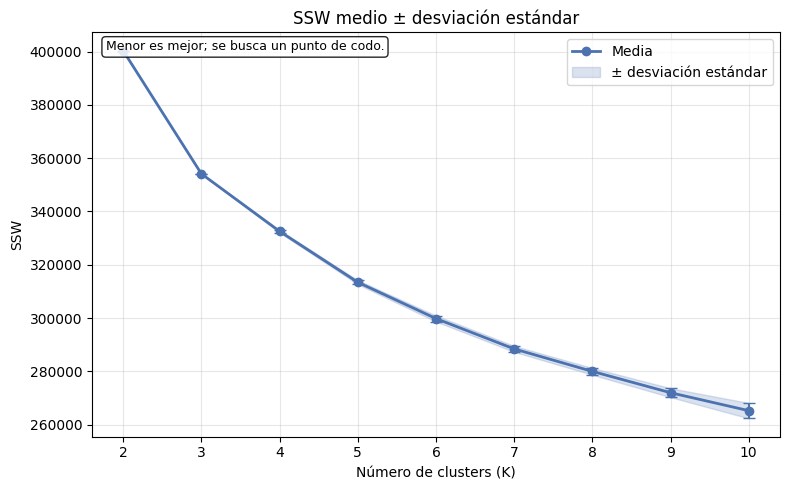

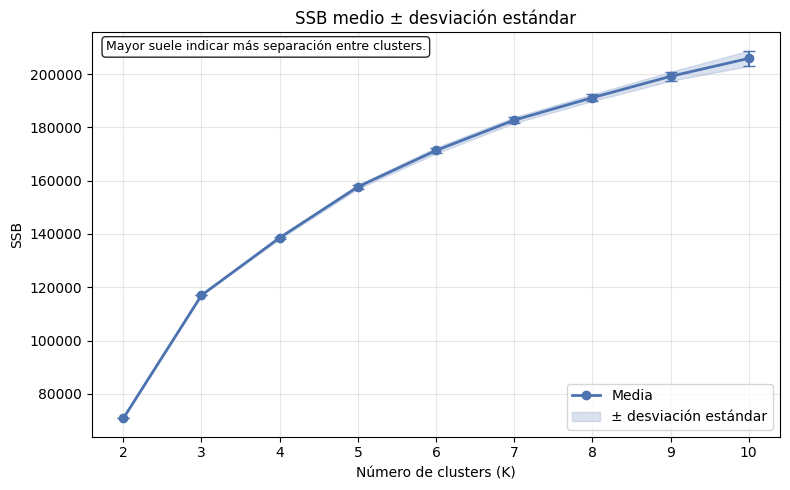

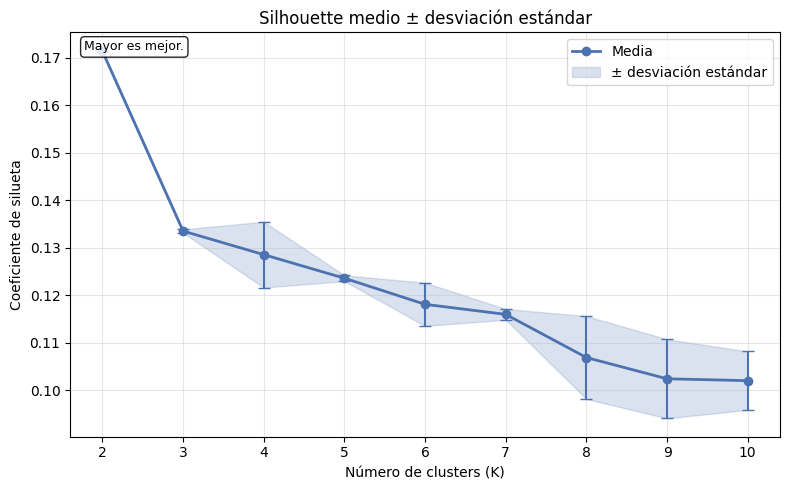

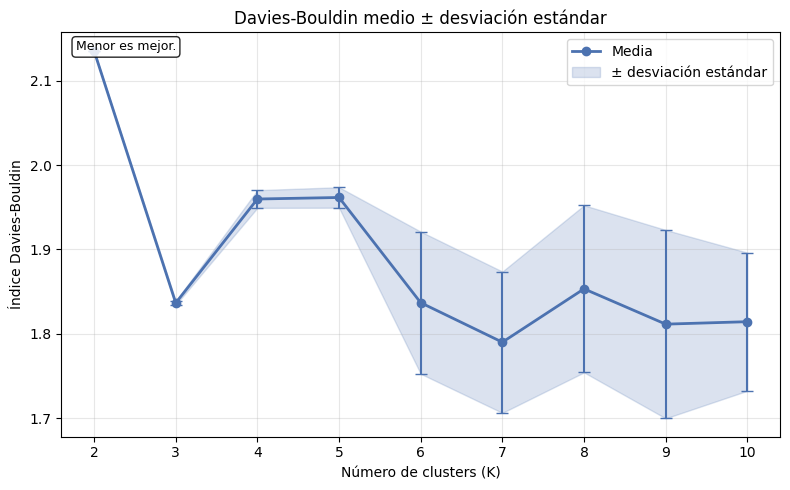

In [79]:
# Visualización de media ± desviación estándar por métrica
metric_plot_config = {
    "ssw": {
        "title": "SSW medio ± desviación estándar",
        "ylabel": "SSW",
        "note": "Menor es mejor; se busca un punto de codo.",
    },
    "ssb": {
        "title": "SSB medio ± desviación estándar",
        "ylabel": "SSB",
        "note": "Mayor suele indicar más separación entre clusters.",
    },
    "silhouette": {
        "title": "Silhouette medio ± desviación estándar",
        "ylabel": "Coeficiente de silueta",
        "note": "Mayor es mejor.",
    },
    "davies_bouldin": {
        "title": "Davies-Bouldin medio ± desviación estándar",
        "ylabel": "Índice Davies-Bouldin",
        "note": "Menor es mejor.",
    },
}

for metric, config in metric_plot_config.items():
    x = kmeans_summary_df["k"].to_numpy()
    mean = kmeans_summary_df[f"{metric}_mean"].to_numpy()
    std = kmeans_summary_df[f"{metric}_std"].to_numpy()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x, mean, marker="o", linewidth=2, color="#4C72B0", label="Media")
    ax.fill_between(
        x,
        mean - std,
        mean + std,
        color="#4C72B0",
        alpha=0.20,
        label="± desviación estándar",
    )
    ax.errorbar(x, mean, yerr=std, fmt="none", color="#4C72B0", capsize=4)
    ax.set_title(config["title"])
    ax.set_xlabel("Número de clusters (K)")
    ax.set_ylabel(config["ylabel"])
    ax.set_xticks(x)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.text(
        0.02,
        0.98,
        config["note"],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )
    plt.tight_layout()
    plt.show()


#### Interpretación de la evaluación de K-Means

La selección de `K` no debe depender de una sola métrica. Un buen valor debe balancear la cohesión interna de los clusters, la separación entre grupos, la estabilidad frente a inicializaciones diferentes y el sentido interpretativo de los perfiles resultantes.

En esta evaluación, `SSW` permite revisar el punto de codo, `SSB` ayuda a observar separación global, `silhouette` favorece soluciones con grupos compactos y bien separados, y `Davies-Bouldin` penaliza clusters poco compactos o muy cercanos entre sí. Si el cálculo de silueta completa resulta demasiado costoso, una alternativa razonable es mantener las 100 corridas para `SSW`, `SSB` y `Davies-Bouldin`, y calcular la silueta sobre una muestra fija y reproducible.


### Selección final de `K = 6`

Con base en la evaluación anterior, se fija `K = 6` para el modelo final de K-Means. Esta elección busca un equilibrio entre la reducción de `SSW`, la mejora de `Davies-Bouldin`, una caída controlada de `silhouette` y la posibilidad de interpretar seis perfiles diferenciados de municipios.


In [80]:
# Modelo final de K-Means con K = 6
k_final = 5
semilla_final_kmeans = semilla_base_kmeans + (k_final * 100_000)
n_init_final_kmeans = 50

resumen_k_final = kmeans_summary_df.loc[kmeans_summary_df["k"] == k_final].reset_index(drop=True)
assert not resumen_k_final.empty, "No se encontró el resumen para K=6."

kmeans_final = KMeans(
    n_clusters=k_final,
    init="k-means++",
    n_init=n_init_final_kmeans,
    random_state=semilla_final_kmeans,
    max_iter=300,
)
kmeans_labels = kmeans_final.fit_predict(X_kmeans)
centroides_kmeans = kmeans_final.cluster_centers_

ssw_kmeans_final = float(kmeans_final.inertia_)
ssb_kmeans_final = float(sst_kmeans - ssw_kmeans_final)
silhouette_kmeans_final = float(silhouette_score(X_kmeans, kmeans_labels))
davies_bouldin_kmeans_final = float(davies_bouldin_score(X_kmeans, kmeans_labels))

kmeans_final_metrics_df = pd.DataFrame(
    [
        {
            "k": k_final,
            "n_init_modelo_final": n_init_final_kmeans,
            "random_state": semilla_final_kmeans,
            "ssw_final": ssw_kmeans_final,
            "ssw_promedio_100_corridas": resumen_k_final.at[0, "ssw_mean"],
            "ssb_final": ssb_kmeans_final,
            "ssb_promedio_100_corridas": resumen_k_final.at[0, "ssb_mean"],
            "silhouette_final": silhouette_kmeans_final,
            "silhouette_promedio_100_corridas": resumen_k_final.at[0, "silhouette_mean"],
            "davies_bouldin_final": davies_bouldin_kmeans_final,
            "davies_bouldin_promedio_100_corridas": resumen_k_final.at[0, "davies_bouldin_mean"],
        }
    ]
)

kmeans_final_metrics_df


,k,n_init_modelo_final,random_state,ssw_final,ssw_promedio_100_corridas,ssb_final,ssb_promedio_100_corridas,silhouette_final,silhouette_promedio_100_corridas,davies_bouldin_final,davies_bouldin_promedio_100_corridas
0,5,50,20760505,313173.498095,313432.722941,157946.501905,157687.277059,0.123859,0.12361,1.965797,1.961553


### Perfil y composición de los clusters

A continuación se caracteriza la solución final con `K = 6` a partir de tres elementos: tamaño y composición de cada cluster, variables que más lo distinguen respecto al promedio global y ejemplos concretos de municipios cercanos a cada centroide.


In [81]:
# Estructura base para perfilar los clusters
cluster_index = pd.Index(np.arange(1, k_final + 1), name="cluster")

kmeans_cluster_df = df[["anio", "codigo_departamento", "codigo_municipio", "municipio", "departamento"]].copy()
kmeans_cluster_df["cluster"] = kmeans_labels + 1
kmeans_cluster_df["distancia_centroide"] = np.linalg.norm(
    X_kmeans - centroides_kmeans[kmeans_labels],
    axis=1,
)

zscore_cluster_df = pd.DataFrame(
    X_kmeans,
    columns=kmeans_input.columns,
    index=df.index,
).assign(cluster=kmeans_labels + 1)

cluster_profile_z_df = zscore_cluster_df.groupby("cluster").mean().reindex(cluster_index)
cluster_profile_original_df = (
    kmeans_input.assign(cluster=kmeans_labels + 1)
    .groupby("cluster")
    .mean()
    .reindex(cluster_index)
)

top_departamentos_cluster_df = (
    kmeans_cluster_df.groupby(["cluster", "departamento"])
    .size()
    .reset_index(name="frecuencia")
    .sort_values(["cluster", "frecuencia", "departamento"], ascending=[True, False, True])
    .groupby("cluster", group_keys=False)
    .head(3)
)

departamentos_predominantes_df = (
    top_departamentos_cluster_df.groupby("cluster")
    .apply(
        lambda group: ", ".join(
            f"{row.departamento} ({row.frecuencia})"
            for row in group.itertuples(index=False)
        )
    )
    .rename("departamentos_predominantes")
    .reset_index()
)

cluster_size_summary_df = (
    kmeans_cluster_df.groupby("cluster")
    .agg(
        observaciones=("cluster", "size"),
        municipios_unicos=("codigo_municipio", "nunique"),
        departamentos_unicos=("departamento", "nunique"),
        anios_cubiertos=("anio", "nunique"),
        distancia_promedio_centroide=("distancia_centroide", "mean"),
    )
    .reindex(cluster_index)
    .reset_index()
)

cluster_size_summary_df["porcentaje_observaciones"] = (
    cluster_size_summary_df["observaciones"] / len(kmeans_cluster_df)
)
cluster_size_summary_df = cluster_size_summary_df.merge(
    departamentos_predominantes_df,
    on="cluster",
    how="left",
)

display(
    cluster_size_summary_df.style.format(
        {
            "porcentaje_observaciones": "{:.2%}",
            "distancia_promedio_centroide": "{:.4f}",
        }
    )
)


/tmp/ipykernel_33914/2819516934.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,cluster,observaciones,municipios_unicos,departamentos_unicos,anios_cubiertos,distancia_promedio_centroide,porcentaje_observaciones,departamentos_predominantes
0,1,2754,597,32,14,4.2145,17.54%,"Boyacá (359), Antioquia (342), Santander (277)"
1,2,2516,727,32,14,4.5374,16.02%,"Antioquia (336), Tolima (205), Valle del Cauca (187)"
2,3,2774,895,34,14,4.5100,17.66%,"Antioquia (420), Boyacá (264), Cundinamarca (203)"
3,4,2406,499,32,14,4.0272,15.32%,"Nariño (303), Boyacá (275), Cundinamarca (214)"
4,5,5254,983,33,14,3.3157,33.46%,"Cundinamarca (900), Boyacá (726), Antioquia (480)"


,poblacion_5_16,tasa_matriculacion_5_16,cobertura_neta,cobertura_bruta,desercion,aprobacion,reprobacion,repitencia
cluster,,,,,,,,
1,"12,691",106.11%,105.64%,122.75%,3.35%,90.75%,5.85%,2.84%
2,"6,677",82.77%,83.11%,95.10%,6.15%,86.17%,7.13%,2.42%
3,"9,448",82.39%,82.41%,92.23%,3.74%,87.86%,8.39%,8.97%
4,"4,282",61.28%,63.34%,69.76%,2.91%,93.95%,3.12%,2.74%
5,"9,294",86.23%,86.97%,99.46%,2.45%,95.44%,2.12%,2.34%


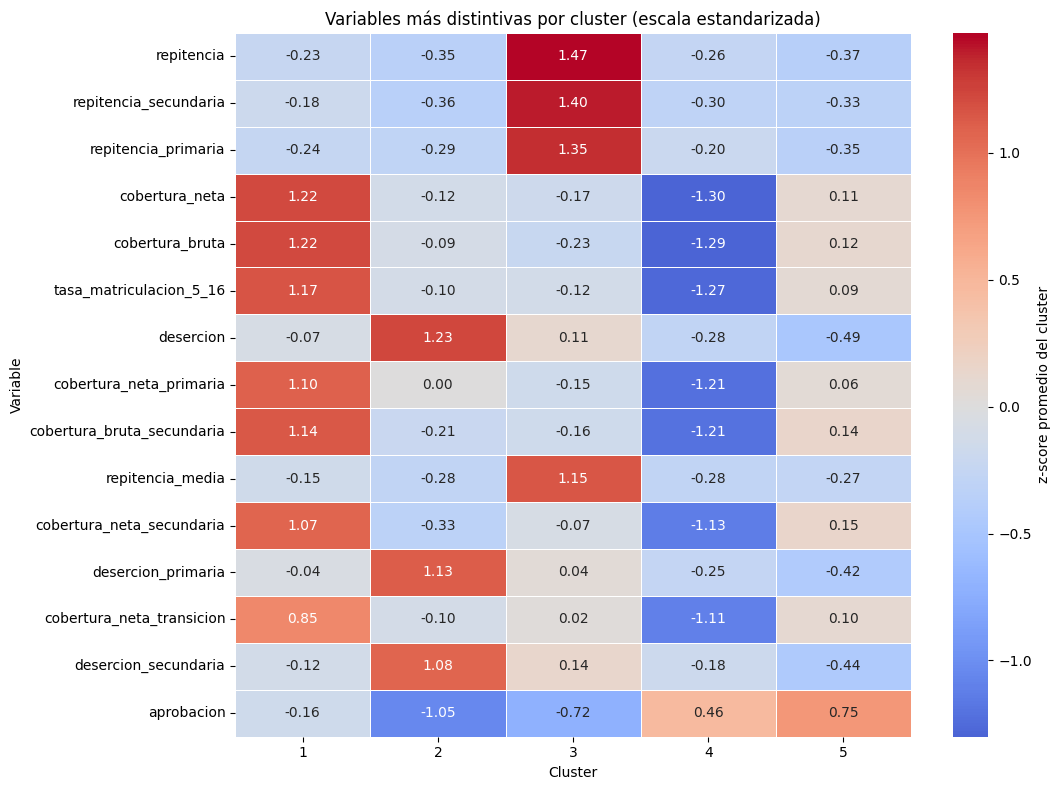

In [82]:
# Perfil estadístico de los clusters en escala original y estandarizada
variables_resumen_principal = [
    "poblacion_5_16",
    "tasa_matriculacion_5_16",
    "cobertura_neta",
    "cobertura_bruta",
    "desercion",
    "aprobacion",
    "reprobacion",
    "repitencia",
]

cluster_profile_principal_df = cluster_profile_original_df[variables_resumen_principal].copy()
display(
    cluster_profile_principal_df.style.format(
        {
            "poblacion_5_16": "{:,.0f}",
            "tasa_matriculacion_5_16": "{:.2%}",
            "cobertura_neta": "{:.2%}",
            "cobertura_bruta": "{:.2%}",
            "desercion": "{:.2%}",
            "aprobacion": "{:.2%}",
            "reprobacion": "{:.2%}",
            "repitencia": "{:.2%}",
        }
    )
)

variables_educativas_cluster = [
    col for col in cluster_profile_z_df.columns if col != "poblacion_5_16"
]
variables_heatmap = (
    cluster_profile_z_df[variables_educativas_cluster]
    .abs()
    .max(axis=0)
    .sort_values(ascending=False)
    .head(15)
    .index.tolist()
)

plt.figure(figsize=(11, 8))
sns.heatmap(
    cluster_profile_z_df.loc[:, variables_heatmap].T,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "z-score promedio del cluster"},
)
plt.title("Variables más distintivas por cluster (escala estandarizada)")
plt.xlabel("Cluster")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


In [83]:
# Resumen interpretativo y ejemplos representativos por cluster
variables_cobertura = ["tasa_matriculacion_5_16", "cobertura_neta", "cobertura_bruta"]
variables_riesgo = ["desercion", "reprobacion", "repitencia"]
variables_logro = ["aprobacion"]


def formatear_variable_cluster(variable):
    return variable.replace("_", " ")


def clasificar_nivel(score, bajo=-0.35, alto=0.35):
    if score >= alto:
        return "alto"
    if score <= bajo:
        return "bajo"
    return "intermedio"


def describir_rasgo(variable, z_score):
    direccion = "alta" if z_score >= 0 else "baja"
    return f"{formatear_variable_cluster(variable)} {direccion} (z={z_score:.2f})"


cluster_examples_df = (
    kmeans_cluster_df.sort_values(
        ["cluster", "distancia_centroide", "departamento", "municipio", "anio"]
    )
    .groupby("cluster", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

cluster_examples_reference_df = (
    cluster_examples_df.groupby("cluster", as_index=False).first()[
        ["cluster", "municipio", "departamento", "anio"]
    ]
)
departamentos_cluster_map = cluster_size_summary_df.set_index("cluster")[
    "departamentos_predominantes"
].to_dict()

cluster_interpretation_rows = []
for cluster_id in cluster_index:
    z_row = cluster_profile_z_df.loc[cluster_id]
    z_row_educativo = z_row.drop(labels=["poblacion_5_16"], errors="ignore")
    top_traits = z_row_educativo.reindex(
        z_row_educativo.abs().sort_values(ascending=False).head(4).index
    )

    coverage_score = z_row[variables_cobertura].mean()
    risk_score = z_row[variables_riesgo].mean()
    approval_score = z_row[variables_logro].mean()

    coverage_label = clasificar_nivel(coverage_score)
    if approval_score >= 0.35 and risk_score <= -0.35:
        performance_label = "desempeño favorable"
    elif approval_score <= -0.35 and risk_score >= 0.35:
        performance_label = "rezago académico"
    elif risk_score >= 0.35:
        performance_label = "riesgo de permanencia alto"
    else:
        performance_label = "desempeño intermedio"

    ejemplo_cluster = cluster_examples_reference_df.loc[
        cluster_examples_reference_df["cluster"] == cluster_id
    ].iloc[0]

    cobertura_texto = {
        "alto": "alta",
        "bajo": "baja",
        "intermedio": "intermedia",
    }[coverage_label]

    cluster_interpretation_rows.append(
        {
            "cluster": cluster_id,
            "perfil_general": f"Cobertura {cobertura_texto} con {performance_label}",
            "rasgos_distintivos": "; ".join(
                describir_rasgo(variable, value) for variable, value in top_traits.items()
            ),
            "departamentos_predominantes": departamentos_cluster_map.get(cluster_id, "-"),
            "ejemplo_representativo": (
                f"{ejemplo_cluster['municipio']} ({ejemplo_cluster['departamento']}, {int(ejemplo_cluster['anio'])})"
            ),
        }
    )

cluster_interpretation_df = pd.DataFrame(cluster_interpretation_rows)
display(cluster_interpretation_df)

display(
    cluster_examples_df[["cluster", "municipio", "departamento", "anio", "distancia_centroide"]]
    .copy()
    .style.format({"distancia_centroide": "{:.4f}"})
)

for row in cluster_interpretation_df.itertuples(index=False):
    print(
        f"Cluster {row.cluster}: {row.perfil_general}. "
        f"Rasgos distintivos: {row.rasgos_distintivos}. "
        f"Departamentos predominantes: {row.departamentos_predominantes}. "
        f"Ejemplo representativo: {row.ejemplo_representativo}."
    )


,cluster,perfil_general,rasgos_distintivos,departamentos_predominantes,ejemplo_representativo
0,1,Cobertura alta con desempeño intermedio,cobertura bruta alta (z=1.22); cobertura neta ...,"Boyacá (359), Antioquia (342), Santander (277)","Turbaco (Bolívar, 2015)"
1,2,Cobertura intermedia con rezago académico,desercion alta (z=1.23); desercion primaria al...,"Antioquia (336), Tolima (205), Valle del Cauca...","Campoalegre (Huila, 2013)"
2,3,Cobertura intermedia con rezago académico,repitencia alta (z=1.47); repitencia secundari...,"Antioquia (420), Boyacá (264), Cundinamarca (203)","Facatativá (Cundinamarca, 2023)"
3,4,Cobertura baja con desempeño intermedio,cobertura neta baja (z=-1.30); cobertura bruta...,"Nariño (303), Boyacá (275), Cundinamarca (214)","Tello (Huila, 2017)"
4,5,Cobertura intermedia con desempeño favorable,aprobacion alta (z=0.75); aprobacion secundari...,"Cundinamarca (900), Boyacá (726), Antioquia (480)","Caparrapí (Cundinamarca, 2021)"


,cluster,municipio,departamento,anio,distancia_centroide
0,1,Turbaco,Bolívar,2015,1.2363
1,1,Natagaima,Tolima,2019,1.3294
2,1,Líbano,Tolima,2019,1.4527
3,1,Copacabana,Antioquia,2018,1.5563
4,1,Copacabana,Antioquia,2012,1.5658
5,2,Campoalegre,Huila,2013,1.4935
6,2,Flandes,Tolima,2012,1.6938
7,2,Planadas,Tolima,2015,1.7842
8,2,Roncesvalles,Tolima,2018,1.8312
9,2,Caucasia,Antioquia,2016,1.8410


Cluster 1: Cobertura alta con desempeño intermedio. Rasgos distintivos: cobertura bruta alta (z=1.22); cobertura neta alta (z=1.22); tasa matriculacion 5 16 alta (z=1.17); cobertura bruta secundaria alta (z=1.14). Departamentos predominantes: Boyacá (359), Antioquia (342), Santander (277). Ejemplo representativo: Turbaco (Bolívar, 2015).
Cluster 2: Cobertura intermedia con rezago académico. Rasgos distintivos: desercion alta (z=1.23); desercion primaria alta (z=1.13); desercion secundaria alta (z=1.08); aprobacion baja (z=-1.05). Departamentos predominantes: Antioquia (336), Tolima (205), Valle del Cauca (187). Ejemplo representativo: Campoalegre (Huila, 2013).
Cluster 3: Cobertura intermedia con rezago académico. Rasgos distintivos: repitencia alta (z=1.47); repitencia secundaria alta (z=1.40); repitencia primaria alta (z=1.35); repitencia media alta (z=1.15). Departamentos predominantes: Antioquia (420), Boyacá (264), Cundinamarca (203). Ejemplo representativo: Facatativá (Cundinamar

### Distribución espacial comparativa de los clusters por departamento

Para comparar cómo cambia la lectura territorial del clustering al variar el número de grupos, en esta sección se mapean las soluciones con `K = 4`, `K = 5` y `K = 6`. En cada caso no se usa un modelo nuevo arbitrario, sino la **mejor corrida ya generada** para ese valor de `K` dentro de `kmeans_runs_df`.

La selección del mejor modelo por cada `K` se hace priorizando la menor `SSW` (inercia), y en caso de empate se favorece la mayor `silhouette` y el menor `Davies-Bouldin`. Luego, a partir de las asignaciones `municipio-año` de esa corrida, cada departamento se resume con su **cluster dominante** y con el porcentaje que representa dicho cluster dentro del total del departamento.


In [84]:
# Selección de los mejores modelos por K y agregación departamental comparativa
import unicodedata

k_values_mapa = [4, 5, 6]
palette_base_clusters = [
    "#1b9e77",
    "#d95f02",
    "#7570b3",
    "#e7298a",
    "#66a61e",
    "#e6ab02",
]


def normalizar_texto_mapa(texto):
    texto = str(texto).strip().upper()
    texto = unicodedata.normalize("NFKD", texto)
    return "".join(char for char in texto if not unicodedata.combining(char))


def resumir_departamentos_por_cluster(cluster_df):
    department_cluster_counts_df = (
        cluster_df.groupby(["codigo_departamento", "departamento", "cluster"])
        .size()
        .reset_index(name="observaciones_cluster")
    )

    department_totals_df = (
        department_cluster_counts_df.groupby(
            ["codigo_departamento", "departamento"], as_index=False
        )
        .agg(
            observaciones_departamento=("observaciones_cluster", "sum"),
            n_clusters_presentes=("cluster", "nunique"),
        )
    )

    department_cluster_summary_df = (
        department_cluster_counts_df.sort_values(
            ["codigo_departamento", "observaciones_cluster", "cluster"],
            ascending=[True, False, True],
        )
        .groupby(["codigo_departamento", "departamento"], as_index=False)
        .first()
        .rename(
            columns={
                "cluster": "cluster_dominante",
                "observaciones_cluster": "observaciones_cluster_dominante",
            }
        )
        .merge(
            department_totals_df,
            on=["codigo_departamento", "departamento"],
            how="left",
        )
    )

    department_cluster_summary_df["porcentaje_dominante"] = (
        department_cluster_summary_df["observaciones_cluster_dominante"]
        / department_cluster_summary_df["observaciones_departamento"]
    )
    department_cluster_summary_df["departamento_normalizado"] = (
        department_cluster_summary_df["departamento"].map(normalizar_texto_mapa)
    )

    department_cluster_mix_df = (
        department_cluster_counts_df.assign(
            etiqueta=lambda frame: (
                "C" + frame["cluster"].astype(int).astype(str)
                + ": "
                + frame["observaciones_cluster"].astype(int).astype(str)
            )
        )
        .sort_values(
            ["codigo_departamento", "observaciones_cluster", "cluster"],
            ascending=[True, False, True],
        )
        .groupby(["codigo_departamento", "departamento"])["etiqueta"]
        .agg(", ".join)
        .reset_index(name="composicion_clusters")
    )

    return (
        department_cluster_summary_df.merge(
            department_cluster_mix_df,
            on=["codigo_departamento", "departamento"],
            how="left",
        )
        .sort_values(
            ["cluster_dominante", "porcentaje_dominante", "departamento"],
            ascending=[True, False, True],
        )
        .reset_index(drop=True)
    )


kmeans_best_runs_map_df = (
    kmeans_runs_df.loc[kmeans_runs_df["k"].isin(k_values_mapa)]
    .sort_values(
        ["k", "ssw", "silhouette", "davies_bouldin", "corrida"],
        ascending=[True, True, False, True, True],
    )
    .groupby("k", as_index=False)
    .first()
    .rename(columns={"corrida": "mejor_corrida"})
)

kmeans_best_runs_map_df["criterio_seleccion"] = (
    "Menor SSW; en empate, mayor silhouette y menor Davies-Bouldin"
)

display(
    kmeans_best_runs_map_df[
        [
            "k",
            "mejor_corrida",
            "random_state",
            "ssw",
            "ssb",
            "silhouette",
            "davies_bouldin",
            "criterio_seleccion",
        ]
    ].style.format(
        {
            "ssw": "{:,.2f}",
            "ssb": "{:,.2f}",
            "silhouette": "{:.4f}",
            "davies_bouldin": "{:.4f}",
        }
    )
)

best_kmeans_models_by_k = {}
cluster_assignments_by_k = {}
department_cluster_summary_by_k = {}
cluster_color_map_by_k = {}

for row in kmeans_best_runs_map_df.itertuples(index=False):
    k_objetivo = int(row.k)
    random_state_objetivo = int(row.random_state)

    best_model = KMeans(
        n_clusters=k_objetivo,
        init="k-means++",
        n_init=1,
        random_state=random_state_objetivo,
        max_iter=300,
    )
    labels = best_model.fit_predict(X_kmeans)

    best_kmeans_models_by_k[k_objetivo] = best_model
    cluster_color_map_by_k[k_objetivo] = {
        cluster_id: palette_base_clusters[cluster_id - 1]
        for cluster_id in range(1, k_objetivo + 1)
    }

    cluster_df = df[
        [
            "anio",
            "codigo_departamento",
            "codigo_municipio",
            "municipio",
            "departamento",
        ]
    ].copy()
    cluster_df["codigo_departamento"] = (
        cluster_df["codigo_departamento"].astype(str).str.zfill(2)
    )
    cluster_df["cluster"] = labels + 1
    cluster_df["distancia_centroide"] = np.linalg.norm(
        X_kmeans - best_model.cluster_centers_[labels],
        axis=1,
    )

    cluster_assignments_by_k[k_objetivo] = cluster_df
    department_cluster_summary_by_k[k_objetivo] = resumir_departamentos_por_cluster(cluster_df)

# Se conserva K=5 como referencia operativa para cualquier inspección adicional.
department_cluster_summary_df = department_cluster_summary_by_k[5].copy()


,k,mejor_corrida,random_state,ssw,ssb,silhouette,davies_bouldin,criterio_seleccion
0,4,6,20300511,"331,976.70","139,143.30",0.1215,1.9704,"Menor SSW; en empate, mayor silhouette y menor Davies-Bouldin"
1,5,7,20310512,"313,175.57","157,944.43",0.1240,1.9657,"Menor SSW; en empate, mayor silhouette y menor Davies-Bouldin"
2,6,5,20320510,"299,084.63","172,035.37",0.1136,1.8684,"Menor SSW; en empate, mayor silhouette y menor Davies-Bouldin"


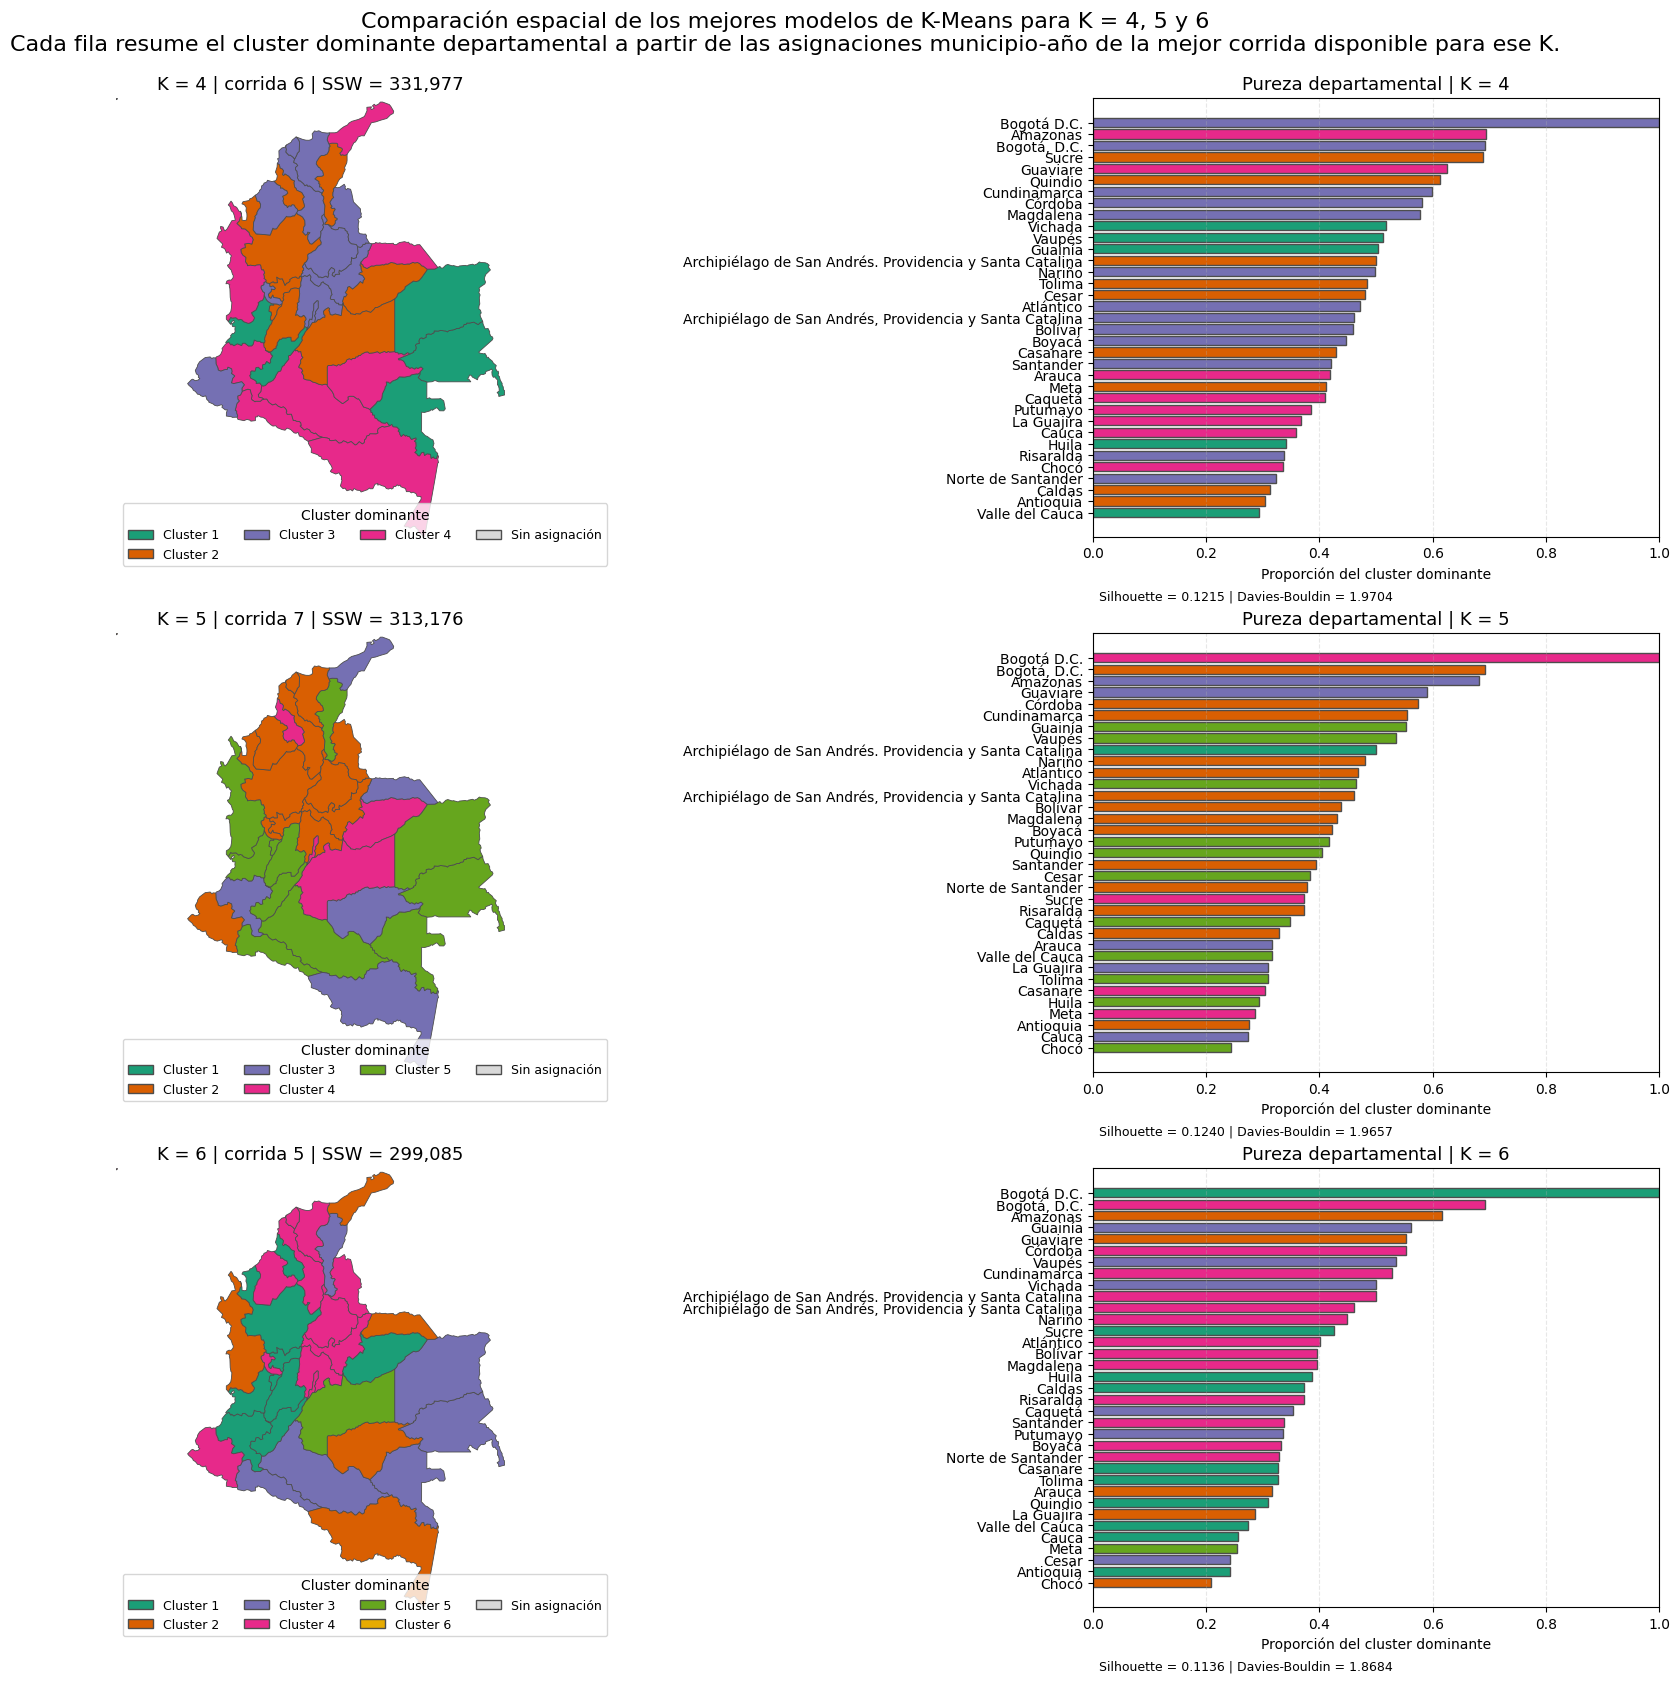

In [85]:
# Mapas departamentales para K = 4, 5 y 6 usando la mejor corrida de cada K
import json
from urllib.error import URLError
from urllib.request import urlopen

from matplotlib.collections import PatchCollection
from matplotlib.patches import Patch, Polygon

geojson_departamentos_url = (
    "https://raw.githubusercontent.com/caticoa3/colombia_mapa/master/"
    "co_2018_MGN_DPTO_POLITICO.geojson"
)


def obtener_propiedad_geojson(propiedades, candidatos):
    claves = {clave.upper(): clave for clave in propiedades}
    for candidato in candidatos:
        if candidato in propiedades:
            return propiedades[candidato]
        if candidato.upper() in claves:
            return propiedades[claves[candidato.upper()]]
    return None


def extraer_poligonos_geojson(geometria):
    if not geometria:
        return []

    tipo = geometria.get("type")
    coordenadas = geometria.get("coordinates", [])
    if tipo == "Polygon":
        grupos = [coordenadas]
    elif tipo == "MultiPolygon":
        grupos = coordenadas
    else:
        return []

    poligonos = []
    for grupo in grupos:
        if not grupo:
            continue
        anillo_exterior = grupo[0]
        poligonos.append(np.asarray(anillo_exterior))
    return poligonos


try:
    with urlopen(geojson_departamentos_url) as respuesta:
        colombia_departamentos_geojson = json.load(respuesta)
except URLError as exc:
    raise RuntimeError(
        "No fue posible descargar la cartografía departamental. "
        "Verifica la conexión del notebook o descarga el GeoJSON de forma local."
    ) from exc


fig, axes = plt.subplots(
    len(k_values_mapa),
    2,
    figsize=(18, 5.6 * len(k_values_mapa)),
    gridspec_kw={"width_ratios": [1.45, 1]},
)

if len(k_values_mapa) == 1:
    axes = np.array([axes])

unmatched_by_k = {}

for row_idx, k_objetivo in enumerate(k_values_mapa):
    ax_mapa, ax_barras = axes[row_idx]
    resumen_departamentos_df = department_cluster_summary_by_k[k_objetivo]
    color_map = cluster_color_map_by_k[k_objetivo]
    metric_row = kmeans_best_runs_map_df.loc[
        kmeans_best_runs_map_df["k"] == k_objetivo
    ].iloc[0]

    department_summary_by_code = {
        row.codigo_departamento: row
        for row in resumen_departamentos_df.itertuples(index=False)
    }
    department_summary_by_name = {
        row.departamento_normalizado: row
        for row in resumen_departamentos_df.itertuples(index=False)
    }

    patches = []
    facecolors = []
    bounds_x = []
    bounds_y = []
    departamentos_sin_asignacion = []

    for feature in colombia_departamentos_geojson.get("features", []):
        propiedades = feature.get("properties", {})
        codigo_geo = obtener_propiedad_geojson(
            propiedades,
            ["DPTO_CCDGO", "CODIGO_DPT", "COD_DEPTO", "DPTO", "DPT_CODE"],
        )
        nombre_geo = obtener_propiedad_geojson(
            propiedades,
            ["DPTO_CNMBR", "NOMBRE_DPT", "NOM_DPTO", "NOMBRE", "DEPARTAMENTO"],
        )

        fila_departamento = None
        if codigo_geo is not None:
            codigo_geo = str(codigo_geo).split(".")[0].zfill(2)
            fila_departamento = department_summary_by_code.get(codigo_geo)
        if fila_departamento is None and nombre_geo is not None:
            fila_departamento = department_summary_by_name.get(
                normalizar_texto_mapa(nombre_geo)
            )

        if fila_departamento is None:
            departamentos_sin_asignacion.append(nombre_geo or codigo_geo or "sin_nombre")
            color = "#d9d9d9"
        else:
            color = color_map[int(fila_departamento.cluster_dominante)]

        for poligono in extraer_poligonos_geojson(feature.get("geometry")):
            if len(poligono) == 0:
                continue
            patches.append(Polygon(poligono, closed=True))
            facecolors.append(color)
            bounds_x.extend(poligono[:, 0])
            bounds_y.extend(poligono[:, 1])

    collection = PatchCollection(
        patches,
        facecolor=facecolors,
        edgecolor="#4d4d4d",
        linewidth=0.6,
    )
    ax_mapa.add_collection(collection)
    ax_mapa.set_xlim(min(bounds_x), max(bounds_x))
    ax_mapa.set_ylim(min(bounds_y), max(bounds_y))
    ax_mapa.set_aspect("equal")
    ax_mapa.axis("off")
    ax_mapa.set_title(
        (
            f"K = {k_objetivo} | corrida {int(metric_row['mejor_corrida'])} | "
            f"SSW = {metric_row['ssw']:,.0f}"
        ),
        fontsize=13,
    )

    legend_handles = [
        Patch(
            facecolor=color,
            edgecolor="#4d4d4d",
            label=f"Cluster {cluster_id}",
        )
        for cluster_id, color in color_map.items()
    ]
    legend_handles.append(
        Patch(facecolor="#d9d9d9", edgecolor="#4d4d4d", label="Sin asignación")
    )
    ax_mapa.legend(
        handles=legend_handles,
        title="Cluster dominante",
        loc="lower left",
        bbox_to_anchor=(0.0, -0.08),
        ncol=min(4, len(legend_handles)),
        fontsize=9,
        title_fontsize=10,
    )

    pureza_df = resumen_departamentos_df.sort_values(
        ["porcentaje_dominante", "cluster_dominante", "departamento"],
        ascending=[False, True, True],
    ).copy()
    ax_barras.barh(
        pureza_df["departamento"],
        pureza_df["porcentaje_dominante"],
        color=pureza_df["cluster_dominante"].map(color_map),
        edgecolor="#4d4d4d",
    )
    ax_barras.invert_yaxis()
    ax_barras.set_xlim(0, 1)
    ax_barras.set_xlabel("Proporción del cluster dominante")
    ax_barras.set_title(f"Pureza departamental | K = {k_objetivo}", fontsize=13)
    ax_barras.grid(axis="x", linestyle="--", alpha=0.3)
    ax_barras.text(
        0.01,
        -0.12,
        (
            f"Silhouette = {metric_row['silhouette']:.4f} | "
            f"Davies-Bouldin = {metric_row['davies_bouldin']:.4f}"
        ),
        transform=ax_barras.transAxes,
        ha="left",
        va="top",
        fontsize=9,
    )

    unmatched_by_k[k_objetivo] = sorted(set(str(valor) for valor in departamentos_sin_asignacion))

fig.suptitle(
    "Comparación espacial de los mejores modelos de K-Means para K = 4, 5 y 6\n"
    "Cada fila resume el cluster dominante departamental a partir de las asignaciones municipio-año de la mejor corrida disponible para ese K.",
    fontsize=16,
    y=0.995,
)
plt.tight_layout()
plt.show()

for k_objetivo in k_values_mapa:
    if unmatched_by_k[k_objetivo]:
        print(
            f"Departamentos sin match cartográfico en K={k_objetivo}: ",
            unmatched_by_k[k_objetivo],
        )


#### Nota metodológica

En esta comparación, cada fila usa la **mejor corrida ya evaluada** para su valor de `K`. Por eso no se mezclan resultados de modelos distintos ni se reetiquetan clusters manualmente: el mapa refleja exactamente la solución recuperada desde la mejor semilla registrada para `K = 4`, `K = 5` y `K = 6`.

El color sigue representando el **cluster dominante** dentro de cada departamento al consolidar todas las observaciones `municipio-año`, mientras que la barra de pureza muestra qué tan concentrado está ese dominio. Como siguiente paso, este mismo procedimiento puede llevarse luego a nivel municipal usando una cartografía compatible con `codigo_municipio`.
